# 🧭 Agent Architectures & Workflow Patterns — Pick the Simplest Thing That Works

> **What you'll learn:** what an "agent" really is (an *augmented LLM* in a loop) and when a plain workflow is the better engineering choice; the classic workflow patterns — **prompt chaining** with code gates, **routing** (LLM vs embedding classifier, with fallbacks), **parallelization** (sectioning and self-consistency voting), **orchestrator–workers**, and **evaluator–optimizer** with unit tests as the judge; the agent patterns — **ReAct** written from scratch vs native function calling, **plan-and-execute**, **ReWOO**, and **Reflexion**-style lesson memory; how to **stop** agents (step, repetition, token, time and no-progress limits, escalation to a human); and how to **choose** a pattern with measured accuracy, LLM calls, tokens and latency — ending with a pre-registered architecture decision on 30 real HotpotQA questions.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Agents, Tool Calling, and MCP](../08_Generative_AI_LLM/05_Agents_Tool_Calling_and_MCP.ipynb) (tool schemas, the agent loop, `llm()` helper) · [LangChain and LangGraph](../08_Generative_AI_LLM/03_LangChain_and_LangGraph.ipynb) (graphs, state, human-in-the-loop) · [LLM Evaluation](../08_Generative_AI_LLM/06_LLM_Evaluation.ipynb) (exact match / F1, bootstrap CIs) |
| **Tested with** | Python 3.12 · openai 3.13 (client for any OpenAI-compatible server) · bm25s 0.3 · sentence-transformers 6.0 · scikit-learn 1.9 · pandas 3.0 · jsonschema 4.26 · local **gpt-oss-20b** served by llama.cpp |
| **Interview relevance** | ⭐⭐⭐ Very high — "workflow or agent?", "ReAct vs function calling?", "how do you route requests?", "self-consistency?", "plan-and-execute trade-offs?", "how do you stop an agent from looping?", "when would you *not* build an agent?", "design the architecture for this use case" |

**🧩 This notebook opens the Agentic AI module (8 notebooks):**

| # | Notebook | Focus |
|---|---|---|
| 01 | **Agent Architectures & Workflow Patterns** (you are here) | which pattern to build, measured |
| 02 | [Context Engineering and Agent Memory](02_Context_Engineering_and_Agent_Memory.ipynb) | context budgets, compaction, memory types |
| 03 | [Code Agents, Browser Agents and Computer Use](03_Code_Agents_Browser_Agents_and_Computer_Use.ipynb) | agent–computer interfaces, sandboxes |
| 04 | [Multi-Agent Systems and A2A](04_Multi_Agent_Systems_and_A2A.ipynb) | when many agents help, the A2A protocol |
| 05 | [Agent Frameworks Compared](05_Agent_Frameworks_Compared.ipynb) | the same agent in five frameworks |
| 06 | [Agent Evaluation and Benchmarks](06_Agent_Evaluation_and_Benchmarks.ipynb) | trajectories, pass^k, user simulators |
| 07 | [Agent Security and Guardrails](07_Agent_Security_and_Guardrails.ipynb) | injection, least privilege, red-teaming |
| 08 | [Production Agents: Observability, Reliability, Cost](08_Production_Agents_Observability_Reliability_Cost.ipynb) | tracing, durable execution, cost control |

## 🤔 What Is an Agent Architecture?

Think of a restaurant kitchen.

- A **line cook with a recipe card** follows fixed steps: chop → sear → plate. That is a **workflow**: *your code* decides the order of LLM calls.
- A **head chef** looks at what's in the fridge, decides what to cook, tastes, adjusts, and decides when the dish is done. That is an **agent**: *the LLM* decides the next step in a loop, including when to stop.

Both are built from the same brick, the **augmented LLM**: a model that can call **tools** (functions), use **retrieval** (search over documents) and read/write **memory**.

```
  AUTONOMY SPECTRUM  (who decides what happens next?)

  single call ──► prompt chain ──► router / parallel ──► orchestrator–workers ──► agent loop (ReAct)
  ─────────────  code decides everything  ───────────   LLM plans the subtasks    LLM decides every step
  cheapest, fastest, most predictable  ◄────────────────────────────────────────►  most flexible, costliest
```

An **agent architecture** is the shape of that control flow: which calls happen, who decides, what runs in parallel, and what stops the loop. Anthropic's *Building effective agents* puts the rule in one line: **find the simplest solution possible, and only increase complexity when needed.** This notebook makes that rule *measurable*.

## 🎯 Why It Matters

- **Architecture decides cost, latency and reliability more than the model does.** An agent that takes 6 steps re-sends its growing history 6 times; a two-call workflow may answer as well for a fraction of the tokens.
- **Errors compound.** If each step is right 95% of the time, a 10-step chain is fully right only about 60% of the time. Fewer, better-gated steps win.
- **Real products mix patterns:** a router sends easy requests to a cheap path, a chain with validation gates handles forms, an evaluator loop fixes code until tests pass, and only open-ended research gets a full agent.
- **In interviews** for AI/agent engineer roles you will be asked to *choose and defend* a pattern: "workflow or agent?", "how would you route 1M requests a day?", "why did your agent loop forever?", "ReAct vs plan-and-execute?". The strongest answers quote **measurements** — accuracy with a confidence interval, LLM calls, tokens and latency. Every pattern below is measured on real data.

## 🃏 Pattern Cheat Table

"Cost multiplier" counts **LLM calls relative to one single call** and follows directly from each pattern's structure (N = steps/subtasks, k = samples, i = iterations). Measured numbers for this model come later in the notebook.

| Pattern | Use when | Avoid when | Typical cost multiplier |
|---|---|---|---|
| **Single call** (+ retrieval) | the task fits in one prompt | several independent facts must be looked up | 1× |
| **Prompt chaining** | the task splits into fixed steps you can check in code | steps depend on what earlier steps discover | N× (+ retries) |
| **Routing** | inputs fall into distinct categories with different handling | categories blur, or one path handles everything well | ≈1× + router (≈0 for a classifier) |
| **Parallel — sectioning** | independent subtasks (guardrail + answer, several aspects) | subtasks need each other's output | N× calls, ≈1× wall-clock |
| **Parallel — voting** | one answer can be checked by agreement (math, classification) | open-ended text where "majority" is undefined | k× |
| **Orchestrator–workers** | subtasks can't be known in advance | the subtask list is always the same (use sectioning) | 2 + N× |
| **Evaluator–optimizer** | a clear, ideally *verifiable* evaluator exists (tests, schemas) | the evaluator is as unreliable as the generator | 1 + i× |
| **ReAct agent** | open-ended, multi-step tool use; path unknown | the path is known — hard-code it | steps× (history re-sent each step) |
| **Plan-and-execute** | long tasks that benefit from an explicit, reviewable plan | short tasks; plans that go stale immediately | 1 + steps + replans + 1 |
| **ReWOO** | tool steps can be planned up front; token efficiency matters | the next query depends on reasoning over the last result | 2 + LLM-tool steps |
| **Reflexion** | repeated attempts with an outcome signal (tests, success flag) | no reliable signal of failure | trials × (attempt + reflection) |

## ✅ By the End You Can

- [ ] Explain the augmented LLM and the autonomy spectrum, and argue with numbers when **not** to build an agent
- [ ] Implement prompt chains with code gates, routers with fallbacks, sectioning, self-consistency voting, orchestrator–workers and evaluator–optimizer loops
- [ ] Write ReAct from scratch, compare it with native function calling, and implement plan-and-execute, ReWOO and Reflexion-style lesson memory
- [ ] Stop agents safely with step, repetition, token, time and no-progress limits, and escalate to a human
- [ ] Build a ~150-line agent framework (schemas from type hints, guarded loop, structured final answer) and test it with a scripted fake model
- [ ] Choose an architecture with a rule stated *before* seeing results, using accuracy with bootstrap CIs, LLM calls, tokens and latency

## 📋 Table of Contents

1. [The Augmented LLM and When Not to Build an Agent](#1.-The-Augmented-LLM-and-When-Not-to-Build-an-Agent-🟢)
2. [Prompt Chaining With Programmatic Gates](#2.-Prompt-Chaining-With-Programmatic-Gates-🟢)
3. [Routing: LLM Router vs Embedding Classifier](#3.-Routing:-LLM-Router-vs-Embedding-Classifier-🟡)
4. [Parallelization: Sectioning and Voting](#4.-Parallelization:-Sectioning-and-Voting-🟡)
5. [Orchestrator–Workers](#5.-Orchestrator–Workers-🟡)
6. [Evaluator–Optimizer With a Verifiable Evaluator](#6.-Evaluator–Optimizer-With-a-Verifiable-Evaluator-🟡)
7. [ReAct From Scratch vs Native Function Calling](#7.-ReAct-From-Scratch-vs-Native-Function-Calling-🟡)
8. [Plan-and-Execute and ReWOO vs ReAct](#8.-Plan-and-Execute-and-ReWOO-vs-ReAct-🔴)
9. [Reflection and Reflexion-Style Lesson Memory](#9.-Reflection-and-Reflexion-Style-Lesson-Memory-🟡)
10. [Stopping and Loop Control](#10.-Stopping-and-Loop-Control-🔴)
11. [Choosing a Pattern: Head-to-Head and a Decision Guide](#11.-Choosing-a-Pattern:-Head-to-Head-and-a-Decision-Guide-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Pick-the-Architecture) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

**The LLM.** Every LLM cell talks to an **OpenAI-compatible** chat server configured by three environment variables:

| Variable | Default | Meaning |
|---|---|---|
| `LLM_BASE_URL` | `http://127.0.0.1:8080/v1` | where the server listens |
| `LLM_MODEL` | `gpt-oss-20b` | model id to request |
| `LLM_API_KEY` | `local` | API key (local servers ignore it) |

To run the model we used: `brew install llama.cpp`, then `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja` (or `llama-server -m /path/to/gpt-oss-20b-MXFP4.gguf --port 8080 --jinja`). `--jinja` enables the chat template that makes tool calling work. The same code runs against **Ollama** (`LLM_BASE_URL=http://localhost:11434/v1`), **LM Studio** (`http://localhost:1234/v1`) or **OpenAI** (`https://api.openai.com/v1` plus your key and a model id) — only the variables change. Numbers will differ by model: re-measure before you choose.

**gpt-oss details.** gpt-oss is a *reasoning* model: its hidden reasoning comes back in `message.reasoning_content` and counts toward `max_tokens`, so budgets stay ≥ 512. We send `extra_body={"chat_template_kwargs": {"reasoning_effort": "low"}}` (3–4× faster on this server) everywhere.

**Budget and repeatability.** The server is shared (4 slots, 16,384 tokens each), so we send at most **2 requests at a time** and keep the task sets small (8–30 items). A full first run makes about 380 LLM calls (the Mini Project alone makes about 220, including a few retries); the notebook counts them and prints the total at the end. Every reply is cached in `_outputs/agent_patterns/llm_cache.jsonl`, keyed by the exact request, so re-running replays identical requests (with the latency and tokens measured when the call was really made). Delete the file or set `LLM_CACHE=0` for fresh calls — results will move a little, because LLM output is not deterministic. Every conclusion printed below is computed from *this run's* data.

**Data** (all real, licence-checked, pinned to a Hugging Face revision, cached under `_outputs/agent_patterns/data/`, about 28 MB in total):

| Dataset | Licence | Used for |
|---|---|---|
| **GSM8K** test (Cobbe et al. 2021) | MIT | single call vs agent, voting, ReAct, head-to-head |
| **Banking77** train + test (Casanueva et al. 2020; parquet copy `legacy-datasets/banking77` of `PolyAI/banking77`) | CC BY 4.0 | routing, prompt chaining, sectioning |
| **MBPP** sanitized test (Austin et al. 2021) | CC BY 4.0 | evaluator–optimizer, Reflexion (graded by unit tests) |
| **HotpotQA** distractor validation (Yang et al. 2018) | CC BY-SA 4.0 | orchestrator–workers, ReAct / plan-and-execute / ReWOO, the Mini Project |

HotpotQA ships 10 Wikipedia paragraphs per question (2 gold + 8 distractors); we pool the paragraphs of 600 questions into one **local search corpus**, so no web access is needed. We also use the small embedding model `sentence-transformers/all-MiniLM-L6-v2` (~90 MB) for routing.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "openai>=1.99" "bm25s>=0.2" PyStemmer "sentence-transformers>=3" "scikit-learn>=1.5" "jsonschema>=4.23" "huggingface_hub>=0.30" pyarrow pandas matplotlib

import os

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")      # avoids a fork warning from the Rust tokenizers
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")    # keep download bars out of saved outputs

import ast
import asyncio
import hashlib
import inspect
import json
import math
import operator
import re
import string
import subprocess
import sys
import tempfile
import textwrap
import time
import typing
from collections import Counter
from dataclasses import dataclass, field
from importlib.metadata import version
from pathlib import Path

import bm25s
import jsonschema
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import Stemmer
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import logging as hf_logging
from openai import APIConnectionError, APIStatusError, AsyncOpenAI, OpenAI

hf_logging.set_verbosity_error()

print(f"Python {sys.version.split()[0]} | openai {version('openai')} | bm25s {version('bm25s')} | "
      f"sentence-transformers {version('sentence-transformers')} | scikit-learn {version('scikit-learn')} | "
      f"pandas {pd.__version__} | jsonschema {version('jsonschema')}")

SEED = 42
OUTPUT_DIR = Path("_outputs") / "agent_patterns"        # everything we write goes here (ignored by git)
DATA_DIR = OUTPUT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
HOME = str(Path.home())
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 160)


def redact(text):
    """Replace the home directory in any text we print, so saved outputs never leak a username."""
    return str(text).replace(HOME, "~")


def rel(path):
    """Print paths relative to the notebook folder."""
    try:
        return Path(path).resolve().relative_to(Path.cwd().resolve()).as_posix()
    except ValueError:
        return redact(path)


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None / ...), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, float):
        ok = isinstance(got, (int, float)) and math.isclose(got, expected, rel_tol=1e-6, abs_tol=1e-9)
    elif isinstance(expected, tuple) and any(isinstance(e, float) for e in expected):
        ok = (isinstance(got, (tuple, list)) and len(got) == len(expected) and
              all(math.isclose(g, e, rel_tol=1e-6, abs_tol=1e-9) if isinstance(e, float) else g == e for g, e in zip(got, expected)))
    else:
        ok = got == expected
    assert ok, f"❌ {name}: not quite (got {str(got)[:200]!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | openai 3.13.0 | bm25s 0.3.11 | sentence-transformers 6.0.1 | scikit-learn 1.9.1 | pandas 3.0.5 | jsonschema 4.26.0


Next: connect to the server (the cell stops with instructions if none is running) and define the one `llm()` helper every section uses. It records **tokens**, **latency** and **finish reason** per call, supports `seed` and `stop`, limits concurrency, caches replies, and counts how many calls were *really* sent.

In [2]:
LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://127.0.0.1:8080/v1")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-oss-20b")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "local")
client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY, timeout=180, max_retries=2)
aclient = AsyncOpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY, timeout=180, max_retries=2)

try:
    served = [m.id for m in client.models.list().data]
    print(f"✅ LLM server at {LLM_BASE_URL} — models: {served}")
except Exception as exc:
    raise RuntimeError(
        f"This notebook needs an OpenAI-compatible LLM server at {LLM_BASE_URL} ({type(exc).__name__}).\n"
        "Start one locally:  brew install llama.cpp  &&  llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja\n"
        "…or point LLM_BASE_URL / LLM_MODEL / LLM_API_KEY at Ollama, LM Studio, or a hosted provider."
    ) from exc

EXTRA_BODY = {"chat_template_kwargs": {"reasoning_effort": "low"}}   # gpt-oss: think briefly (ignored by other servers)
LLM_MAX_CONCURRENCY = int(os.environ.get("LLM_MAX_CONCURRENCY", "2"))   # requests in flight — the server is shared
LLM_SLOTS = asyncio.Semaphore(LLM_MAX_CONCURRENCY)
USE_CACHE = os.environ.get("LLM_CACHE", "1") == "1"
CACHE_PATH = OUTPUT_DIR / "llm_cache.jsonl"
LLM_CACHE = {}
if USE_CACHE and CACHE_PATH.exists():
    for line in CACHE_PATH.read_text().splitlines():
        record = json.loads(line)
        LLM_CACHE[record.pop("key")] = record
CALL_LOG = []                                            # one row per llm() call (cached or real)


@dataclass
class LLMReply:
    message: dict              # assistant message, ready to append to a conversation
    reasoning: str             # hidden reasoning (gpt-oss) — for debugging only
    finish_reason: str         # "stop", "tool_calls" or "length"
    prompt_tokens: int
    completion_tokens: int     # includes reasoning tokens
    latency_s: float
    cached: bool = False

    @property
    def text(self):
        return self.message.get("content") or ""

    @property
    def tokens(self):
        return self.prompt_tokens + self.completion_tokens


async def llm(messages, *, tools=None, tool_choice=None, response_format=None, max_tokens=1024, temperature=0.0,
              seed=None, stop=None, use_cache=True, cache_tag=None, label="misc"):
    """One chat-completion call → LLMReply. Cached by the exact request; at most LLM_MAX_CONCURRENCY calls in flight."""
    request = {"model": LLM_MODEL, "messages": messages, "max_tokens": max_tokens, "temperature": temperature}
    for key, value in [("tools", tools), ("tool_choice", tool_choice), ("response_format", response_format),
                       ("seed", seed), ("stop", stop)]:
        if value is not None:
            request[key] = value
    key = hashlib.sha256(json.dumps([LLM_BASE_URL, request, EXTRA_BODY, cache_tag], sort_keys=True, default=str).encode()).hexdigest()
    if use_cache and USE_CACHE and key in LLM_CACHE:
        reply = LLMReply(**LLM_CACHE[key], cached=True)
    else:
        async with LLM_SLOTS:
            start = time.perf_counter()
            response = await aclient.chat.completions.create(**request, extra_body=EXTRA_BODY)
            latency = time.perf_counter() - start
        choice, usage = response.choices[0], response.usage
        msg = choice.message
        message = {"role": "assistant", "content": msg.content}
        if msg.tool_calls:
            message["tool_calls"] = [{"id": tc.id, "type": "function",
                                      "function": {"name": tc.function.name, "arguments": tc.function.arguments}}
                                     for tc in msg.tool_calls]
        reply = LLMReply(message=message, reasoning=(msg.model_extra or {}).get("reasoning_content") or "",
                         finish_reason=choice.finish_reason, prompt_tokens=usage.prompt_tokens if usage else 0,
                         completion_tokens=usage.completion_tokens if usage else 0, latency_s=round(latency, 3))
        if use_cache and USE_CACHE:
            record = {k: v for k, v in reply.__dict__.items() if k != "cached"}
            LLM_CACHE[key] = record
            with CACHE_PATH.open("a") as f:
                f.write(json.dumps({"key": key, **record}) + "\n")
    CALL_LOG.append({"label": label, "prompt_tokens": reply.prompt_tokens, "completion_tokens": reply.completion_tokens,
                     "latency_s": reply.latency_s, "cached": reply.cached})
    return reply


WALL_PATH = OUTPUT_DIR / "wall_clock.json"
WALL_TIMES = json.loads(WALL_PATH.read_text()) if WALL_PATH.exists() else {}


async def timed(name, make_coro):
    """Measure the wall-clock of a block of LLM work. If every call was replayed from the cache, report the
    wall-clock measured when the calls were really made (stored in wall_clock.json) instead of the replay time."""
    real_before = sum(not c["cached"] for c in CALL_LOG)
    start = time.perf_counter()
    result = await make_coro()
    elapsed = time.perf_counter() - start
    replayed = sum(not c["cached"] for c in CALL_LOG) == real_before
    if not replayed or name not in WALL_TIMES:
        WALL_TIMES[name] = round(elapsed, 2)
        WALL_PATH.write_text(json.dumps(WALL_TIMES, indent=1))
    return result, WALL_TIMES[name]


def parse_json_reply(reply):
    """The reply's JSON object, or None if the content is empty or not a JSON object."""
    try:
        data = json.loads(reply.text)
    except json.JSONDecodeError:
        return None
    return data if isinstance(data, dict) else None


async def llm_json(messages, name, schema, *, max_tokens=1024, label="misc", retries=1, **kwargs):
    """Structured output with a safety net. A reasoning model can spend its whole budget thinking and return empty
    content (finish_reason='length'); then we retry once with twice the budget. Returns (data or None, replies)."""
    replies = []
    for attempt in range(retries + 1):
        reply = await llm(messages, response_format={"type": "json_schema", "json_schema": {"name": name, "schema": schema, "strict": True}},
                          max_tokens=max_tokens * 2 ** attempt, label=label, **kwargs)
        replies.append(reply)
        data = parse_json_reply(reply)
        if data is not None:
            return data, replies
    return None, replies


hello = await llm([{"role": "user", "content": "Reply with exactly one word: ready"}], max_tokens=512, label="setup")
print(f"reply: {hello.text!r} | finish_reason={hello.finish_reason} | tokens {hello.prompt_tokens} in / "
      f"{hello.completion_tokens} out | {hello.latency_s:.1f}s | cached={hello.cached}")

✅ LLM server at http://127.0.0.1:8080/v1 — models: ['gpt-oss-20b']
reply: 'ready' | finish_reason=stop | tokens 74 in / 21 out | 0.4s | cached=True


Now the data. Each file is downloaded from Hugging Face at a **pinned revision** (so the notebook sees the same bytes every time) and read with pandas. We pick every subset with a fixed seed.

In [3]:
DATASETS = {   # key: (repo, pinned revision, file, licence)
    "gsm8k": ("openai/gsm8k", "740312add88f781978c0658806c59bc2815b9866", "main/test-00000-of-00001.parquet", "MIT"),
    "banking77_train": ("legacy-datasets/banking77", "f54121560de48f2852f90be299010d1d6dc612ec",
                        "data/train-00000-of-00001.parquet", "CC BY 4.0"),
    "banking77_test": ("legacy-datasets/banking77", "f54121560de48f2852f90be299010d1d6dc612ec",
                       "data/test-00000-of-00001.parquet", "CC BY 4.0"),
    "mbpp": ("google-research-datasets/mbpp", "4bb6404fdc6cacfda99d4ac4205087b89d32030c",
             "sanitized/test-00000-of-00001.parquet", "CC BY 4.0"),
    "hotpotqa": ("hotpotqa/hotpot_qa", "1908d6afbbead072334abe2965f91bd2709910ab",
                 "distractor/validation-00000-of-00001.parquet", "CC BY-SA 4.0"),
}
PATHS = {}
for name, (repo, revision, filename, licence) in DATASETS.items():
    PATHS[name] = Path(hf_hub_download(repo, filename, repo_type="dataset", revision=revision, local_dir=DATA_DIR / name))
    print(f"{name:16s} {licence:13s} {PATHS[name].stat().st_size / 1e6:6.2f} MB  {repo}@{revision[:8]} → {rel(PATHS[name])}")
print(f"total downloaded: {sum(p.stat().st_size for p in PATHS.values()) / 1e6:.1f} MB")

# Task-set sizes (small on purpose: the LLM server is shared)
N_GSM8K, VOTE_K, N_ROUTER, N_CHAIN, N_MBPP, N_TEST = 8, 5, 16, 3, 8, 30

# GSM8K: keep the harder problems (reference solution uses ≥ 6 calculator annotations "<<...>>")
gsm = pd.read_parquet(PATHS["gsm8k"])
gsm["gold"] = gsm.answer.str.split("####").str[-1].str.strip().str.replace(",", "").astype(float)
gsm["ref_steps"] = gsm.answer.str.count("<<")
GSM_SET = gsm[gsm.ref_steps >= 6].sample(frac=1, random_state=SEED).head(N_GSM8K).reset_index(names="row")
print(f"\nGSM8K test: {len(gsm)} problems, {int((gsm.ref_steps >= 6).sum())} with ≥ 6 reference steps → using {len(GSM_SET)}")

# Banking77: 77 intent labels (names stored in the parquet metadata)
bank_train = pd.read_parquet(PATHS["banking77_train"])
bank_test = pd.read_parquet(PATHS["banking77_test"])
INTENTS = json.loads(pq.read_schema(PATHS["banking77_test"]).metadata[b"huggingface"])["info"]["features"]["label"]["names"]
bank_train["intent"] = [INTENTS[i] for i in bank_train.label]
bank_test["intent"] = [INTENTS[i] for i in bank_test.label]
print(f"Banking77: train {len(bank_train):,} · test {len(bank_test):,} · {len(INTENTS)} intents, e.g. {INTENTS[:3]}")

# MBPP: 3 unit tests per problem (a few have more)
mbpp = pd.read_parquet(PATHS["mbpp"])
MBPP_SET = mbpp[mbpp.test_list.map(len) == 3].sample(N_MBPP, random_state=SEED).reset_index(drop=True)
print(f"MBPP sanitized test: {len(mbpp)} problems → using {len(MBPP_SET)}")

# HotpotQA: a pool of 600 questions; their paragraphs form the search corpus
hotpot = pd.read_parquet(PATHS["hotpotqa"], columns=["id", "question", "answer", "type", "supporting_facts", "context"])
pool = hotpot.sample(600, random_state=SEED).reset_index(drop=True)
del hotpot
pool["gold_titles"] = pool.supporting_facts.map(lambda sf: sorted(set(map(str, sf["title"]))))
HOTPOT_TEST = pool.head(N_TEST)
rest = pool.iloc[N_TEST:]
HOTPOT_DEV = pd.concat([rest[rest.type == "bridge"].head(1), rest[rest.type == "comparison"].head(1)])
HOTPOT_EXTRA = rest[rest.type == "comparison"].iloc[1:3]            # for orchestrator–workers and loop control
print(f"HotpotQA: test {len(HOTPOT_TEST)} ({HOTPOT_TEST.type.value_counts().to_dict()}) · dev {len(HOTPOT_DEV)} · extra {len(HOTPOT_EXTRA)}")

PARAGRAPHS = {}
for ctx in pool.context:
    for title, sentences in zip(ctx["title"], ctx["sentences"]):
        PARAGRAPHS.setdefault(str(title), "".join(sentences).strip())
TITLES = list(PARAGRAPHS)
STEMMER = Stemmer.Stemmer("english")


def build_bm25(titles):
    index = bm25s.BM25()
    index.index(bm25s.tokenize([f"{t}. {PARAGRAPHS[t]}" for t in titles], stopwords="en", stemmer=STEMMER, show_progress=False),
                show_progress=False)
    return index


BM25 = build_bm25(TITLES)
print(f"search corpus: {len(TITLES):,} paragraphs (mean {np.mean([len(p) for p in PARAGRAPHS.values()]):.0f} characters)")


def search_titles(query, k=3, index=None, titles=None):
    """BM25 search → list of paragraph titles, best first."""
    index, titles = index or BM25, titles or TITLES
    ids, _ = index.retrieve(bm25s.tokenize([query], stopwords="en", stemmer=STEMMER, show_progress=False),
                            k=k, show_progress=False)
    return [titles[i] for i in ids[0]]


def format_passages(titles, max_chars=600):
    return "\n\n".join(f"[{t}] {PARAGRAPHS[t][:max_chars]}" for t in titles)


# Official HotpotQA / SQuAD answer metrics
def normalize_answer(s):
    s = str(s).lower()
    s = "".join(ch for ch in s if ch not in set(string.punctuation))
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    return " ".join(s.split())


def exact_match(prediction, gold):
    return float(normalize_answer(prediction) == normalize_answer(gold))


def f1_score(prediction, gold):
    pred, ref = normalize_answer(prediction), normalize_answer(gold)
    if (pred in {"yes", "no", "noanswer"} or ref in {"yes", "no", "noanswer"}) and pred != ref:
        return 0.0
    common = Counter(pred.split()) & Counter(ref.split())
    overlap = sum(common.values())
    if overlap == 0:
        return 0.0
    precision, recall = overlap / len(pred.split()), overlap / len(ref.split())
    return 2 * precision * recall / (precision + recall)


print("\nexample:", search_titles("Scott Derrickson nationality"), "| EM('The U.S.', 'U.S.') =", exact_match("The U.S.", "U.S."),
      "| F1 =", round(f1_score("American film director", "director"), 3))

gsm8k            MIT             0.42 MB  openai/gsm8k@740312ad → _outputs/agent_patterns/data/gsm8k/main/test-00000-of-00001.parquet
banking77_train  CC BY 4.0       0.30 MB  legacy-datasets/banking77@f5412156 → _outputs/agent_patterns/data/banking77_train/data/train-00000-of-00001.parquet
banking77_test   CC BY 4.0       0.09 MB  legacy-datasets/banking77@f5412156 → _outputs/agent_patterns/data/banking77_test/data/test-00000-of-00001.parquet
mbpp             CC BY 4.0       0.06 MB  google-research-datasets/mbpp@4bb6404f → _outputs/agent_patterns/data/mbpp/sanitized/test-00000-of-00001.parquet
hotpotqa         CC BY-SA 4.0   27.45 MB  hotpotqa/hotpot_qa@1908d6af → _outputs/agent_patterns/data/hotpotqa/distractor/validation-00000-of-00001.parquet
total downloaded: 28.3 MB

GSM8K test: 1319 problems, 87 with ≥ 6 reference steps → using 8
Banking77: train 10,003 · test 3,080 · 77 intents, e.g. ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay']
MBPP sanitized test: 257 problems

search corpus: 5,945 paragraphs (mean 552 characters)

example: ['Deliver Us from Evil (2014 film)', 'Dred Scott', 'Dexter Scott King'] | EM('The U.S.', 'U.S.') = 1.0 | F1 = 0.5


## 1. The Augmented LLM and When Not to Build an Agent 🟢

**The augmented LLM** = model + **tools** (functions it can ask your code to run) + **retrieval** (search that puts relevant text in the prompt) + **memory** (what it keeps between steps or sessions). Every pattern in this notebook wires that brick differently.

| Level | Pattern family | Who decides the control flow? | Example |
|---|---|---|---|
| 0 | single call (maybe with retrieval) | nobody — one shot | "summarize this ticket" |
| 1 | fixed workflows: chain, router, parallel | **your code** | extract → validate → draft |
| 2 | LLM-planned workflows: orchestrator–workers, plan-and-execute | the LLM plans once, code runs the plan | "research these 3 companies" |
| 3 | agent loop (ReAct / function calling) | the LLM, every step, including when to stop | "find and fix the failing test" |

**When not to build an agent.** Three costs grow with autonomy:

1. **Tokens** — every loop step re-sends the whole history (system prompt + tools + all earlier results).
2. **Latency** — steps are sequential; each one waits for the model.
3. **Reliability** — errors compound. If each step succeeds with probability *p*, *n* independent steps all succeed with probability *pⁿ*.

Let's see point 3 as numbers first (pure arithmetic, no LLM).

In [4]:
p_step = np.array([0.99, 0.95, 0.90])
n_steps = np.array([1, 3, 5, 10, 20])
compound = pd.DataFrame(p_step[:, None] ** n_steps[None, :], index=[f"p = {p}" for p in p_step], columns=[f"{n} steps" for n in n_steps])
print("probability that EVERY step succeeds (p^n):")
print(compound.round(3).to_string())
print(f"→ at 95% per step, a 10-step run is fully correct only {0.95 ** 10:.0%} of the time.")

probability that EVERY step succeeds (p^n):
          1 steps  3 steps  5 steps  10 steps  20 steps
p = 0.99     0.99    0.970    0.951     0.904     0.818
p = 0.95     0.95    0.857    0.774     0.599     0.358
p = 0.9      0.90    0.729    0.590     0.349     0.122
→ at 95% per step, a 10-step run is fully correct only 60% of the time.


**A measured example: single call vs agent.** Eight hard GSM8K math problems (reference solutions with ≥ 6 arithmetic steps). We compare:

- **single call** — one request: "solve it, end with `Final answer: <number>`" (sampled at temperature 0.7 with seed 0; Section 4 reuses this exact request as the first vote);
- **agent** — a native function-calling loop with a safe `calculator` tool, so arithmetic is exact.

First the reusable pieces: an AST-based calculator (never `eval`), an answer parser, and a small, general **tool-agent loop** used all through the notebook (the full-featured loop was built in the prerequisite notebook; here we keep it compact and add a `guard` hook for Section 10).

In [5]:
_BIN_OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
            ast.Pow: operator.pow, ast.Mod: operator.mod, ast.FloorDiv: operator.floordiv}


def calculator(expression: str) -> float:
    """Evaluate an arithmetic expression such as '(12 * 4.5) - 3' exactly. Supports + - * / ** % // and parentheses."""
    def ev(node):
        if isinstance(node, ast.Expression):
            return ev(node.body)
        if isinstance(node, ast.Constant) and type(node.value) in (int, float):
            return node.value
        if isinstance(node, ast.BinOp) and type(node.op) in _BIN_OPS:
            left, right = ev(node.left), ev(node.right)
            if isinstance(node.op, ast.Pow) and abs(right) > 100:
                raise ValueError("exponent too large")
            return _BIN_OPS[type(node.op)](left, right)
        if isinstance(node, ast.UnaryOp) and isinstance(node.op, (ast.USub, ast.UAdd)):
            return -ev(node.operand) if isinstance(node.op, ast.USub) else ev(node.operand)
        raise ValueError(f"unsupported expression element: {type(node).__name__}")
    return float(ev(ast.parse(expression.replace(",", "").replace("$", "").replace("×", "*"), mode="eval")))


CALC_TOOL = {"type": "function", "function": {
    "name": "calculator", "description": "Evaluate an arithmetic expression exactly, e.g. '(12 * 4.5) - 3'. Use it for every calculation.",
    "parameters": {"type": "object", "properties": {"expression": {"type": "string", "description": "Arithmetic only: numbers, + - * / ** % // ( )"}},
                   "required": ["expression"], "additionalProperties": False}}}


def parse_final_number(text):
    """'Final answer: 1,250' → 1250.0; falls back to the last number in the text; None if there is no number."""
    text = str(text or "")
    match = re.search(r"final answer\s*[:=]?\s*\$?\s*(-?[\d,]*\.?\d+)", text, re.I)
    numbers = [match.group(1)] if match else re.findall(r"-?\d[\d,]*\.?\d*", text)
    if not numbers:
        return None
    try:
        return float(numbers[-1].replace(",", "").rstrip("."))
    except ValueError:
        return None


def is_correct(value, gold, tol=1e-6):
    return value is not None and abs(value - gold) <= tol * max(1.0, abs(gold))


@dataclass
class AgentRun:
    answer: str | None
    stop_reason: str               # final_answer | max_steps | guard:<reason> | length | llm_error
    llm_calls: int = 0
    tool_calls: int = 0
    prompt_tokens: int = 0
    completion_tokens: int = 0
    latency_s: float = 0.0         # sum of measured LLM + tool latencies
    trace: list = field(default_factory=list, repr=False)

    @property
    def tokens(self):
        return self.prompt_tokens + self.completion_tokens


def add_usage(run, reply):
    run.llm_calls += 1
    run.prompt_tokens += reply.prompt_tokens
    run.completion_tokens += reply.completion_tokens
    run.latency_s += reply.latency_s


async def run_tool_agent(question, *, system, tools, impls, max_steps=6, max_tokens=1024, guard=None, label="agent", cache_tag=None):
    """Native function-calling loop: LLM → tool calls → results → … until a text answer, max_steps, or a guard stops it."""
    messages = [{"role": "system", "content": system}, {"role": "user", "content": question}]
    run = AgentRun(answer=None, stop_reason="max_steps")
    for step in range(1, max_steps + 1):
        try:
            reply = await llm(messages, tools=tools, max_tokens=max_tokens, label=label, cache_tag=cache_tag)
        except (APIStatusError, APIConnectionError) as exc:
            run.stop_reason = "llm_error"
            run.trace.append({"step": step, "kind": "error", "detail": f"{type(exc).__name__}: {str(exc)[:200]}"})
            break
        add_usage(run, reply)
        messages.append(reply.message)
        calls = reply.message.get("tool_calls") or []
        run.trace.append({"step": step, "kind": "llm", "tokens": reply.tokens, "calls": [c["function"]["name"] for c in calls]})
        if not calls:
            run.answer, run.stop_reason = reply.text.strip(), ("length" if reply.finish_reason == "length" else "final_answer")
            break
        for call in calls:
            name, raw = call["function"]["name"], call["function"]["arguments"] or "{}"
            start = time.perf_counter()
            try:
                result = impls[name](**json.loads(raw))
            except Exception as exc:                    # unknown tool, bad JSON, tool error → the model sees it
                result = {"error": f"{type(exc).__name__}: {exc}"}
            content = json.dumps(result, default=str)
            run.latency_s += time.perf_counter() - start
            run.tool_calls += 1
            messages.append({"role": "tool", "tool_call_id": call["id"], "content": content})
            run.trace.append({"step": step, "kind": "tool", "name": name, "args": raw, "result": content})
        if guard is not None:
            decision = guard(run)
            if decision:
                run.stop_reason = f"guard:{decision}"
                break
    run.latency_s = round(run.latency_s, 3)
    return run


SOLVE_PROMPT = "Solve the math word problem. Think step by step, then end with exactly one line: 'Final answer: <number>'."


async def single_call_solve(problem, seed=0):
    reply = await llm([{"role": "system", "content": SOLVE_PROMPT}, {"role": "user", "content": problem}],
                      temperature=0.7, seed=seed, max_tokens=1024, label="gsm-sample")
    return reply


async def agent_solve(problem):
    return await run_tool_agent(problem, system=SOLVE_PROMPT + " Use the calculator tool for arithmetic.",
                                tools=[CALC_TOOL], impls={"calculator": calculator}, max_steps=8, label="gsm-agent")


single_replies = await asyncio.gather(*(single_call_solve(q) for q in GSM_SET.question))
agent_runs = await asyncio.gather(*(agent_solve(q) for q in GSM_SET.question))
gsm_rows = []
for (_, item), reply, run in zip(GSM_SET.iterrows(), single_replies, agent_runs):
    gsm_rows.append({"row": item.row, "gold": item.gold,
                     "single_value": parse_final_number(reply.text), "single_ok": is_correct(parse_final_number(reply.text), item.gold),
                     "single_tokens": reply.tokens, "single_latency": reply.latency_s,
                     "agent_value": parse_final_number(run.answer), "agent_ok": is_correct(parse_final_number(run.answer), item.gold),
                     "agent_calls": run.llm_calls, "agent_tool_calls": run.tool_calls, "agent_tokens": run.tokens,
                     "agent_latency": run.latency_s, "agent_stop": run.stop_reason})
gsm_df = pd.DataFrame(gsm_rows)
print(gsm_df[["row", "gold", "single_value", "single_ok", "agent_value", "agent_ok", "agent_calls", "agent_tool_calls"]].to_string(index=False))

s1_summary = pd.DataFrame({
    "accuracy": [gsm_df.single_ok.mean(), gsm_df.agent_ok.mean()],
    "LLM calls / problem": [1.0, gsm_df.agent_calls.mean()],
    "tokens / problem": [gsm_df.single_tokens.mean(), gsm_df.agent_tokens.mean()],
    "latency s / problem": [gsm_df.single_latency.mean(), gsm_df.agent_latency.mean()]}, index=["single call", "agent + calculator"])
print("\n" + s1_summary.round(2).to_string())
token_ratio = s1_summary.loc["agent + calculator", "tokens / problem"] / s1_summary.loc["single call", "tokens / problem"]
gap = s1_summary.loc["agent + calculator", "accuracy"] - s1_summary.loc["single call", "accuracy"]
print(f"\n→ On this run the agent used {token_ratio:.1f}× the tokens of a single call and changed accuracy by {gap:+.0%} "
      f"(n = {len(gsm_df)}; one problem = {1 / len(gsm_df):.1%}).")
if gap <= 0:
    print("→ No accuracy gain for the extra cost here: this reasoning model already does the arithmetic reliably, so the "
          "single call is the better engineering choice for this task.")
else:
    print("→ The agent fixed some arithmetic; whether that is worth the extra tokens depends on the cost of a wrong answer.")

 row     gold  single_value  single_ok  agent_value  agent_ok  agent_calls  agent_tool_calls
1165   1248.0        1248.0       True       1248.0      True            2                 1
   8     45.0          45.0       True         45.0      True            2                 1
 443     59.0          39.0      False         59.0      True            2                 1
 369   1198.0        1198.0       True       1198.0      True            2                 1
 177    350.0         350.0       True        350.0      True            2                 1
1086 131250.0      131250.0       True     131250.0      True            2                 1
 157     80.0        1320.0      False         80.0      True            1                 0
 295    370.0         370.0       True        370.0      True            2                 1

                    accuracy  LLM calls / problem  tokens / problem  latency s / problem
single call             0.75                 1.00            316.38      

### ✍️ Your Turn

Reliability budgeting: if each step succeeds with probability `p = 0.98`, what is the **largest number of steps** `n` for which the whole run still succeeds at least 90% of the time? Store the integer in `max_steps_90`.

In [6]:
max_steps_90 = None  # TODO
check("max_steps_90", max_steps_90, 5, hint="Largest n with 0.98 ** n >= 0.90 — try math.floor(math.log(0.9) / math.log(0.98)).")

⏳ max_steps_90: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
max_steps_90 = math.floor(math.log(0.90) / math.log(0.98))
check("max_steps_90", max_steps_90, 5)
print(0.98 ** 5, 0.98 ** 6)
```

$0.98^5 \approx 0.904$ but $0.98^6 \approx 0.886$. Even 98%-reliable steps leave little room: keep chains short and put checks between steps.
</details>

> 💡 **Interview angle:** "When would you *not* build an agent?" — when the steps are known (hard-code a workflow), when latency or cost budgets are tight, when errors must be rare (autonomy compounds errors), or when one well-prompted call with retrieval already meets the quality bar. Say you would *measure* single call vs workflow vs agent on a labelled set before adding autonomy.

## 2. Prompt Chaining With Programmatic Gates 🟢

**Prompt chaining** splits a task into fixed steps, each an LLM call that consumes the previous output. The power move is a **gate** between steps: plain code that checks the intermediate result and stops, retries, or repairs it before errors propagate.

```
customer message ──► [1 extract facts (JSON schema)] ──gate: valid? known intent? ──► [2 draft reply] ──gate: rules ok? ──► send
                                                             │ fail                                   │ fail
                                                             ▼                                        ▼
                                                         stop / human                     retry once with the gate's errors
```

Our chain handles real Banking77 customer messages. Gate 1 validates the extraction against a JSON Schema **and** checks that the intent is one of the 77 known labels. Gate 2 enforces reply rules in code: at most 80 words, no promises we can't keep ("guarantee", "refund within…"), and **no numbers that are not in the customer's message** (a cheap hallucination check).

In [7]:
EXTRACT_SCHEMA = {"type": "object", "properties": {
    "intent": {"type": "string", "description": "one Banking77 intent label"},
    "summary": {"type": "string", "description": "one sentence, at most 20 words"},
    "urgency": {"type": "string", "enum": ["low", "medium", "high"]}},
    "required": ["intent", "summary", "urgency"], "additionalProperties": False}
FORBIDDEN = re.compile(r"\bguarantee[sd]?\b|\brefund (?:within|in) \d|\b100 ?%|\bimmediately refund", re.I)


def gate_extraction(data):
    errors = [e.message for e in jsonschema.Draft202012Validator(EXTRACT_SCHEMA).iter_errors(data)]
    if not errors and data["intent"] not in INTENTS:
        errors.append(f"intent {data['intent']!r} is not a known label")
    if not errors and len(data["summary"].split()) > 20:
        errors.append("summary longer than 20 words")
    return errors


def gate_reply(reply, customer_text):
    errors = []
    if len(reply.split()) > 80:
        errors.append(f"reply has {len(reply.split())} words (max 80)")
    if FORBIDDEN.search(reply):
        errors.append(f"forbidden promise: {FORBIDDEN.search(reply).group(0)!r}")
    invented = sorted(set(re.findall(r"\d+(?:\.\d+)?", reply)) - set(re.findall(r"\d+(?:\.\d+)?", customer_text)))
    if invented:
        errors.append(f"numbers not in the customer message: {invented}")
    return errors


# Gates are ordinary code, so they get ordinary unit tests (no LLM):
assert gate_extraction({"intent": "card_arrival", "summary": "Card not arrived.", "urgency": "medium"}) == []
assert gate_extraction({"intent": "where_is_my_card", "summary": "x", "urgency": "medium"}) == ["intent 'where_is_my_card' is not a known label"]
assert gate_reply("We guarantee a refund within 3 days.", "my refund?") == ["forbidden promise: 'guarantee'", "numbers not in the customer message: ['3']"]
print("✅ gate unit tests pass")


async def support_chain(customer_text):
    log = {"llm_calls": 0, "tokens": 0, "gate1_errors": [], "gate2_first": [], "gate2_final": [], "retried": False}
    facts, extract_replies = await llm_json([{"role": "system", "content": "Extract facts from a bank customer's message. intent must be exactly one of: "
                                              + ", ".join(INTENTS)}, {"role": "user", "content": customer_text}],
                                            "extract", EXTRACT_SCHEMA, max_tokens=768, label="chain")
    log["llm_calls"] += len(extract_replies)
    log["tokens"] += sum(r.tokens for r in extract_replies)
    if facts is None:
        log["gate1_errors"] = ["extraction was not valid JSON after a retry"]
        return None, {}, log
    log["gate1_errors"] = gate_extraction(facts)
    if log["gate1_errors"]:
        return None, facts, log                                   # stop early: never draft from bad facts
    draft_messages = [{"role": "system", "content": "You write short, polite replies for a bank's support chat. Use only the facts "
                       "given. Do not promise refunds, timelines or amounts. At most 60 words."},
                      {"role": "user", "content": f"Customer message: {customer_text}\nExtracted facts: {json.dumps(facts)}"}]
    r2 = await llm(draft_messages, max_tokens=768, label="chain")
    log["llm_calls"] += 1
    log["tokens"] += r2.tokens
    reply = r2.text.strip()
    log["gate2_first"] = log["gate2_final"] = gate_reply(reply, customer_text)
    if log["gate2_first"]:                                        # one retry, telling the model exactly what failed
        log["retried"] = True
        r3 = await llm(draft_messages + [r2.message, {"role": "user", "content": "Rewrite the reply to fix: " + "; ".join(log["gate2_first"])}],
                       max_tokens=768, label="chain")
        log["llm_calls"] += 1
        log["tokens"] += r3.tokens
        reply = r3.text.strip()
        log["gate2_final"] = gate_reply(reply, customer_text)
    return (reply if not log["gate2_final"] else None), facts, log


CHAIN_SET = bank_test.sample(N_CHAIN, random_state=SEED + 1)
chain_rows = []
for _, row in CHAIN_SET.iterrows():
    reply, facts, log = await support_chain(row.text)
    chain_rows.append({"message": row.text, "gold_intent": row.intent, "extracted_intent": facts.get("intent"),
                       "gate1_ok": not log["gate1_errors"], "gate2_first_ok": not log["gate2_first"], "retried": log["retried"],
                       "sent": reply is not None, "llm_calls": log["llm_calls"], "tokens": log["tokens"]})
    print(f"\n📨 {row.text}\n   facts: {facts}\n   gate 2 first try: {log['gate2_first'] or 'ok'} | final: {log['gate2_final'] or 'ok'}\n   reply: {reply}")
chain_df = pd.DataFrame(chain_rows)
print("\n" + chain_df.drop(columns="message").to_string(index=False))
print(f"\n→ Gate 1 passed {chain_df.gate1_ok.mean():.0%}, gate 2 passed on the first draft {chain_df.gate2_first_ok.mean():.0%}, "
      f"replies sent after at most one retry {chain_df.sent.mean():.0%} (n = {len(chain_df)}). "
      f"Extracted intent matched the dataset label {(chain_df.gold_intent == chain_df.extracted_intent).mean():.0%} of the time.")

✅ gate unit tests pass

📨 I'm not sure why my top up request was denied
   facts: {'intent': 'top_up_failed', 'summary': 'The customer’s top‑up request was denied and they are unsure why.', 'urgency': 'high'}
   gate 2 first try: ok | final: ok
   reply: I’m sorry to hear that your top‑up was declined. Let’s look into the reason. Could you please confirm the payment method you used and any error message you saw? This will help us identify the issue.

📨 It seems there is an incorrect listing of a direct debit payment on my app that I did not make
   facts: {'intent': 'direct_debit_payment_not_recognised', 'summary': 'User reports an incorrect direct debit payment listed in their app that they did not authorize.', 'urgency': 'low'}
   gate 2 first try: ok | final: ok
   reply: I’m sorry to hear that. I’ll note the issue and forward it to our Direct Debit team for review. They’ll look into the payment and let us know what steps to take next. If you have any more details or questions, feel

### ✍️ Your Turn

Add a gate rule: `gate_signoff(reply)` returns a list of errors — `["missing sign-off"]` unless the reply's **last non-empty line** ends with one of `"Best regards"`, `"Kind regards"`, `"Thanks"` (optionally followed by `","` or `"."`), otherwise `[]`.

In [8]:
def gate_signoff(reply):
    return None  # TODO


signoff_cases = ["Hello!\nKind regards,", "Thanks.", "We will look into it.\n\nBest regards\n\n", "Thanks for waiting, we fixed it."]
check("gate_signoff", None if gate_signoff(signoff_cases[0]) is None else [gate_signoff(c) for c in signoff_cases],
      [[], [], [], ["missing sign-off"]], hint="lines = [l for l in reply.splitlines() if l.strip()]; re.search(r'(Best regards|Kind regards|Thanks)[,.]?$', lines[-1].strip())")

⏳ gate_signoff: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def gate_signoff(reply):
    lines = [line.strip() for line in reply.splitlines() if line.strip()]
    ok = bool(lines) and re.search(r"(Best regards|Kind regards|Thanks)[,.]?$", lines[-1]) is not None
    return [] if ok else ["missing sign-off"]


signoff_cases = ["Hello!\nKind regards,", "Thanks.", "We will look into it.\n\nBest regards\n\n", "Thanks for waiting, we fixed it."]
check("gate_signoff", [gate_signoff(c) for c in signoff_cases], [[], [], [], ["missing sign-off"]])
```

Anchoring with `$` matters: "Thanks for waiting, we fixed it." starts with "Thanks" but is not a sign-off.
</details>

> 💡 **Interview angle:** "How do you make a multi-step LLM pipeline reliable?" — keep steps few and typed (structured outputs), put **deterministic gates** between them (schema, allowed values, business rules, groundedness checks such as "no invented numbers"), retry once with the gate's error message, and stop or escalate instead of passing bad intermediate data downstream. Unit-test the gates like any other code.

## 3. Routing: LLM Router vs Embedding Classifier 🟡

**Routing** classifies an input and sends it to a specialised path (a prompt, a model size, a team, a tool set). Two ways to build the router:

| | **LLM router** | **Embedding classifier** |
|---|---|---|
| how | prompt lists the labels; structured output returns one | embed the text, predict with a model trained on labelled examples |
| needs | label names/descriptions only | labelled training data |
| cost per request | one LLM call (hundreds of prompt tokens) | milliseconds on a CPU |
| strengths | zero-shot, handles new labels by editing a prompt | cheap, fast, calibrated-ish confidence, easy to retrain |

We measure both on **Banking77** (77 fine-grained banking intents). The classifier is logistic regression on `all-MiniLM-L6-v2` sentence embeddings trained on the 10,003 training messages; a **nearest-centroid** router (average embedding per intent, no training loop) is the simplest baseline. The LLM router sees all 77 labels and must return one via a JSON-Schema `enum`. The classifiers are cheap, so they are scored on the **full** test set; the LLM is scored on a seeded sample of 16, and every router is also compared on those same 16.

In [9]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cpu")
fit_df, val_df = train_test_split(bank_train, test_size=0.2, stratify=bank_train.label, random_state=SEED)
start = time.perf_counter()
E_fit = embedder.encode(fit_df.text.tolist(), batch_size=256, normalize_embeddings=True, show_progress_bar=False)
E_val = embedder.encode(val_df.text.tolist(), batch_size=256, normalize_embeddings=True, show_progress_bar=False)
E_test = embedder.encode(bank_test.text.tolist(), batch_size=256, normalize_embeddings=True, show_progress_bar=False)
print(f"embedded {len(E_fit) + len(E_val) + len(E_test):,} messages in {time.perf_counter() - start:.1f}s")

router_clf = LogisticRegression(C=10, max_iter=2000).fit(E_fit, fit_df.label)
centroids = np.stack([E_fit[fit_df.label.to_numpy() == k].mean(axis=0) for k in range(len(INTENTS))])
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)
test_proba = router_clf.predict_proba(E_test)
clf_pred = test_proba.argmax(axis=1)
centroid_pred = (E_test @ centroids.T).argmax(axis=1)

one = bank_test.text.iloc[0]
start = time.perf_counter()
for _ in range(20):
    router_clf.predict_proba(embedder.encode([one], normalize_embeddings=True, show_progress_bar=False))
clf_latency = (time.perf_counter() - start) / 20
print(f"full test set ({len(bank_test):,}): logistic regression accuracy {np.mean(clf_pred == bank_test.label):.3f} | "
      f"nearest centroid {np.mean(centroid_pred == bank_test.label):.3f} | classifier latency {1000 * clf_latency:.1f} ms/request (CPU)")

embedded 13,083 messages in 9.1s


full test set (3,080): logistic regression accuracy 0.929 | nearest centroid 0.849 | classifier latency 3.7 ms/request (CPU)


In [10]:
ROUTE_SCHEMA = {"type": "object", "properties": {"intent": {"type": "string", "enum": INTENTS}}, "required": ["intent"], "additionalProperties": False}
ROUTER_SYSTEM = "Classify the bank customer's message into exactly one intent label. Labels: " + ", ".join(INTENTS)


async def llm_route(text):
    reply = await llm([{"role": "system", "content": ROUTER_SYSTEM}, {"role": "user", "content": text}],
                      response_format={"type": "json_schema", "json_schema": {"name": "route", "schema": ROUTE_SCHEMA, "strict": True}},
                      max_tokens=512, label="router")
    try:
        intent = json.loads(reply.text)["intent"]
    except (json.JSONDecodeError, KeyError, TypeError):
        intent = None                                                  # handled by the fallback route below
    return intent, reply


ROUTER_SET = bank_test.sample(N_ROUTER, random_state=SEED)
llm_routes = await asyncio.gather(*(llm_route(t) for t in ROUTER_SET.text))
router_df = pd.DataFrame({"text": ROUTER_SET.text.to_numpy(), "gold": ROUTER_SET.intent.to_numpy(),
                          "llm": [i for i, _ in llm_routes], "classifier": [INTENTS[i] for i in clf_pred[ROUTER_SET.index]],
                          "centroid": [INTENTS[i] for i in centroid_pred[ROUTER_SET.index]],
                          "clf_confidence": test_proba[ROUTER_SET.index].max(axis=1),
                          "llm_tokens": [r.tokens for _, r in llm_routes], "llm_latency": [r.latency_s for _, r in llm_routes]})
print(router_df[["text", "gold", "llm", "classifier", "clf_confidence"]].to_string(index=False, max_colwidth=48))


def bootstrap_ci(values, n_resamples=2000, seed=SEED, stat=np.mean):
    """Percentile bootstrap 95% CI of a statistic over items."""
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(values), size=(n_resamples, len(values)))
    stats = stat(values[idx], axis=1)
    return float(np.percentile(stats, 2.5)), float(np.percentile(stats, 97.5))

                                            text                                    gold                                     llm                              classifier  clf_confidence
                    How do I link this new card?                            card_linking                            card_linking                            card_linking        0.974484
     How do I retrieve my card from the machine?                          card_swallowed                          card_swallowed                     lost_or_stolen_card        0.300868
       I want to know where the funds come from.                  verify_source_of_funds                  verify_source_of_funds                  verify_source_of_funds        0.983689
I just activated auto top-up, but it is not l...                        automatic_top_up                        automatic_top_up                        automatic_top_up        0.682564
Why did I have to pay extra because I paid wi...                card_paymen

**Fallback routes (a cascade).** Production routers rarely trust a single model. A common design: let the cheap classifier answer when it is **confident**, send the rest to the LLM router, and if the LLM's output is invalid, fall back to a **general queue** (a default prompt or a human). We pick the confidence threshold on the **validation split of the training data** (no test data involved): the lowest threshold at which the classifier is at least 95% accurate on the messages it keeps.

In [11]:
val_proba = router_clf.predict_proba(E_val)
val_conf, val_ok = val_proba.max(axis=1), val_proba.argmax(axis=1) == val_df.label.to_numpy()
THRESHOLD = next(t for t in np.round(np.arange(0.0, 1.0, 0.01), 2) if val_ok[val_conf >= t].mean() >= 0.95)
print(f"threshold chosen on validation: {THRESHOLD} → classifier keeps {np.mean(val_conf >= THRESHOLD):.0%} of validation "
      f"messages at {val_ok[val_conf >= THRESHOLD].mean():.1%} accuracy")


def cascade_route(row):
    if row.clf_confidence >= THRESHOLD:
        return row.classifier, "classifier"
    if row.llm in INTENTS:
        return row.llm, "llm"
    return "general_support_queue", "fallback"


router_df[["cascade", "cascade_path"]] = router_df.apply(lambda r: pd.Series(cascade_route(r)), axis=1)
rows = []
for name in ["centroid", "classifier", "llm", "cascade"]:
    correct = (router_df[name] == router_df.gold).to_numpy()
    low, high = bootstrap_ci(correct)
    llm_share = 1.0 if name == "llm" else (router_df.cascade_path == "llm").mean() if name == "cascade" else 0.0
    rows.append({"router": name, f"accuracy (n={len(router_df)})": correct.mean(), "95% CI": f"[{low:.2f}, {high:.2f}]",
                 "LLM calls / request": llm_share, "LLM tokens / request": llm_share * router_df.llm_tokens.mean(),
                 "latency ms / request": 1000 * (clf_latency + llm_share * router_df.llm_latency.mean())})
router_table = pd.DataFrame(rows).set_index("router")
print(router_table.round(3).to_string())
print(f"\n→ On the full test set the classifier scores {np.mean(clf_pred == bank_test.label):.1%} for ~{1000 * clf_latency:.0f} ms and no tokens; "
      f"the LLM router averaged {router_df.llm_latency.mean():.1f}s and {router_df.llm_tokens.mean():.0f} tokens per request on this run.")
print(f"→ The cascade sent {(router_df.cascade_path == 'llm').mean():.0%} of requests to the LLM "
      f"(fallback queue: {(router_df.cascade_path == 'fallback').mean():.0%}). With n = {len(router_df)}, CIs overlap heavily — "
      "the cost difference is certain, the accuracy difference is not.")

confusions = Counter((INTENTS[g], INTENTS[p]) for g, p in zip(bank_test.label, clf_pred) if g != p)
print("\nmost common classifier confusions on the full test set (gold → predicted):")
for (gold, pred), n in confusions.most_common(4):
    print(f"  {n:3d} × {gold} → {pred}")

threshold chosen on validation: 0.42 → classifier keeps 94% of validation messages at 95.1% accuracy
            accuracy (n=16)        95% CI  LLM calls / request  LLM tokens / request  latency ms / request
router                                                                                                    
centroid              0.812  [0.62, 1.00]                0.000                 0.000                 3.669
classifier            0.875  [0.69, 1.00]                0.000                 0.000                 3.669
llm                   0.938  [0.81, 1.00]                1.000               531.875              1038.356
cascade               0.938  [0.81, 1.00]                0.125                66.484               133.005

→ On the full test set the classifier scores 92.9% for ~4 ms and no tokens; the LLM router averaged 1.0s and 532 tokens per request on this run.
→ The cascade sent 12% of requests to the LLM (fallback queue: 0%). With n = 16, CIs overlap heavily — the cost

The top confusions are genuinely overlapping intents (Banking77 has many near-duplicates), which is why routers need a **fallback** and why routing to *coarser* groups is often good enough: if two intents lead to the same handler, merge them.

### ✍️ Your Turn

For the cascade, compute from `conf` (classifier confidences) and `correct` (whether the classifier was right) at threshold `0.6`: `coverage` = share of requests the classifier keeps, and `kept_accuracy` = accuracy on those kept. Return the tuple `(coverage, kept_accuracy)`.

In [12]:
conf = np.array([0.95, 0.40, 0.72, 0.61, 0.10, 0.88])
correct = np.array([True, False, True, False, True, True])
cascade_stats = None  # TODO: (coverage, kept_accuracy)
check("cascade_stats", cascade_stats, (4 / 6, 0.75), hint="kept = conf >= 0.6; (kept.mean(), correct[kept].mean())")

⏳ cascade_stats: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
conf = np.array([0.95, 0.40, 0.72, 0.61, 0.10, 0.88])
correct = np.array([True, False, True, False, True, True])
kept = conf >= 0.6
cascade_stats = (float(kept.mean()), float(correct[kept].mean()))
check("cascade_stats", cascade_stats, (4 / 6, 0.75))
```

Raising the threshold lowers coverage (more LLM calls) and usually raises kept accuracy — choose it on validation data for a target accuracy or LLM budget.
</details>

> 💡 **Interview angle:** "How would you route requests?" — start with a cheap classifier (embeddings + logistic regression, or even keywords) trained on labelled traffic; escalate low-confidence requests to an LLM router; keep a fallback route (general prompt or human); choose thresholds on validation data for an accuracy/cost target; monitor the route distribution and confusion matrix for drift, and merge labels that share a handler.

## 4. Parallelization: Sectioning and Voting 🟡

Two flavours, both "run LLM calls at the same time and combine in code":

- **Sectioning** — split a task into *independent* subtasks (e.g. draft an answer **and** screen the request for policy problems **and** rate urgency) and run them concurrently.
- **Voting** — run the *same* task several times and aggregate. **Self-consistency** (Wang et al. 2022) samples several reasoning paths at temperature > 0 and takes the **majority answer**.

Our server emits one tool call per turn, so the parallelism here comes from **our code** firing independent requests with `asyncio.gather` (limited to 2 in flight, because the server is shared).

### Sectioning: three independent checks on one customer message

In [13]:
SECTION_MESSAGE = CHAIN_SET.text.iloc[0]
FLAG_SCHEMA = {"type": "object", "properties": {"needs_human": {"type": "boolean"}, "reason": {"type": "string"}},
               "required": ["needs_human", "reason"], "additionalProperties": False}
URGENCY_SCHEMA = {"type": "object", "properties": {"urgency": {"type": "string", "enum": ["low", "medium", "high"]}},
                  "required": ["urgency"], "additionalProperties": False}


def section_calls(text, tag):
    draft = llm([{"role": "system", "content": "Write a short, polite support reply (max 50 words)."}, {"role": "user", "content": text}],
                max_tokens=768, cache_tag=tag, label="sectioning")
    screen = llm([{"role": "system", "content": "Does this bank customer message need a human agent (fraud, legal threat, vulnerable customer)?"},
                  {"role": "user", "content": text}], max_tokens=512, cache_tag=tag, label="sectioning",
                 response_format={"type": "json_schema", "json_schema": {"name": "flag", "schema": FLAG_SCHEMA, "strict": True}})
    urgency = llm([{"role": "system", "content": "Rate the urgency of this bank customer message."}, {"role": "user", "content": text}],
                  max_tokens=512, cache_tag=tag, label="sectioning",
                  response_format={"type": "json_schema", "json_schema": {"name": "urgency", "schema": URGENCY_SCHEMA, "strict": True}})
    return [draft, screen, urgency]


async def run_sequential():
    return [await coro for coro in section_calls(SECTION_MESSAGE, "sequential")]


async def run_parallel():
    return await asyncio.gather(*section_calls(SECTION_MESSAGE, "parallel"))


seq_replies, seq_wall = await timed("sectioning-sequential", run_sequential)
par_replies, par_wall = await timed("sectioning-parallel", run_parallel)
draft, screen, urgency = par_replies
flag = parse_json_reply(screen) or {"needs_human": True, "reason": "screen reply was not valid JSON, so escalate by default"}
print(f"message: {SECTION_MESSAGE!r}\n  draft: {draft.text.strip()[:160]}\n  screen: {flag} | urgency: {parse_json_reply(urgency)}")
decision = "escalate to a human" if flag["needs_human"] else "send the draft"
print(f"  aggregated in code → {decision}")
print(f"\nwall-clock: sequential {seq_wall:.1f}s vs parallel {par_wall:.1f}s → speed-up {seq_wall / par_wall:.1f}× "
      f"with {LLM_MAX_CONCURRENCY} requests allowed in flight; "
      f"LLM calls are the same ({len(seq_replies)} each) and tokens {sum(r.tokens for r in seq_replies)} vs {sum(r.tokens for r in par_replies)}.")

message: "I'm not sure why my top up request was denied"
  draft: Hi there,

I’m sorry to hear your top‑up was declined. This can happen for a few reasons—such as a temporary system issue, a security check, or a limit being re
  screen: {'needs_human': False, 'reason': 'The customer is simply asking for clarification about a denied top‑up request, which can be handled by the automated system.'} | urgency: {'urgency': 'low'}
  aggregated in code → send the draft

wall-clock: sequential 2.8s vs parallel 2.2s → speed-up 1.3× with 2 requests allowed in flight; LLM calls are the same (3 each) and tokens 474 vs 474.


Parallel sectioning cuts **wall-clock**, not **cost**: the same calls and tokens are spent. With 2 requests in flight, 3 calls can't go faster than about 2×.

### Voting: self-consistency on GSM8K

For each of the 8 hard problems we draw **5 samples** (temperature 0.7, seeds 0–4). Sample 0 is exactly the "single call" from Section 1 (same request → served from the cache, no extra call). For k = 1…5 we take the **majority** of the first k parsed answers (ties go to the answer seen first) and also report **pass@k** (is *any* of the k samples right? — the ceiling voting could reach).

   majority_accuracy  pass_at_k  tokens_per_problem  llm_seconds_per_problem
k                                                                           
1              0.750       0.75             316.375                    4.437
2              0.750       1.00             637.750                    7.099
3              0.875       1.00             948.125                    9.524
4              0.875       1.00            1257.500                   11.686
5              1.000       1.00            1563.000                   13.733

samples disagreed on 38% of problems (k=5); diverse answers are what voting needs.
→ On this run majority@5 changed accuracy by +25% vs one sample, for 4.9× the tokens (n = 8).


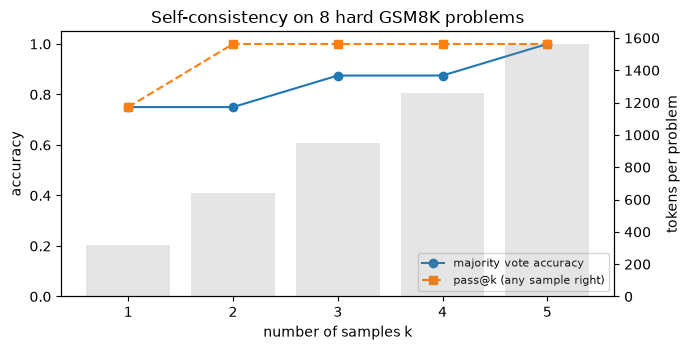

In [14]:
async def samples_for(problem):
    return await asyncio.gather(*(single_call_solve(problem, seed=s) for s in range(VOTE_K)))


all_samples = await asyncio.gather(*(samples_for(q) for q in GSM_SET.question))


def majority_vote(values):
    """Most common non-None value; ties broken by first appearance. None if no parsable values."""
    values = [v for v in values if v is not None]
    if not values:
        return None
    counts = Counter(values)
    best = max(counts.values())
    return next(v for v in values if counts[v] == best)


vote_rows = []
for (_, item), replies in zip(GSM_SET.iterrows(), all_samples):
    values = [None if parse_final_number(r.text) is None else round(parse_final_number(r.text), 6) for r in replies]
    for k in range(1, VOTE_K + 1):
        vote_rows.append({"row": item.row, "k": k, "vote_ok": is_correct(majority_vote(values[:k]), item.gold),
                          "any_ok": any(is_correct(v, item.gold) for v in values[:k]),
                          "tokens": sum(r.tokens for r in replies[:k]), "llm_seconds": sum(r.latency_s for r in replies[:k]),
                          "distinct_answers": len(set(v for v in values[:k] if v is not None))})
vote_df = pd.DataFrame(vote_rows)
vote_curve = vote_df.groupby("k").agg(majority_accuracy=("vote_ok", "mean"), pass_at_k=("any_ok", "mean"),
                                      tokens_per_problem=("tokens", "mean"), llm_seconds_per_problem=("llm_seconds", "mean"))
print(vote_curve.round(3).to_string())
disagree = (vote_df[vote_df.k == VOTE_K].distinct_answers > 1).mean()
print(f"\nsamples disagreed on {disagree:.0%} of problems (k={VOTE_K}); diverse answers are what voting needs.")
gain = vote_curve.majority_accuracy.iloc[-1] - vote_curve.majority_accuracy.iloc[0]
print(f"→ On this run majority@{VOTE_K} changed accuracy by {gain:+.0%} vs one sample, for "
      f"{vote_curve.tokens_per_problem.iloc[-1] / vote_curve.tokens_per_problem.iloc[0]:.1f}× the tokens (n = {len(GSM_SET)}).")
if vote_curve.majority_accuracy.iloc[0] >= 0.95:
    print("→ One sample was already (almost) always right: self-consistency cannot add much when errors are rare — it pays off "
          "at mid-range accuracy with diverse mistakes.")

fig, ax1 = plt.subplots(figsize=(7, 3.6))
ax1.plot(vote_curve.index, vote_curve.majority_accuracy, marker="o", label="majority vote accuracy")
ax1.plot(vote_curve.index, vote_curve.pass_at_k, marker="s", ls="--", label="pass@k (any sample right)")
ax1.set(xlabel="number of samples k", ylabel="accuracy", ylim=(0, 1.05), title=f"Self-consistency on {len(GSM_SET)} hard GSM8K problems")
ax2 = ax1.twinx()
ax2.bar(vote_curve.index, vote_curve.tokens_per_problem, alpha=0.2, color="gray", label="tokens / problem")
ax2.set_ylabel("tokens per problem")
ax1.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Voting on *normalized* answers: write `vote_normalized(raw_answers)` that parses each string with `parse_final_number`, rounds to 2 decimals, and returns `majority_vote` of the results.

In [15]:
def vote_normalized(raw_answers):
    return None  # TODO


check("vote_normalized", vote_normalized(["Final answer: $1,200", "so 1200.00", "Final answer: 1199", "It is 1200.0 dollars"]), 1200.0,
      hint="majority_vote([None if (v := parse_final_number(a)) is None else round(v, 2) for a in raw_answers])")

⏳ vote_normalized: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def vote_normalized(raw_answers):
    values = []
    for answer in raw_answers:
        value = parse_final_number(answer)
        values.append(None if value is None else round(value, 2))
    return majority_vote(values)


check("vote_normalized", vote_normalized(["Final answer: $1,200", "so 1200.00", "Final answer: 1199", "It is 1200.0 dollars"]), 1200.0)
```

Without normalization, "$1,200", "1200.00" and "1200.0" are three different strings and the vote splits (see ⚠️ Pitfall 1).
</details>

> 💡 **Interview angle:** "What is self-consistency and when does it help?" — sample several reasoning paths at temperature > 0 and take the majority final answer. It helps when answers are short and comparable (numbers, labels) and single-sample accuracy is mid-range with *diverse* errors; it costs k× tokens (parallel calls keep latency flat), and gains flatten quickly. Report accuracy vs k *and* tokens vs k, and compare against pass@k to see the ceiling.

## 5. Orchestrator–Workers 🟡

In sectioning, *you* fix the subtasks. In **orchestrator–workers**, an LLM **orchestrator** looks at the request, decides *which* subtasks are needed (the list changes per input), fans them out to **workers**, and a **synthesizer** combines their results.

```
                      ┌─► worker 1: search + extract ─┐
question ─► orchestrator ─► worker 2: search + extract ─┼─► synthesizer ─► answer
  (LLM plans N subtasks)└─► worker N …                ─┘
```

Here: a HotpotQA **comparison** question over our local Wikipedia paragraphs. Each worker runs BM25 search for its own query and extracts one fact with an LLM call; workers run concurrently.

In [16]:
ORCH_SCHEMA = {"type": "object", "properties": {"subtasks": {"type": "array", "minItems": 1, "maxItems": 4, "items": {
    "type": "object", "properties": {"search_query": {"type": "string"}, "fact_needed": {"type": "string"}},
    "required": ["search_query", "fact_needed"], "additionalProperties": False}}}, "required": ["subtasks"], "additionalProperties": False}
ANSWER_STYLE = "Reply with only the short answer: a name, number, date, short phrase, or yes/no."


async def orchestrate(question):
    plan, plan_replies = await llm_json([{"role": "system", "content": "You are an orchestrator. Break the question into the independent fact "
                                          "look-ups needed to answer it (one per entity or fact). Do not answer it."},
                                         {"role": "user", "content": question}], "plan", ORCH_SCHEMA, max_tokens=768, label="orchestrator")
    subtasks = plan["subtasks"] if plan else [{"search_query": question, "fact_needed": question}]   # fallback: a single worker

    async def worker(task):
        titles = search_titles(task["search_query"], k=3)
        reply = await llm([{"role": "system", "content": "Using only the passages, state the requested fact in one short sentence, or 'not found'."},
                           {"role": "user", "content": f"Fact needed: {task['fact_needed']}\n\nPassages:\n{format_passages(titles)}"}],
                          max_tokens=768, label="worker")
        return {"task": task, "titles": titles, "fact": reply.text.strip(), "reply": reply}

    results = await asyncio.gather(*(worker(t) for t in subtasks))
    notes = "\n".join(f"- {r['task']['fact_needed']}: {r['fact']}" for r in results)
    final = await llm([{"role": "system", "content": "Answer the question from the worker notes. " + ANSWER_STYLE},
                       {"role": "user", "content": f"Question: {question}\nWorker notes:\n{notes}"}], max_tokens=768, label="synthesizer")
    replies = [*plan_replies, *(r["reply"] for r in results), final]
    return final.text.strip(), results, replies


orch_item = HOTPOT_EXTRA.iloc[0]
(orch_answer, orch_results, orch_replies), orch_wall = await timed("orchestrator-workers", lambda: orchestrate(orch_item.question))
print(f"question: {orch_item.question}\norchestrator planned {len(orch_results)} subtasks:")
for r in orch_results:
    print(f"  • {r['task']['search_query']!r} → found {r['titles'][:2]} → {r['fact'][:110]}")
print(f"answer: {orch_answer!r} | gold: {orch_item.answer!r} | EM {exact_match(orch_answer, orch_item.answer):.0f} | "
      f"F1 {f1_score(orch_answer, orch_item.answer):.2f}")
worker_seconds = [r["reply"].latency_s for r in orch_results]
print(f"LLM calls {len(orch_replies)} (1 plan + {len(orch_results)} workers + 1 synthesis) | tokens {sum(r.tokens for r in orch_replies):,} | "
      f"wall-clock {orch_wall:.1f}s (workers alone: {sum(worker_seconds):.1f}s of LLM time run concurrently)")
print(f"gold supporting paragraphs {orch_item.gold_titles} retrieved by workers: "
      f"{sorted(set(orch_item.gold_titles) & {t for r in orch_results for t in r['titles']})}")

question: Which restaurant chain's headquarters is further north, Pizza Inn or Papa Gino's?
orchestrator planned 3 subtasks:
  • 'Pizza Inn headquarters location latitude' → found ['Pizza Inn', 'Pie Five'] → not found
  • "Papa Gino's headquarters location latitude" → found ["Papa Gino's", "Gino's Pizza and Spaghetti"] → not found
  • "compare latitudes of Pizza Inn and Papa Gino's headquarters" → found ["Papa Gino's", "Papa John's Pizza"] → Dedham, Massachusetts.
answer: "Papa Gino's" | gold: "Papa Gino's" | EM 1 | F1 1.00
LLM calls 5 (1 plan + 3 workers + 1 synthesis) | tokens 1,670 | wall-clock 5.1s (workers alone: 3.7s of LLM time run concurrently)
gold supporting paragraphs ["Papa Gino's", 'Pizza Inn'] retrieved by workers: ["Papa Gino's", 'Pizza Inn']


### ✍️ Your Turn

When subtasks *do* depend on each other, an orchestrator can still run them in **waves**: every task whose dependencies are finished runs together (the idea behind LLMCompiler's parallel function calling). Write `schedule_waves(deps)` for a dict `task → list of prerequisite tasks` that returns a list of **sorted** lists, one per wave.

In [17]:
def schedule_waves(deps):
    return None  # TODO


check("schedule_waves", schedule_waves({"search_a": [], "search_b": [], "compare": ["search_a", "search_b"], "lookup_c": ["search_a"],
                                        "write": ["compare", "lookup_c"]}),
      [["search_a", "search_b"], ["compare", "lookup_c"], ["write"]],
      hint="Repeat: ready = tasks not done whose deps are all done; append sorted(ready); mark them done.")

⏳ schedule_waves: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def schedule_waves(deps):
    done, waves = set(), []
    while len(done) < len(deps):
        ready = sorted(t for t, pre in deps.items() if t not in done and all(p in done for p in pre))
        if not ready:
            raise ValueError("cycle in dependencies")
        waves.append(ready)
        done.update(ready)
    return waves


check("schedule_waves", schedule_waves({"search_a": [], "search_b": [], "compare": ["search_a", "search_b"], "lookup_c": ["search_a"],
                                        "write": ["compare", "lookup_c"]}),
      [["search_a", "search_b"], ["compare", "lookup_c"], ["write"]])
```

This is Kahn's topological sort grouped by level. Wall-clock ≈ the sum over waves of the slowest task in each wave.
</details>

> 💡 **Interview angle:** "Orchestrator–workers vs sectioning vs a multi-agent system?" — sectioning has a fixed subtask list; orchestrator–workers lets an LLM decide the subtasks per input, then fans out and synthesizes; a multi-agent system gives workers their own loops, tools and context. Each step up adds calls and failure points (bad plans, lost context at hand-offs), so justify it with inputs whose subtasks genuinely vary.

## 6. Evaluator–Optimizer With a Verifiable Evaluator 🟡

One LLM **generates**, an **evaluator** judges, and the generator **revises** using the feedback — repeat until the evaluator is satisfied or a budget runs out. The pattern is only as good as its evaluator. The best evaluators are **verifiable**: unit tests, schema validators, compilers, calculators. LLM-judges also work but can share the generator's blind spots.

Our task: **MBPP** Python problems. The evaluator runs **unit tests in a separate process with a timeout**:

- the generator sees the problem and **one** example test (so it knows the function name and format);
- the **feedback tests** are the first two tests — their failures (with the actual value returned) go back to the model;
- the **third test is hidden** and only used to report whether revisions generalize or just overfit the feedback.

⚠️ A subprocess with a timeout, a temp directory and an empty environment stops hangs and accidental damage, but it is **not a security boundary** for hostile code — use containers or microVMs for that.

In [18]:
HARNESS = textwrap.dedent('''
    import ast, json, sys
    namespace, results = {}, []
    try:
        exec(compile(SOURCE, "<candidate>", "exec"), namespace)
    except BaseException as exc:
        print("@@RESULT@@" + json.dumps({"load_error": f"{type(exc).__name__}: {exc}"[:300], "results": []}))
        sys.exit(0)
    for test in TESTS:
        try:
            exec(test, namespace)
            results.append([True, ""])
        except BaseException as exc:
            detail = f"{type(exc).__name__}: {exc}"[:200]
            try:
                node = ast.parse(test).body[0]
                if isinstance(node, ast.Assert) and isinstance(node.test, ast.Compare):
                    detail += f" (left side returned {eval(ast.unparse(node.test.left), namespace)!r})"[:200]
            except BaseException:
                pass
            results.append([False, detail])
    print("@@RESULT@@" + json.dumps({"load_error": None, "results": results}))
''')


def run_tests(code, tests, imports=(), timeout_s=5.0):
    """Run candidate code + assert-tests in a child Python process. Returns {'status', 'passed': [bool], 'errors': [str]}."""
    program = f"SOURCE = {(chr(10).join(imports) + chr(10) + code)!r}\nTESTS = {list(tests)!r}\n" + HARNESS
    with tempfile.TemporaryDirectory(prefix="mbpp_") as work:
        try:
            proc = subprocess.run([sys.executable, "-I", "-c", program], capture_output=True, text=True, timeout=timeout_s,
                                  cwd=work, env={"PATH": "/usr/bin:/bin"})
        except subprocess.TimeoutExpired:
            return {"status": "timeout", "passed": [False] * len(tests), "errors": [f"timed out after {timeout_s}s"] * len(tests)}
    marker = [line for line in proc.stdout.splitlines() if line.startswith("@@RESULT@@")]
    if not marker:
        return {"status": "crash", "passed": [False] * len(tests), "errors": [redact(proc.stderr.strip()[-200:])] * len(tests)}
    data = json.loads(marker[-1][len("@@RESULT@@"):])
    if data["load_error"]:
        return {"status": "load_error", "passed": [False] * len(tests), "errors": [data["load_error"]] * len(tests)}
    return {"status": "ran", "passed": [ok for ok, _ in data["results"]], "errors": [err for _, err in data["results"]]}


demo = MBPP_SET.iloc[0]
print("reference solution:", run_tests(demo.code, demo.test_list, demo.test_imports))
print("broken solution   :", run_tests("def " + demo.code.split("def ", 1)[1].split("(")[0] + "(*args):\n    return None", demo.test_list))
print("infinite loop     :", run_tests("while True:\n    pass", demo.test_list[:1], timeout_s=2)["status"])

reference solution: {'status': 'ran', 'passed': [True, True, True], 'errors': ['', '', '']}


broken solution   : {'status': 'ran', 'passed': [False, True, False], 'errors': ['AssertionError:  (left side returned None)', '', 'AssertionError:  (left side returned None)']}


infinite loop     : timeout


In [19]:
CODE_SCHEMA = {"type": "object", "properties": {"code": {"type": "string"}}, "required": ["code"], "additionalProperties": False}
REVISE_SCHEMA = {"type": "object", "properties": {"diagnosis": {"type": "string"}, "code": {"type": "string"}},
                 "required": ["diagnosis", "code"], "additionalProperties": False}
CODER_SYSTEM = "You are a careful Python programmer. Return only a JSON object whose 'code' field is a complete Python solution (imports + function)."


def mbpp_prompt(task, lessons=()):
    text = f"Problem: {task.prompt}\nYour code must pass tests like this one:\n{task.test_list[0]}"
    if lessons:
        text += "\n\nLessons from earlier failed attempts (apply them if relevant):\n" + "\n".join(f"- {lesson}" for lesson in lessons)
    return text


async def evaluator_optimizer(task, max_iterations=3):
    messages = [{"role": "system", "content": CODER_SYSTEM}, {"role": "user", "content": mbpp_prompt(task)}]
    history, calls, tokens = [], 0, 0
    reply = await llm(messages, max_tokens=1536, label="mbpp-generate",
                      response_format={"type": "json_schema", "json_schema": {"name": "code", "schema": CODE_SCHEMA, "strict": True}})
    for iteration in range(max_iterations):
        calls, tokens = calls + 1, tokens + reply.tokens
        try:
            code = json.loads(reply.text)["code"]
        except (json.JSONDecodeError, KeyError):
            code = ""
        feedback = run_tests(code, task.test_list[:2], task.test_imports)
        hidden = run_tests(code, task.test_list[2:], task.test_imports)
        history.append({"iteration": iteration, "feedback_pass": all(feedback["passed"]), "hidden_pass": all(hidden["passed"]),
                        "status": feedback["status"], "code": code, "feedback": feedback})
        if all(feedback["passed"]) or iteration == max_iterations - 1:
            break
        report = "\n".join(f"{test}\n  → {'PASS' if ok else 'FAIL: ' + err}" for test, ok, err in
                           zip(task.test_list[:2], feedback["passed"], feedback["errors"]))
        messages = [{"role": "system", "content": CODER_SYSTEM},
                    {"role": "user", "content": mbpp_prompt(task) + f"\n\nYour previous code:\n{code}\n\nTest results:\n{report}\n\n"
                                                                    "First diagnose the bug in one sentence, then give the corrected full code."}]
        reply = await llm(messages, max_tokens=1536, label="mbpp-revise",
                          response_format={"type": "json_schema", "json_schema": {"name": "revise", "schema": REVISE_SCHEMA, "strict": True}})
    return history, calls, tokens


eo_results = await asyncio.gather(*(evaluator_optimizer(task) for _, task in MBPP_SET.iterrows()))
eo_rows = []
for (_, task), (history, calls, tokens) in zip(MBPP_SET.iterrows(), eo_results):
    for it in range(3):                                           # carry the last attempt forward once a task has stopped
        h = history[min(it, len(history) - 1)]
        eo_rows.append({"task_id": task.task_id, "iteration": it, "feedback_pass": h["feedback_pass"], "hidden_pass": h["hidden_pass"],
                        "llm_calls": calls if it == 2 else None, "tokens": tokens if it == 2 else None})
eo_df = pd.DataFrame(eo_rows)
by_iter = eo_df.groupby("iteration")[["feedback_pass", "hidden_pass"]].mean()
print(by_iter.rename(columns={"feedback_pass": "pass rate: feedback tests", "hidden_pass": "pass rate: hidden test"}).round(3).to_string())
final = eo_df[eo_df.iteration == 2]
print(f"\nLLM calls per task {final.llm_calls.mean():.2f} | tokens per task {final.tokens.mean():,.0f} | n = {len(MBPP_SET)} problems")
fixed = int(final.feedback_pass.sum() - eo_df[eo_df.iteration == 0].feedback_pass.sum())
print(f"→ Revisions fixed {fixed} task(s) on the feedback tests; hidden-test pass rate went "
      f"{by_iter.hidden_pass.iloc[0]:.0%} → {by_iter.hidden_pass.iloc[-1]:.0%}.")
overfit = final[(final.feedback_pass) & (~final.hidden_pass)]
print(f"→ Tasks passing feedback tests but failing the hidden test (possible overfitting or ambiguous spec): {overfit.task_id.tolist()}")
EO_FAILED_FIRST = [task_id for task_id, (history, _, _) in zip(MBPP_SET.task_id, eo_results) if not history[0]["feedback_pass"]]
print(f"tasks that failed the first attempt (used again in Section 9): {EO_FAILED_FIRST}")

           pass rate: feedback tests  pass rate: hidden test
iteration                                                   
0                              0.875                     1.0
1                              1.000                     1.0
2                              1.000                     1.0

LLM calls per task 1.12 | tokens per task 489 | n = 8 problems
→ Revisions fixed 1 task(s) on the feedback tests; hidden-test pass rate went 100% → 100%.
→ Tasks passing feedback tests but failing the hidden test (possible overfitting or ambiguous spec): []
tasks that failed the first attempt (used again in Section 9): [431]


### ✍️ Your Turn

Turn an optimizer log into a **pass-rate-by-iteration** list. `log` maps task → list of pass/fail per attempt; tasks stop once they pass, so **carry each task's last result forward**. Return the pass rate after iterations 0, 1 and 2 as a list of floats.

In [20]:
opt_log = {"t1": [True], "t2": [False, True], "t3": [False, False, False], "t4": [False, False, True]}
pass_by_iteration = None  # TODO
check("pass_by_iteration", pass_by_iteration, [0.25, 0.5, 0.75], hint="for it in range(3): mean of attempts[min(it, len(attempts) - 1)]")

⏳ pass_by_iteration: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
opt_log = {"t1": [True], "t2": [False, True], "t3": [False, False, False], "t4": [False, False, True]}
pass_by_iteration = [float(np.mean([attempts[min(it, len(attempts) - 1)] for attempts in opt_log.values()])) for it in range(3)]
check("pass_by_iteration", pass_by_iteration, [0.25, 0.5, 0.75])
```
</details>

> 💡 **Interview angle:** "What are the risks of an evaluator–optimizer loop?" — the generator **overfits or games** the evaluator (special-cases the visible tests — keep hidden tests), an LLM-judge shares the generator's biases or rewards length, loops that never converge (cap iterations and tokens), and cost that grows per iteration. Prefer verifiable evaluators, report hidden-set results, and stop when the score stops improving.

## 7. ReAct From Scratch vs Native Function Calling 🟡

**ReAct** (Yao et al. 2022) interleaves **Re**asoning and **Act**ing as *text*:

```
Thought: I need the price of 12 tickets.
Action: calculator
Action Input: 12 * 7.5
Observation: 90.0          ← written by YOUR code, not the model
Thought: …
Final Answer: 90
```

Your code parses each reply, runs the action, appends the observation and asks again. A **stop sequence** (`stop=["Observation:"]`) keeps the model from writing a fake observation itself. **Native function calling** does the same loop, but the model returns *structured* tool calls, so there is nothing to parse. We run ReAct from scratch on the same 8 GSM8K problems and the same calculator as the Section 1 agent, and measure **what each reply parsed as**.

In [21]:
REACT_SYSTEM = textwrap.dedent("""\
    Solve the math word problem. You can use a calculator.
    Reply in plain text using EXACTLY this format, ONE step per reply:
    Thought: <one short sentence>
    Action: calculator
    Action Input: <arithmetic expression>
    Then stop and wait for "Observation: <result>". When you know the answer, reply:
    Thought: <one short sentence>
    Final Answer: <number>""")
ACTION_RE = re.compile(r"Action\s*:\s*([A-Za-z_]+)\s*\n+\s*Action Input\s*:\s*(.+)", re.S)
FINAL_RE = re.compile(r"Final Answer\s*:\s*(.+)", re.S)


def parse_react_step(text):
    """→ ('final', answer) | ('action', tool, input) | ('empty',) | ('malformed',). Whichever marker comes first wins."""
    text = (text or "").strip()
    if not text:
        return ("empty",)
    action, final = ACTION_RE.search(text), FINAL_RE.search(text)
    if action and (not final or action.start() < final.start()):
        tool_input = action.group(2).strip().splitlines()[0].strip().strip("`\"'")
        return ("action", action.group(1), tool_input)
    if final:
        return ("final", final.group(1).strip().splitlines()[0])
    return ("malformed",)


assert parse_react_step("Thought: add\nAction: calculator\nAction Input: 2+3") == ("action", "calculator", "2+3")
assert parse_react_step("Thought: done\nFinal Answer: 42 apples") == ("final", "42 apples")
assert parse_react_step("") == ("empty",) and parse_react_step("The answer is 42.") == ("malformed",)


async def run_react_text(problem, max_steps=8):
    messages = [{"role": "system", "content": REACT_SYSTEM}, {"role": "user", "content": f"Problem: {problem}"}]
    run, kinds = AgentRun(answer=None, stop_reason="max_steps"), []
    for _ in range(max_steps):
        reply = await llm(messages, max_tokens=1024, stop=["Observation:"], label="react-text")
        add_usage(run, reply)
        parsed = parse_react_step(reply.text)
        kinds.append(parsed[0])
        messages.append({"role": "assistant", "content": reply.text or ""})
        if parsed[0] == "final":
            run.answer, run.stop_reason = parsed[1], "final_answer"
            break
        if parsed[0] == "action":
            try:
                observation = calculator(parsed[2]) if parsed[1] == "calculator" else f"unknown tool {parsed[1]}"
            except Exception as exc:
                observation = f"error: {type(exc).__name__}: {exc}"
            run.tool_calls += 1
            messages.append({"role": "user", "content": f"Observation: {observation}"})
        else:                                                   # empty or malformed → tell the model and continue
            messages.append({"role": "user", "content": "Observation: your reply did not follow the format. Reply with "
                                                        "Thought + Action + Action Input, or Thought + Final Answer."})
    run.trace = kinds
    return run


react_runs = await asyncio.gather(*(run_react_text(q) for q in GSM_SET.question))
react_kinds = Counter(k for r in react_runs for k in r.trace)
fc_parse_errors = sum("JSONDecodeError" in s.get("result", "") for r in agent_runs for s in r.trace if s["kind"] == "tool")
fc_steps = sum(r.llm_calls for r in agent_runs)
pattern_rows = []
for name, runs in [("ReAct (text protocol)", react_runs), ("native function calling", agent_runs)]:
    oks = [is_correct(parse_final_number(r.answer), g) for r, g in zip(runs, GSM_SET.gold)]
    pattern_rows.append({"pattern": name, "accuracy": np.mean(oks), "used the tool (share of problems)": np.mean([r.tool_calls > 0 for r in runs]),
                         "LLM calls / problem": np.mean([r.llm_calls for r in runs]), "tokens / problem": np.mean([r.tokens for r in runs]),
                         "finished": np.mean([r.stop_reason == "final_answer" for r in runs])})
react_table = pd.DataFrame(pattern_rows).set_index("pattern")
print(react_table.round(3).to_string())
total_steps = sum(react_kinds.values())
print(f"\nReAct replies parsed as: {dict(react_kinds)} (of {total_steps} replies) → "
      f"{(react_kinds['empty'] + react_kinds['malformed']) / total_steps:.0%} unusable")
print(f"native function calling: {fc_steps} replies, {fc_parse_errors} with unparsable tool arguments")
if react_kinds["final"] and react_table.loc["ReAct (text protocol)", "used the tool (share of problems)"] < 0.5:
    print("→ On this run the model mostly skipped the Action step and wrote a Final Answer straight away: the text protocol "
          "is a *request*, not a constraint. Function calling (or schema-constrained steps) makes tool use structural.")

                         accuracy  used the tool (share of problems)  LLM calls / problem  tokens / problem  finished
pattern                                                                                                              
ReAct (text protocol)       0.875                              0.875                3.000          1230.125     0.875
native function calling     1.000                              0.875                1.875           825.750     1.000

ReAct replies parsed as: {'action': 14, 'final': 7, 'empty': 3} (of 24 replies) → 12% unusable
native function calling: 15 replies, 0 with unparsable tool arguments


**What to take away.** A text protocol can fail in ways a parser must survive: empty replies (gpt-oss may route an "action" into its hidden tool channel when no tools are declared — seen in the prerequisite notebook), format drift, several actions in one reply, invented observations, or ignoring the tools altogether. Native function calling removes the parsing layer; schema-constrained JSON steps (as in the prerequisite notebook) are the middle ground when a server has no tool API.

### ✍️ Your Turn

Stop sequences run on the server; write the client-side safety net. `strip_after_observation(text)` returns the text **before** the first line that starts with `Observation:` (a model-invented observation), with trailing whitespace removed.

In [22]:
def strip_after_observation(text):
    return None  # TODO


check("strip_after_observation", strip_after_observation("Thought: add\nAction: calculator\nAction Input: 2+3\nObservation: 5\nFinal Answer: 5"),
      "Thought: add\nAction: calculator\nAction Input: 2+3", hint="re.split(r'^\\s*Observation\\s*:', text, maxsplit=1, flags=re.M)[0].rstrip()")

⏳ strip_after_observation: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def strip_after_observation(text):
    return re.split(r"^\s*Observation\s*:", text, maxsplit=1, flags=re.M)[0].rstrip()


check("strip_after_observation", strip_after_observation("Thought: add\nAction: calculator\nAction Input: 2+3\nObservation: 5\nFinal Answer: 5"),
      "Thought: add\nAction: calculator\nAction Input: 2+3")
```

Everything after a self-written "Observation:" is fiction — the tool never ran. Cut it and run the real tool.
</details>

> 💡 **Interview angle:** "ReAct vs function calling?" — same observe–think–act loop. ReAct is a *prompt protocol* your code parses (works with any text model, reasoning visible, but fragile: format drift, fake observations, skipped actions — use stop sequences and a defensive parser). Function calling is a *model/API feature* that returns structured calls — more reliable, validated arguments, possible parallel calls. Default to function calling; measure parse failures if you must use text.

## 8. Plan-and-Execute and ReWOO vs ReAct 🔴

ReAct decides one step at a time and **re-sends the whole history every step**. Two planning families change that:

| | **ReAct** | **Plan-and-execute** | **ReWOO** (Xu et al. 2023) |
|---|---|---|---|
| planning | none — decide each step | a planner writes step goals; an executor does each step; a **replanner** may revise | a planner writes the **whole tool program** once, with evidence variables `#E1, #E2…` |
| LLM calls | one per step | 1 plan + 1 per step + replans + 1 | 1 plan + LLM-tool steps + 1 solver |
| tokens | history grows every step | each step sees only its goal + notes | observations never go back to the planner |
| adapts to surprises | yes, every step | at replanning points | no (plan once) |

Both planners below write **structured output** (JSON Schema). Search is the same BM25 tool over our local corpus. We trace all three on two **dev** questions (one *bridge*, one *comparison*) that are **not** in the Mini Project's test set — n = 2 is for understanding the mechanics; the measured comparison on 30 questions is the Mini Project.

In [23]:
SEARCH_TOOL = {"type": "function", "function": {
    "name": "search", "description": "Search a collection of Wikipedia paragraphs. Returns the 3 best-matching paragraphs with their titles.",
    "parameters": {"type": "object", "properties": {"query": {"type": "string", "description": "keywords, e.g. an entity name plus the fact you need"}},
                   "required": ["query"], "additionalProperties": False}}}
QA_SYSTEM = ("Answer the multi-hop question using the search tool. Search for one entity or fact at a time. "
             "When you know the answer, stop calling tools. " + ANSWER_STYLE)


async def react_qa(question, max_steps=5, guard=None, index=None, titles=None, label="qa-react"):
    seen = []

    def search(query):
        hits = search_titles(query, k=3, index=index, titles=titles)
        seen.extend(hits)
        return format_passages(hits)

    run = await run_tool_agent(question, system=QA_SYSTEM, tools=[SEARCH_TOOL], impls={"search": search},
                               max_steps=max_steps, guard=guard, label=label)
    run.retrieved = seen
    return run


PE_PLAN_SCHEMA = {"type": "object", "properties": {"steps": {"type": "array", "minItems": 1, "maxItems": 3, "items": {
    "type": "object", "properties": {"goal": {"type": "string"}, "search_query": {"type": "string"}},
    "required": ["goal", "search_query"], "additionalProperties": False}}}, "required": ["steps"], "additionalProperties": False}
PE_REPLAN_SCHEMA = {"type": "object", "properties": {
    "decision": {"type": "string", "enum": ["answer", "replan"]}, "answer": {"type": "string"},
    "new_steps": PE_PLAN_SCHEMA["properties"]["steps"] | {"minItems": 0}},
    "required": ["decision", "answer", "new_steps"], "additionalProperties": False}


async def plan_and_execute(question, max_replans=1):
    run, notes = AgentRun(answer=None, stop_reason="max_replans"), []
    run.retrieved = []
    plan, plan_replies = await llm_json([{"role": "system", "content": "You are a planner. Write at most 3 steps to answer the question. Each step "
                                          "has a goal and a search query. A query may contain {result1}, {result2} to reuse earlier step results "
                                          "(e.g. the name found in step 1). Do not answer the question."},
                                         {"role": "user", "content": question}], "plan", PE_PLAN_SCHEMA, max_tokens=1024, label="qa-plan")
    for reply in plan_replies:
        add_usage(run, reply)
    steps = plan["steps"] if plan else [{"goal": question, "search_query": question}]
    for round_ in range(max_replans + 1):
        for step in steps:
            query = step["search_query"]
            for i, note in enumerate(notes, 1):
                query = query.replace(f"{{result{i}}}", note["result"])
            hits = search_titles(query, k=3)
            run.retrieved += hits
            run.tool_calls += 1
            exec_reply = await llm([{"role": "system", "content": "You execute one step of a plan. Using only the passages, give the "
                                     "step's result in a few words, or 'unknown'."},
                                    {"role": "user", "content": f"Step goal: {step['goal']}\n\nPassages:\n{format_passages(hits)}"}],
                                   max_tokens=768, label="qa-execute")
            add_usage(run, exec_reply)
            notes.append({"goal": step["goal"], "query": query, "result": exec_reply.text.strip()})
        decision, replan_replies = await llm_json(
            [{"role": "system", "content": "Given the question and the step results, either answer (decision='answer', "
              "new_steps=[]) or, if a needed fact is missing, replan with up to 3 new steps (decision='replan', answer='')."
              " " + ANSWER_STYLE},
             {"role": "user", "content": f"Question: {question}\nStep results:\n" +
              "\n".join(f"{i}. {n['goal']} → {n['result']}" for i, n in enumerate(notes, 1))}],
            "replan", PE_REPLAN_SCHEMA, max_tokens=1024, label="qa-replan")
        for reply in replan_replies:
            add_usage(run, reply)
        if decision is None:                                      # no valid decision twice: answer with the last step's result
            decision = {"decision": "answer", "answer": notes[-1]["result"], "new_steps": []}
        if decision["decision"] == "answer" or not decision["new_steps"] or round_ == max_replans:
            run.answer, run.stop_reason = decision["answer"], "final_answer"
            break
        steps = decision["new_steps"]
    run.trace = notes
    return run


REWOO_SCHEMA = {"type": "object", "properties": {"steps": {"type": "array", "minItems": 1, "maxItems": 4, "items": {
    "type": "object", "properties": {"id": {"type": "string", "pattern": "^#E[0-9]+$"}, "tool": {"type": "string", "enum": ["Search", "LLM"]},
                                     "input": {"type": "string"}},
    "required": ["id", "tool", "input"], "additionalProperties": False}}}, "required": ["steps"], "additionalProperties": False}
REWOO_PLANNER = ("You are a planner. Write a program of tool steps that gathers the evidence to answer the question. Each step has an id "
                 "(#E1, #E2, …), a tool and an input. Tools: Search[query] returns Wikipedia paragraphs; LLM[instruction] answers a short "
                 "instruction. An input may reference earlier evidence ids, e.g. LLM[Which person is named in #E1?] then Search[#E2 birthplace]. "
                 "Use at most 4 steps and do not answer the question yourself.")


def substitute(text, evidence):
    return re.sub(r"#E\d+", lambda m: evidence.get(m.group(0), m.group(0)), text)


async def rewoo(question, label_prefix="qa-rewoo"):
    run = AgentRun(answer=None, stop_reason="final_answer")
    run.retrieved = []
    plan, plan_replies = await llm_json([{"role": "system", "content": REWOO_PLANNER}, {"role": "user", "content": question}],
                                        "rewoo", REWOO_SCHEMA, max_tokens=1024, label=f"{label_prefix}-plan")
    for reply in plan_replies:
        add_usage(run, reply)
    if plan is None:                                              # planner failed twice: fall back to searching the question itself
        run.stop_reason = "plan_fallback"
    steps = plan["steps"] if plan else [{"id": "#E1", "tool": "Search", "input": question}]
    evidence, shown = {}, {}
    for step in steps:
        if step["tool"] == "Search":
            hits = search_titles(substitute(step["input"], shown), k=3)
            run.retrieved += hits
            run.tool_calls += 1
            evidence[step["id"]] = format_passages(hits, max_chars=400)
            shown[step["id"]] = " ".join(hits[:1])                 # a Search result is referenced by its top title
        else:
            worker = await llm([{"role": "system", "content": "Answer the instruction in a few words using the evidence."},
                                {"role": "user", "content": substitute(step["input"], evidence)}], max_tokens=768, label=f"{label_prefix}-worker")
            add_usage(run, worker)
            evidence[step["id"]] = shown[step["id"]] = worker.text.strip()
    plan_text = "\n".join(f"{s['id']} = {s['tool']}[{s['input']}]\n  evidence: {evidence.get(s['id'], '')[:900]}" for s in steps)
    solver = await llm([{"role": "system", "content": "Solve the question using the plan and its evidence. " + ANSWER_STYLE},
                        {"role": "user", "content": f"Question: {question}\n\n{plan_text}"}], max_tokens=1024, label=f"{label_prefix}-solve")
    add_usage(run, solver)
    run.answer, run.trace = solver.text.strip(), steps
    return run


dev_rows = []
for _, item in HOTPOT_DEV.iterrows():
    runs = {"ReAct (function calling)": await react_qa(item.question), "plan-and-execute": await plan_and_execute(item.question),
            "ReWOO": await rewoo(item.question)}
    print(f"\n❓ [{item.type}] {item.question}\n   gold: {item.answer!r} | gold paragraphs: {item.gold_titles}")
    for name, run in runs.items():
        dev_rows.append({"question": item.type, "pattern": name, "answer": run.answer or "", "gold": item.answer,
                         "EM": exact_match(run.answer or "", item.answer),
                         "F1": round(f1_score(run.answer or "", item.answer), 2), "LLM calls": run.llm_calls, "searches": run.tool_calls,
                         "tokens": run.tokens, "LLM seconds": round(run.latency_s, 1),
                         "gold paragraphs found": len(set(item.gold_titles) & set(run.retrieved))})
        print(f"   {name:25s} → {str(run.answer)[:60]!r}")
    print("   plan-and-execute notes:", [(n["query"], n["result"][:40]) for n in runs["plan-and-execute"].trace])
    print("   ReWOO program:", [f"{s['id']}={s['tool']}[{s['input'][:45]}]" for s in runs["ReWOO"].trace])
dev_df = pd.DataFrame(dev_rows)
print("\n" + dev_df.to_string(index=False))
print("\nmean over the 2 dev questions:\n" + dev_df.groupby("pattern")[["EM", "F1", "LLM calls", "tokens"]].mean().round(2).to_string())


❓ [bridge] In what state is the manufacturer of Bisquick headquartered?
   gold: 'Minnesota' | gold paragraphs: ['Bisquick', 'General Mills']
   ReAct (function calling)  → 'Minnesota'
   plan-and-execute          → 'Minnesota'
   ReWOO                     → 'Minnesota'
   plan-and-execute notes: [('Bisquick manufacturer', 'General\u202fMills.'), ('General\u202fMills. headquarters location', 'Golden Valley, Minnesota.'), ('Golden Valley, Minnesota. state', 'Minnesota')]
   ReWOO program: ['#E1=Search[Bisquick manufacturer]', '#E2=LLM[Which company manufactures Bisquick according]', '#E3=Search[headquarters of the company that manufactures]', '#E4=LLM[In which U.S. state is the headquarters locat]']

❓ [comparison] Is Velvetpark or Shape magazine written more for a lesbian and queer-identified female readership?
   gold: 'Velvetpark' | gold paragraphs: ['Shape (magazine)', 'Velvetpark']
   ReAct (function calling)  → 'Velvetpark.'
   plan-and-execute          → 'Velvetpark'
   ReWOO   

Read the traces, not just the table: where did each pattern lose information? Plan-and-execute's `{result1}` substitution and ReWOO's `#E` references are how a fixed plan passes a *discovered* entity to the next search — when the planner doesn't use them, the second hop searches for the wrong thing. ReAct adapts naturally but pays for it in re-sent tokens.

### ✍️ Your Turn

`substitute` above uses a regex so that `#E1` never matches inside `#E12`. Show why a naive loop is wrong: compute `naive` with `str.replace` in the order `#E1`, `#E12` and `safe` with `substitute`, for the input `"compare #E1 with #E12"` and evidence `{"#E1": "Paris", "#E12": "Rome"}`. Store the tuple `(naive, safe)`.

In [24]:
evidence_demo = {"#E1": "Paris", "#E12": "Rome"}
naive_vs_safe = None  # TODO: (naive, safe)
check("naive_vs_safe", naive_vs_safe, ("compare Paris with Paris2", "compare Paris with Rome"),
      hint="naive = text; for key in ['#E1', '#E12']: naive = naive.replace(key, evidence_demo[key])")

⏳ naive_vs_safe: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
evidence_demo = {"#E1": "Paris", "#E12": "Rome"}
text = "compare #E1 with #E12"
naive = text
for key in ["#E1", "#E12"]:
    naive = naive.replace(key, evidence_demo[key])
naive_vs_safe = (naive, substitute(text, evidence_demo))
check("naive_vs_safe", naive_vs_safe, ("compare Paris with Paris2", "compare Paris with Rome"))
```

`#E12` starts with `#E1`, so the naive loop corrupts it before its own turn. Matching whole tokens (`#E\d+`) fixes it.
</details>

> 💡 **Interview angle:** "Plan-and-execute vs ReAct — trade-offs?" — planning gives a reviewable plan, fewer tokens per step (no ever-growing history), cheaper executor models and natural parallelism (ReWOO/LLMCompiler run independent tool steps together); the price is brittleness when the plan is wrong or the world surprises it, so add replanning points. ReAct adapts every step but re-sends history and can wander. Pick by how predictable the tool path is — and measure.

## 9. Reflection and Reflexion-Style Lesson Memory 🟡

- **Reflection** (self-critique) = the model reviews its own output within one task and revises it. Section 6 was the verifiable version.
- **Reflexion** (Shinn et al. 2023) adds **memory across attempts**: after a *failed* trial, the agent writes a short **verbal lesson** ("I returned a list, but the tests expect a tuple") into an episodic memory; the next trial starts fresh but reads the lessons. No weights change — it is "verbal reinforcement learning".

The key ingredient is an honest **failure signal**. Here it is the same feedback tests as Section 6. We run Reflexion on the MBPP tasks whose *first attempt* failed in Section 6 (that first attempt is the identical request, so it is replayed from the cache), with a lesson memory **shared across tasks**, and compare with Section 6's evaluator–optimizer on the same tasks.

In [25]:
LESSON_SCHEMA = {"type": "object", "properties": {"lesson": {"type": "string"}}, "required": ["lesson"], "additionalProperties": False}


class LessonMemory:
    """Episodic memory of short lessons, persisted to JSON, de-duplicated, newest last, capped in size."""

    def __init__(self, path, max_items=5):
        self.path, self.max_items = Path(path), max_items
        self.lessons = json.loads(self.path.read_text()) if self.path.exists() else []

    def add(self, lesson):
        key = normalize_answer(lesson)
        self.lessons = [x for x in self.lessons if normalize_answer(x) != key] + [lesson.strip()]
        self.lessons = self.lessons[-self.max_items:]
        self.path.write_text(json.dumps(self.lessons, indent=1))


async def reflexion(task, memory, max_trials=3):
    trials, calls, tokens = [], 0, 0
    for trial in range(max_trials):
        lessons = memory.lessons if trial > 0 else ()           # trial 0 = the plain first attempt (same request as Section 6)
        reply = await llm([{"role": "system", "content": CODER_SYSTEM}, {"role": "user", "content": mbpp_prompt(task, lessons)}],
                          max_tokens=1536, label="reflexion-attempt",
                          response_format={"type": "json_schema", "json_schema": {"name": "code", "schema": CODE_SCHEMA, "strict": True}})
        calls, tokens = calls + (0 if reply.cached and trial == 0 else 1), tokens + reply.tokens
        try:
            code = json.loads(reply.text)["code"]
        except (json.JSONDecodeError, KeyError):
            code = ""
        feedback = run_tests(code, task.test_list[:2], task.test_imports)
        hidden = run_tests(code, task.test_list[2:], task.test_imports)
        trials.append({"trial": trial, "feedback_pass": all(feedback["passed"]), "hidden_pass": all(hidden["passed"]), "lessons_seen": len(lessons)})
        if all(feedback["passed"]) or trial == max_trials - 1:
            break
        report = "\n".join(f"{t} → {'PASS' if ok else 'FAIL: ' + e}" for t, ok, e in zip(task.test_list[:2], feedback["passed"], feedback["errors"]))
        lesson, reflection_replies = await llm_json(
            [{"role": "system", "content": "You failed a coding task. Write ONE general lesson (max 2 sentences) that "
              "would help on future attempts and similar tasks. Do not include code."},
             {"role": "user", "content": f"{mbpp_prompt(task)}\n\nYour code:\n{code}\n\nTest results:\n{report}"}],
            "lesson", LESSON_SCHEMA, max_tokens=768, label="reflexion-reflect")
        calls, tokens = calls + len(reflection_replies), tokens + sum(r.tokens for r in reflection_replies)
        if lesson:
            memory.add(lesson["lesson"])
    return trials, calls, tokens


LESSONS_PATH = OUTPUT_DIR / "lessons.json"
LESSONS_PATH.unlink(missing_ok=True)                           # start every notebook run with an empty memory
memory = LessonMemory(LESSONS_PATH)
failed_tasks = MBPP_SET[MBPP_SET.task_id.isin(EO_FAILED_FIRST)]
if failed_tasks.empty:
    print("⏭️ No MBPP task failed its first attempt on this run, so there is nothing to reflect on — "
          "increase N_MBPP in the Setup cell to find failures.")
else:
    reflexion_rows = []
    for _, task in failed_tasks.iterrows():                     # sequential on purpose: later tasks read earlier lessons
        trials, calls, tokens = await reflexion(task, memory)
        eo_history, eo_calls, eo_tokens = eo_results[MBPP_SET.index[MBPP_SET.task_id == task.task_id][0]]
        reflexion_rows.append({"task_id": task.task_id, "reflexion_final_feedback": trials[-1]["feedback_pass"],
                               "reflexion_final_hidden": trials[-1]["hidden_pass"], "reflexion_trials": len(trials), "reflexion_new_calls": calls,
                               "eo_final_feedback": eo_history[-1]["feedback_pass"], "eo_final_hidden": eo_history[-1]["hidden_pass"],
                               "eo_calls": eo_calls})
    reflexion_df = pd.DataFrame(reflexion_rows)
    print(reflexion_df.to_string(index=False))
    print("\nlesson memory after the run:")
    for lesson in memory.lessons:
        print("  •", lesson)
    print(f"\n→ On these {len(reflexion_df)} failed task(s): Reflexion solved {reflexion_df.reflexion_final_feedback.mean():.0%} "
          f"(hidden test {reflexion_df.reflexion_final_hidden.mean():.0%}) vs evaluator–optimizer {reflexion_df.eo_final_feedback.mean():.0%} "
          f"(hidden {reflexion_df.eo_final_hidden.mean():.0%}). n is tiny — this shows the mechanics, not which is better.")

 task_id  reflexion_final_feedback  reflexion_final_hidden  reflexion_trials  reflexion_new_calls  eo_final_feedback  eo_final_hidden  eo_calls
     431                     False                    True                 3                    4               True             True         2

lesson memory after the run:
  • Always verify that your function’s return type matches the expected type in the tests; in this case the function correctly returned False, but the test expected True, indicating a misunderstanding of the test’s intent or a typo in the test itself.
  • Always ensure your code string is properly closed and free of stray quotation marks before running tests; a single syntax error can cause all tests to fail regardless of logic correctness.

→ On these 1 failed task(s): Reflexion solved 0% (hidden test 100%) vs evaluator–optimizer 100% (hidden 100%). n is tiny — this shows the mechanics, not which is better.


**Reflexion vs evaluator–optimizer.** The optimizer shows the model its *previous code and the exact test failures* — great for fixing this one bug. Reflexion's retry sees only *lessons* — weaker for one bug, but the lessons **transfer** to other tasks and survive across sessions. Real systems often combine both, and must also **prune** lessons: a wrong lesson poisons every later attempt.

### ✍️ Your Turn

Write the memory policy as a pure function: `add_lesson(lessons, new, max_items=3)` returns a **new list** where any existing lesson equal to `new` ignoring case and surrounding whitespace is removed, `new.strip()` is appended at the end, and only the last `max_items` are kept.

In [26]:
def add_lesson(lessons, new, max_items=3):
    return None  # TODO


check("add_lesson", add_lesson(["Check edge cases.", "Match the function name.", "Return a tuple."], "  match the FUNCTION name. "),
      ["Check edge cases.", "Return a tuple.", "match the FUNCTION name."], hint="[x for x in lessons if x.strip().lower() != new.strip().lower()] + [new.strip()], then [-max_items:]")

⏳ add_lesson: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def add_lesson(lessons, new, max_items=3):
    key = new.strip().lower()
    kept = [x for x in lessons if x.strip().lower() != key] + [new.strip()]
    return kept[-max_items:]


check("add_lesson", add_lesson(["Check edge cases.", "Match the function name.", "Return a tuple."], "  match the FUNCTION name. "),
      ["Check edge cases.", "Return a tuple.", "match the FUNCTION name."])
```

Moving a repeated lesson to the end keeps it from being evicted — a simple "recency" signal.
</details>

> 💡 **Interview angle:** "What is Reflexion and when would you use it?" — an agent that, after a failed attempt judged by an evaluator (tests, a success flag), writes a verbal lesson to episodic memory and retries with it; no fine-tuning. Use it when you get repeated attempts and a trustworthy failure signal. Risks: wrong lessons that persist, lesson bloat in the context, and "oracle" feedback in benchmarks that you won't have in production.

## 10. Stopping and Loop Control 🔴

An agent decides when it is done — so it can also *fail* to decide. Production loops stack several independent stop conditions:

| Stop condition | Catches | Typical rule |
|---|---|---|
| **final answer** | normal completion | no tool calls in the reply (or a `finish` tool) |
| **max steps** | everything, eventually | hard cap, e.g. 10–30 |
| **repeated action** | "search the same thing again" loops | same tool + *canonical* arguments ≥ N times |
| **token budget** | runaway cost, context overflow | cumulative prompt + completion tokens |
| **time budget** | user-facing latency, stuck tools | wall-clock deadline |
| **no progress** | wandering: new calls, nothing new learned | last N tool results added no new information |
| **escalate to a human** | any guard firing on a task that still matters | hand over a structured ticket: question, reason, what was tried |

`LoopGuard` checks all budgets after every step. It reads only the trace, so we can **unit-test** it on scripted traces and **replay** it on real ones.

In [27]:
def canonical_action(name, raw_args):
    """Same tool + same arguments, regardless of key order or whitespace."""
    try:
        args = json.dumps(json.loads(raw_args or "{}"), sort_keys=True, separators=(",", ":"))
    except json.JSONDecodeError:
        args = raw_args
    return f"{name}:{args}"


@dataclass
class LoopGuard:
    max_repeats: int = 2              # the same canonical action may run at most this many times
    token_budget: int = 12_000
    time_budget_s: float = 120.0
    patience: int = 2                 # stop after this many consecutive tool results that bring nothing new

    def check(self, trace, tokens_used, seconds_used):
        tools = [s for s in trace if s["kind"] == "tool"]
        counts = Counter(canonical_action(s["name"], s["args"]) for s in tools)
        if counts and max(counts.values()) > self.max_repeats:
            return "repeated_action"
        if tokens_used > self.token_budget:
            return "token_budget"
        if seconds_used > self.time_budget_s:
            return "time_budget"
        seen, stale = set(), 0
        for s in tools:
            digest = hashlib.sha256(s["result"].encode()).hexdigest()
            stale = stale + 1 if digest in seen else 0
            seen.add(digest)
        if stale >= self.patience:
            return "no_progress"
        return None

    def hook(self):
        return lambda run: self.check(run.trace, run.tokens, run.latency_s)


def tool_span(name, args, result):
    return {"kind": "tool", "name": name, "args": args, "result": result}


guard = LoopGuard()
scripted = {
    "repeats (key order differs)": [tool_span("search", '{"query": "x", "k": 3}', "A"), tool_span("search", '{"k":3,"query":"x"}', "A2"),
                                    tool_span("search", '{"query":"x","k":3}', "A3")],
    "no progress (same results)": [tool_span("search", '{"query": "a"}', "R"), tool_span("search", '{"query": "b"}', "R"),
                                   tool_span("search", '{"query": "c"}', "R")],
    "healthy": [tool_span("search", '{"query": "a"}', "R1"), tool_span("search", '{"query": "b"}', "R2")],
}
for name, trace in scripted.items():
    print(f"{name:30s} → {guard.check(trace, tokens_used=3_000, seconds_used=10)}")
print(f"{'token budget':30s} → {guard.check(scripted['healthy'], tokens_used=15_000, seconds_used=10)}")
assert [guard.check(t, 3_000, 10) for t in scripted.values()] == ["repeated_action", "no_progress", None]
print("✅ guard unit tests pass")

repeats (key order differs)    → repeated_action
no progress (same results)     → no_progress
healthy                        → None
token budget                   → token_budget
✅ guard unit tests pass


**A real loop.** We make a HotpotQA question **unanswerable** by removing its two gold paragraphs from a copy of the search index, then run the ReAct agent with **no guard** and a 6-step cap. Afterwards we **replay** the guard on the recorded trace: at which step would it have stopped, and how many calls and tokens would that save? Finally, a guarded agent should hand a human a structured **escalation ticket** instead of a guess.

In [28]:
loop_item = HOTPOT_EXTRA.iloc[1]
reduced_titles = [t for t in TITLES if t not in set(loop_item.gold_titles)]
reduced_index = build_bm25(reduced_titles)
unguarded = await react_qa(loop_item.question, max_steps=6, index=reduced_index, titles=reduced_titles, label="loop-unguarded")
print(f"question: {loop_item.question}\n(gold paragraphs removed: {loop_item.gold_titles})")
for s in unguarded.trace:
    if s["kind"] == "tool":
        print(f"  step {s['step']}: search({json.loads(s['args']).get('query')!r})")
print(f"unguarded → stop={unguarded.stop_reason} | answer={unguarded.answer!r} | LLM calls {unguarded.llm_calls} | tokens {unguarded.tokens:,}")

llm_steps = [s for s in unguarded.trace if s["kind"] == "llm"]
replay_guard = LoopGuard(max_repeats=1, token_budget=6_000, patience=1)
stop_step, cumulative = None, 0
for step in range(1, len(llm_steps) + 1):
    cumulative += llm_steps[step - 1]["tokens"]
    reason = replay_guard.check([s for s in unguarded.trace if s["step"] <= step], cumulative, 0)
    if reason:
        stop_step = (step, reason)
        break
if stop_step:
    saved_tokens = unguarded.tokens - sum(s["tokens"] for s in llm_steps[:stop_step[0]])
    print(f"replayed guard would stop after step {stop_step[0]} ({stop_step[1]}), saving {unguarded.llm_calls - stop_step[0]} LLM call(s) "
          f"and {saved_tokens:,} tokens on this trace")
else:
    print("replayed guard would not have fired on this trace (the agent stopped on its own within budget)")


def escalation_ticket(question, run, reason):
    return {"status": "needs_human", "reason": reason, "question": question,
            "searches_tried": [json.loads(s["args"]).get("query") for s in run.trace if s["kind"] == "tool"],
            "llm_calls": run.llm_calls, "tokens": run.tokens, "draft_answer": run.answer}


def grounded(answer, titles):
    """Cheap groundedness check: does the normalized answer appear in the paragraphs the agent actually retrieved?"""
    evidence = normalize_answer(" ".join(f"{t} {PARAGRAPHS[t]}" for t in set(titles)))
    return bool(normalize_answer(answer or "")) and normalize_answer(answer or "") in evidence


is_grounded = grounded(unguarded.answer, unguarded.retrieved)
copied_from_question = bool(normalize_answer(unguarded.answer or "")) and normalize_answer(unguarded.answer or "") in normalize_answer(loop_item.question)
gold_retrieved = sorted(set(loop_item.gold_titles) & set(unguarded.retrieved))
print(f"gold answer: {loop_item.answer!r} | F1 of the agent's answer {f1_score(unguarded.answer or '', loop_item.answer):.2f} | "
      f"answer string found in retrieved paragraphs: {is_grounded} | answer is a name copied from the question: {copied_from_question} | "
      f"gold paragraphs retrieved: {gold_retrieved}")
if stop_step:
    ticket_reason = stop_step[1]
elif unguarded.stop_reason != "final_answer":
    ticket_reason = unguarded.stop_reason
elif copied_from_question:
    ticket_reason = "unverifiable_answer"          # a string match can't verify an option the question itself offered
elif not is_grounded:
    ticket_reason = "ungrounded_answer"
else:
    ticket_reason = None
if ticket_reason:
    print("\nescalation ticket:", json.dumps(escalation_ticket(loop_item.question, unguarded, ticket_reason), indent=1, ensure_ascii=False))
    if ticket_reason in ("unverifiable_answer", "ungrounded_answer"):
        print("→ The paragraphs that hold the deciding facts were removed, yet the agent answered. Whether or not the answer is right, "
              "it came from the model's memory rather than retrieved evidence — escalate or mark it unverified.")
else:
    print("→ No guard fired and the answer is supported by retrieved text, so no escalation is needed on this run.")

question: Which professional tennis player was born first, Lucie Hradecká or Raffaella Reggi?
(gold paragraphs removed: ['Lucie Hradecká', 'Raffaella Reggi'])
  step 1: search('Lucie Hradecka birth date')
  step 2: search('Raffaella Reggi birth date')
unguarded → stop=final_answer | answer='Raffaella\u202fReggi.' | LLM calls 3 | tokens 1,981
replayed guard would not have fired on this trace (the agent stopped on its own within budget)
gold answer: 'Raffaella Reggi' | F1 of the agent's answer 1.00 | answer string found in retrieved paragraphs: True | answer is a name copied from the question: True | gold paragraphs retrieved: []

escalation ticket: {
 "status": "needs_human",
 "reason": "unverifiable_answer",
 "question": "Which professional tennis player was born first, Lucie Hradecká or Raffaella Reggi?",
 "searches_tried": [
  "Lucie Hradecka birth date",
  "Raffaella Reggi birth date"
 ],
 "llm_calls": 3,
 "tokens": 1981,
 "draft_answer": "Raffaella Reggi."
}
→ The paragraphs that h

### ✍️ Your Turn

Implement the no-progress rule on its own: `no_progress(results, patience)` returns `True` when the **last `patience` results** were all already seen **earlier** in the list (so they added nothing new), otherwise `False`.

In [29]:
def no_progress(results, patience):
    return None  # TODO


cases = [(["a", "b", "a", "b"], 2), (["a", "b", "a", "c"], 2), (["a", "a"], 1), (["a"], 1)]
check("no_progress", None if no_progress(*cases[0]) is None else [no_progress(r, p) for r, p in cases], [True, False, True, False],
      hint="for i in range(len(results) - patience, len(results)): results[i] must be in results[:i]; also need len(results) > patience")

⏳ no_progress: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def no_progress(results, patience):
    if len(results) <= patience:
        return False
    return all(results[i] in results[:i] for i in range(len(results) - patience, len(results)))


cases = [(["a", "b", "a", "b"], 2), (["a", "b", "a", "c"], 2), (["a", "a"], 1), (["a"], 1)]
check("no_progress", [no_progress(r, p) for r, p in cases], [True, False, True, False])
```
</details>

> 💡 **Interview angle:** "How do you stop an agent from looping?" — layer independent limits: max steps, repeated-action detection on *canonicalized* arguments, token and wall-clock budgets, and no-progress detection; when one fires, return a partial result or escalate to a human with a structured ticket. Then fix the cause the trace reveals: unclear tool errors, missing "no results" semantics, or results dropped from context.

## 11. Choosing a Pattern: Head-to-Head and a Decision Guide 🟡

Sections 1, 4 and 7 all ran on the **same 8 GSM8K problems**, so they can go in one fair table (no new LLM calls). Accuracy gets a percentile-bootstrap 95% CI over problems; "LLM seconds" is the summed latency of every call (parallel calls would cut wall-clock, not this).

GSM8K hard subset, n = 8 problems (same problems for every row)

                                      accuracy        95% CI  LLM calls / problem  tokens / problem  LLM seconds / problem
pattern                                                                                                                   
single call                               0.75  [0.38, 1.00]                 1.00            316.38                   4.44
self-consistency (k=3)                    0.88  [0.62, 1.00]                 3.00            948.12                   9.52
self-consistency (k=5)                    1.00  [1.00, 1.00]                 5.00           1563.00                  13.73
agent: function calling + calculator      1.00  [1.00, 1.00]                 1.88            825.75                   8.94
agent: ReAct text + calculator            0.88  [0.62, 1.00]                 3.00           1230.12                   5.88

→ Highest accuracy on this run: 100%; the cheapest pattern reaching it is

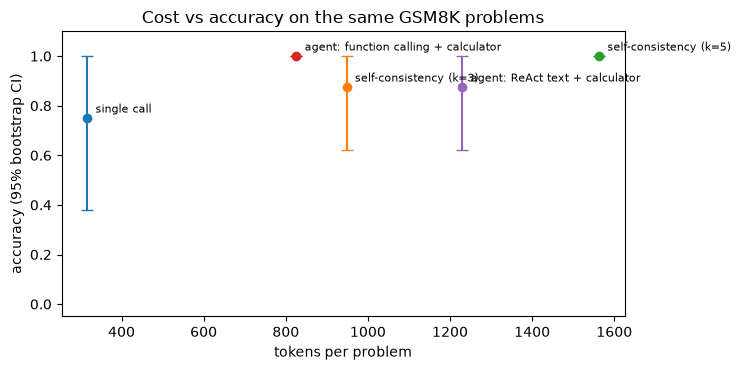

In [30]:
def pattern_row(name, oks, calls, tokens, seconds):
    low, high = bootstrap_ci(np.asarray(oks, dtype=float))
    return {"pattern": name, "accuracy": np.mean(oks), "95% CI": f"[{low:.2f}, {high:.2f}]", "LLM calls / problem": np.mean(calls),
            "tokens / problem": np.mean(tokens), "LLM seconds / problem": np.mean(seconds)}


head_rows = []
for k in (1, 3, VOTE_K):
    sub = vote_df[vote_df.k == k]
    head_rows.append(pattern_row("single call" if k == 1 else f"self-consistency (k={k})", sub.vote_ok, [k] * len(sub), sub.tokens, sub.llm_seconds))
head_rows.append(pattern_row("agent: function calling + calculator", gsm_df.agent_ok, gsm_df.agent_calls, gsm_df.agent_tokens, gsm_df.agent_latency))
head_rows.append(pattern_row("agent: ReAct text + calculator", [is_correct(parse_final_number(r.answer), g) for r, g in zip(react_runs, GSM_SET.gold)],
                             [r.llm_calls for r in react_runs], [r.tokens for r in react_runs], [r.latency_s for r in react_runs]))
head_to_head = pd.DataFrame(head_rows).set_index("pattern")
print(f"GSM8K hard subset, n = {len(GSM_SET)} problems (same problems for every row)\n")
print(head_to_head.round(2).to_string())
best_acc = head_to_head.accuracy.max()
cheapest_best = head_to_head[head_to_head.accuracy == best_acc].sort_values("tokens / problem").index[0]
print(f"\n→ Highest accuracy on this run: {best_acc:.0%}; the cheapest pattern reaching it is '{cheapest_best}'.")
print(f"→ Every CI is wide (n = {len(GSM_SET)}): these differences are not statistically established; the cost column is.")

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for name, row in head_to_head.iterrows():
    low, high = map(float, row["95% CI"].strip("[]").split(","))
    ax.errorbar(row["tokens / problem"], row.accuracy, yerr=[[row.accuracy - low], [high - row.accuracy]], fmt="o", capsize=4)
    ax.annotate(name, (row["tokens / problem"], row.accuracy), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set(xlabel="tokens per problem", ylabel="accuracy (95% bootstrap CI)", ylim=(-0.05, 1.1), title="Cost vs accuracy on the same GSM8K problems")
plt.tight_layout()
plt.show()

**Decision guide** — walk down and stop at the first "yes":

```
Can one call (with retrieval) meet the quality bar on a labelled set? ─── yes ─► single call
  │ no
Are the steps known in advance?  ── yes ─► prompt chain with code gates (+ router if inputs fall into categories,
  │ no                                     + sectioning for independent parts, + voting if answers are comparable)
Is there a verifiable evaluator (tests, validator)? ── yes ─► evaluator–optimizer (+ Reflexion memory for repeated attempts)
  │ no
Can the tool path be planned up front? ── yes ─► plan-and-execute / ReWOO (replan at checkpoints)
  │ no
Open-ended, path depends on what you find ─► agent loop (function calling) with guards, budgets and escalation
```

Always attach the numbers that justify the step up: accuracy with a CI on a labelled set, calls, tokens and latency — on your model, not someone else's benchmark.

### ✍️ Your Turn

"Tokens per **correct** answer" is a useful single cost-effectiveness number. From the dictionary `arms` (accuracy, tokens per problem) compute a dict `name → tokens per correct answer` rounded to 1 decimal, and store the name of the most cost-effective arm in `best_value_arm`.

In [31]:
arms = {"single": (0.75, 800), "vote5": (0.875, 4000), "agent": (0.875, 1500)}
tokens_per_correct = None  # TODO: dict name -> round(tokens / accuracy, 1)
best_value_arm = None  # TODO
check("tokens_per_correct", tokens_per_correct, {"single": 1066.7, "vote5": 4571.4, "agent": 1714.3}, hint="{k: round(t / a, 1) for k, (a, t) in arms.items()}")
check("best_value_arm", best_value_arm, "single", hint="min(tokens_per_correct, key=tokens_per_correct.get)")

⏳ tokens_per_correct: not attempted yet — replace None with your answer.
⏳ best_value_arm: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
arms = {"single": (0.75, 800), "vote5": (0.875, 4000), "agent": (0.875, 1500)}
tokens_per_correct = {name: round(tokens / accuracy, 1) for name, (accuracy, tokens) in arms.items()}
best_value_arm = min(tokens_per_correct, key=tokens_per_correct.get)
check("tokens_per_correct", tokens_per_correct, {"single": 1066.7, "vote5": 4571.4, "agent": 1714.3})
check("best_value_arm", best_value_arm, "single")
```

Cost-effectiveness is not the whole decision: if a wrong answer is expensive, the extra accuracy of `agent` may be worth its tokens. State the cost of errors, then choose.
</details>

> 💡 **Interview angle:** "Design question: which architecture would you use?" — restate the constraints (latency, cost per request, error cost, how predictable the steps are, whether a verifier exists), propose the simplest pattern that could work, name the upgrade path (router → chain → evaluator loop → agent), and describe the offline evaluation that decides: a labelled set, accuracy with CIs, calls, tokens, p95 latency.

## 🔧 Build It From Scratch

A tiny agent framework in about 100 lines of code — the parts every framework (OpenAI Agents SDK, PydanticAI, smolagents, LangGraph's prebuilt agent) implements:

1. **`ToolRegistry`** — a decorator that turns a Python function into a tool: JSON Schema from **type hints** (`str`, `int`, `float`, `bool`, `list[...]`, `Literal[...]`, `X | None`), descriptions from the **docstring** (first paragraph + Google-style `Args:`), `required` = parameters without defaults, and argument **validation** before calling.
2. **`MiniAgent`** — the loop with **max steps**, **repeated-call detection**, a **token budget**, errors returned to the model, and a **structured final answer** produced with `response_format` JSON Schema and validated.

The model is any async callable `model(messages, tools=..., response_format=...) → {"message": ..., "tokens": int}`, so we can test the loop with a **scripted fake model** (deterministic) and then run it once for real.

In [32]:
import types

PY_TO_JSON = {str: "string", int: "integer", float: "number", bool: "boolean"}


def type_to_schema(tp):
    origin, args = typing.get_origin(tp), typing.get_args(tp)
    if tp in PY_TO_JSON:
        return {"type": PY_TO_JSON[tp]}
    if origin is typing.Literal:
        return {"type": PY_TO_JSON[type(args[0])], "enum": list(args)}
    if origin is list:
        return {"type": "array", "items": type_to_schema(args[0])} if args else {"type": "array"}
    if origin in (typing.Union, types.UnionType) and type(None) in args and len(args) == 2:
        inner = type_to_schema(next(a for a in args if a is not type(None)))
        return {**inner, "type": [inner["type"], "null"]}
    raise TypeError(f"unsupported type hint: {tp!r}")


def parse_docstring(doc):
    """First paragraph → description; 'Args:' lines 'name: text' (or 'name (type): text') → parameter descriptions."""
    doc = inspect.cleandoc(doc or "")
    description = doc.split("\n\n")[0].replace("\n", " ").strip()
    params, current, in_args = {}, None, False
    for line in doc.splitlines():
        if line.strip() in ("Args:", "Arguments:"):
            in_args = True
            continue
        if in_args:
            match = re.match(r"^\s{2,}(\w+)(?:\s*\([^)]*\))?:\s*(.*)$", line)
            if match:
                current = match.group(1)
                params[current] = match.group(2).strip()
            elif line.strip() and current and line.startswith(" " * 6):
                params[current] += " " + line.strip()
            elif line.strip() and not line.startswith(" "):
                in_args = False
    return description, params


class ToolRegistry:
    def __init__(self):
        self.functions, self.specs = {}, {}

    def tool(self, fn):
        hints = typing.get_type_hints(fn)
        description, param_docs = parse_docstring(fn.__doc__)
        properties, required = {}, []
        for name, param in inspect.signature(fn).parameters.items():
            properties[name] = type_to_schema(hints[name])
            if name in param_docs:
                properties[name]["description"] = param_docs[name]
            if param.default is inspect.Parameter.empty:
                required.append(name)
        self.functions[fn.__name__] = fn
        self.specs[fn.__name__] = {"type": "function", "function": {"name": fn.__name__, "description": description, "parameters": {
            "type": "object", "properties": properties, "required": required, "additionalProperties": False}}}
        return fn

    def schemas(self):
        return list(self.specs.values())

    def call(self, name, raw_args):
        if name not in self.functions:
            raise LookupError(f"unknown tool {name!r}; available: {sorted(self.functions)}")
        args = json.loads(raw_args or "{}")
        jsonschema.validate(args, self.specs[name]["function"]["parameters"])
        return self.functions[name](**args)


@dataclass
class MiniResult:
    answer: dict | None
    stop_reason: str
    steps: int
    tokens: int
    tool_calls: list


class MiniAgent:
    def __init__(self, model, registry, system, answer_schema, max_steps=6, token_budget=20_000, max_repeats=2):
        self.model, self.registry, self.system, self.answer_schema = model, registry, system, answer_schema
        self.max_steps, self.token_budget, self.max_repeats = max_steps, token_budget, max_repeats

    async def run(self, question):
        messages = [{"role": "system", "content": self.system}, {"role": "user", "content": question}]
        tokens, counts, made = 0, Counter(), []
        for step in range(1, self.max_steps + 1):
            reply = await self.model(messages, tools=self.registry.schemas())
            tokens += reply["tokens"]
            if tokens > self.token_budget:
                return MiniResult(None, "token_budget", step, tokens, made)
            message = reply["message"]
            messages.append(message)
            calls = message.get("tool_calls") or []
            if not calls:
                final = await self.model(messages + [{"role": "user", "content": "Give the final answer as JSON matching the schema."}],
                                         response_format={"type": "json_schema", "json_schema": {"name": "final", "schema": self.answer_schema, "strict": True}})
                try:
                    answer = json.loads(final["message"]["content"] or "")
                    jsonschema.validate(answer, self.answer_schema)
                except (json.JSONDecodeError, jsonschema.ValidationError):
                    return MiniResult(None, "invalid_final_answer", step, tokens + final["tokens"], made)
                return MiniResult(answer, "final_answer", step, tokens + final["tokens"], made)
            for call in calls:
                key = canonical_action(call["function"]["name"], call["function"]["arguments"])
                counts[key] += 1
                if counts[key] > self.max_repeats:
                    return MiniResult(None, "repeated_call", step, tokens, made)
                try:
                    content = json.dumps(self.registry.call(call["function"]["name"], call["function"]["arguments"]), default=str)
                except Exception as exc:
                    content = json.dumps({"error": f"{type(exc).__name__}: {str(exc)[:200]}"})
                made.append(key)
                messages.append({"role": "tool", "tool_call_id": call["id"], "content": content})
        return MiniResult(None, "max_steps", self.max_steps, tokens, made)


def source_lines(*objects):
    """Lines of source of functions, or of every method of a class (notebook classes have no source file of their own)."""
    total = 0
    for obj in objects:
        members = [m for m in vars(obj).values() if inspect.isfunction(m)] if inspect.isclass(obj) else [obj]
        total += sum(len(inspect.getsource(m).splitlines()) for m in members)
    return total


FRAMEWORK_LINES = source_lines(type_to_schema, parse_docstring, ToolRegistry, MiniAgent)
print(f"framework size: {FRAMEWORK_LINES} lines of function and method code (+ the MiniResult dataclass and canonical_action from Section 10)")

framework size: 90 lines of function and method code (+ the MiniResult dataclass and canonical_action from Section 10)


**Test 1 — schemas equal hand-written expectations.**

In [33]:
registry = ToolRegistry()


@registry.tool
def search_passages(query: str, k: int = 3, sources: list[str] | None = None) -> list:
    """Search the local Wikipedia paragraphs.

    Args:
        query: Keywords to search for.
        k: Number of paragraphs to return.
        sources (list): Optional list of titles to restrict the search to.
    """
    hits = search_titles(query, k=max(k, 1) * (3 if sources else 1))
    return [{"title": t, "text": PARAGRAPHS[t][:400]} for t in hits if not sources or t in sources][:k]


@registry.tool
def convert_units(value: float, unit: typing.Literal["km", "mile"], round_result: bool = True) -> float:
    """Convert a distance between kilometres and miles.

    Args:
        value: The distance to convert.
        unit: The unit of `value`; the result is in the other unit.
        round_result: Round to 2 decimals.
    """
    result = value * 0.621371 if unit == "km" else value / 0.621371
    return round(result, 2) if round_result else result


EXPECTED_SCHEMAS = [
    {"type": "function", "function": {"name": "search_passages", "description": "Search the local Wikipedia paragraphs.", "parameters": {
        "type": "object", "properties": {
            "query": {"type": "string", "description": "Keywords to search for."},
            "k": {"type": "integer", "description": "Number of paragraphs to return."},
            "sources": {"type": ["array", "null"], "items": {"type": "string"}, "description": "Optional list of titles to restrict the search to."}},
        "required": ["query"], "additionalProperties": False}}},
    {"type": "function", "function": {"name": "convert_units", "description": "Convert a distance between kilometres and miles.", "parameters": {
        "type": "object", "properties": {
            "value": {"type": "number", "description": "The distance to convert."},
            "unit": {"type": "string", "enum": ["km", "mile"], "description": "The unit of `value`; the result is in the other unit."},
            "round_result": {"type": "boolean", "description": "Round to 2 decimals."}},
        "required": ["value", "unit"], "additionalProperties": False}}},
]
assert registry.schemas() == EXPECTED_SCHEMAS, json.dumps(registry.schemas(), indent=1)
for spec in registry.schemas():
    jsonschema.Draft202012Validator.check_schema(spec["function"]["parameters"])
assert registry.call("convert_units", '{"value": 10, "unit": "km"}') == 6.21
try:
    registry.call("convert_units", '{"value": 10, "unit": "furlong"}')
    raise AssertionError("validation should have failed")
except jsonschema.ValidationError as exc:
    print("argument validation works:", exc.message)
print("✅ generated schemas equal the hand-written ones and are valid JSON Schema")

argument validation works: 'furlong' is not one of ['km', 'mile']
✅ generated schemas equal the hand-written ones and are valid JSON Schema


**Test 2 — the loop stops for the right reason, with a scripted fake model.**

In [34]:
class ScriptedModel:
    """A deterministic stand-in for an LLM: returns pre-written replies in order and records what it was sent."""

    def __init__(self, replies, tokens_per_reply=500):
        self.replies, self.tokens_per_reply, self.requests = list(replies), tokens_per_reply, []

    async def __call__(self, messages, tools=None, response_format=None):
        self.requests.append({"n_messages": len(messages), "structured": response_format is not None})
        return {"message": self.replies.pop(0), "tokens": self.tokens_per_reply}


def fake_call(call_id, name, args):
    return {"role": "assistant", "content": None, "tool_calls": [{"id": call_id, "type": "function", "function": {"name": name, "arguments": json.dumps(args)}}]}


ANSWER_SCHEMA = {"type": "object", "properties": {"answer": {"type": "string"}, "supporting_titles": {"type": "array", "items": {"type": "string"}}},
                 "required": ["answer", "supporting_titles"], "additionalProperties": False}
system = "Answer questions with the tools."

looping = ScriptedModel([fake_call(f"c{i}", "convert_units", {"unit": "km", "value": 5}) for i in range(10)])
r_repeat = await MiniAgent(looping, registry, system, ANSWER_SCHEMA, max_repeats=2).run("loop please")
assert (r_repeat.stop_reason, r_repeat.steps, len(r_repeat.tool_calls)) == ("repeated_call", 3, 2), r_repeat

expensive = ScriptedModel([fake_call(f"c{i}", "convert_units", {"unit": "km", "value": i}) for i in range(10)], tokens_per_reply=9_000)
r_budget = await MiniAgent(expensive, registry, system, ANSWER_SCHEMA, token_budget=20_000).run("spend")
assert (r_budget.stop_reason, r_budget.steps) == ("token_budget", 3), r_budget

wandering = ScriptedModel([fake_call(f"c{i}", "convert_units", {"unit": "mile", "value": i}) for i in range(10)])
r_steps = await MiniAgent(wandering, registry, system, ANSWER_SCHEMA, max_steps=4).run("wander")
assert (r_steps.stop_reason, r_steps.steps, len(r_steps.tool_calls)) == ("max_steps", 4, 4), r_steps

happy = ScriptedModel([fake_call("c1", "no_such_tool", {}), fake_call("c2", "convert_units", {"unit": "km", "value": 42.195}),
                       {"role": "assistant", "content": "A marathon is about 26.22 miles."},
                       {"role": "assistant", "content": json.dumps({"answer": "26.22 miles", "supporting_titles": []})}])
r_happy = await MiniAgent(happy, registry, system, ANSWER_SCHEMA).run("How many miles is a marathon?")
assert r_happy.stop_reason == "final_answer" and r_happy.answer["answer"] == "26.22 miles" and happy.requests[-1]["structured"]
for label, r in [("repeat", r_repeat), ("budget", r_budget), ("max steps", r_steps), ("happy path", r_happy)]:
    print(f"{label:10s} → stop={r.stop_reason:13s} steps={r.steps} tokens={r.tokens:>6,} tool calls={len(r.tool_calls)}")
print("✅ the loop terminates on repetition, token budget and max steps, returns tool errors to the model, and validates the final answer")

repeat     → stop=repeated_call steps=3 tokens= 1,500 tool calls=2
budget     → stop=token_budget  steps=3 tokens=27,000 tool calls=2
max steps  → stop=max_steps     steps=4 tokens= 2,000 tool calls=4
happy path → stop=final_answer  steps=3 tokens= 2,000 tool calls=2
✅ the loop terminates on repetition, token budget and max steps, returns tool errors to the model, and validates the final answer


**Run it once for real** against the local LLM, on the bridge question from Section 8's dev set.

In [35]:
async def real_model(messages, tools=None, response_format=None):
    reply = await llm(messages, tools=tools, response_format=response_format, max_tokens=1024, label="mini-framework")
    return {"message": reply.message, "tokens": reply.tokens}


framework_item = HOTPOT_DEV.iloc[0]
real_result = await MiniAgent(real_model, registry, "Answer the multi-hop question using search_passages, one fact per search. "
                              "When you know the answer, reply briefly without calling tools.", ANSWER_SCHEMA, max_steps=5,
                              token_budget=15_000).run(framework_item.question)
print(f"question: {framework_item.question}\nresult: {real_result.answer} | stop={real_result.stop_reason} | steps={real_result.steps} | "
      f"tokens={real_result.tokens:,}\ntool calls: {real_result.tool_calls}")
if real_result.answer:
    jsonschema.validate(real_result.answer, ANSWER_SCHEMA)
    print(f"gold: {framework_item.answer!r} → F1 {f1_score(real_result.answer['answer'], framework_item.answer):.2f} | ✅ answer matches the schema")
if not real_result.tool_calls:
    print("→ On this run the model answered from its own knowledge without calling search_passages (no supporting titles). "
          "The loop behaved as designed; if answers must be grounded, force the first tool call (tool_choice='required') "
          "or reject answers whose supporting_titles are empty.")

question: In what state is the manufacturer of Bisquick headquartered?
result: {'answer': 'Minnesota', 'supporting_titles': []} | stop=final_answer | steps=1 | tokens=501
tool calls: []
gold: 'Minnesota' → F1 1.00 | ✅ answer matches the schema
→ On this run the model answered from its own knowledge without calling search_passages (no supporting titles). The loop behaved as designed; if answers must be grounded, force the first tool call (tool_choice='required') or reject answers whose supporting_titles are empty.


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Voting on raw strings

"$1,200", "1200" and "1,200.00" are the same answer. Majority voting over raw strings splits the vote. We re-vote the **real** samples from Section 4 both ways.

In [36]:
def raw_final(text):
    match = re.search(r"final answer\s*[:=]?\s*(.+)", text or "", re.I)
    return match.group(1).strip() if match else (text or "").strip()[-20:]


raw_ok, norm_ok, split_votes = [], [], 0
for (_, item), replies in zip(GSM_SET.iterrows(), all_samples):
    raw = [raw_final(r.text) for r in replies]
    normalized = [None if parse_final_number(r.text) is None else round(parse_final_number(r.text), 6) for r in replies]
    raw_ok.append(is_correct(parse_final_number(majority_vote(raw)), item.gold))
    norm_ok.append(is_correct(majority_vote(normalized), item.gold))
    split_votes += len(set(raw)) > len(set(v for v in normalized if v is not None))
print(f"real samples from Section 4: raw-string vote accuracy {np.mean(raw_ok):.0%} vs normalized-number vote {np.mean(norm_ok):.0%}; "
      f"problems whose raw final strings were more varied than their numbers: {split_votes}/{len(GSM_SET)}")
print("   example raw finals:", [raw_final(r.text) for r in all_samples[0]])
if split_votes == 0:
    print("   On this run the model wrote every final number the same way, so raw voting happened to work. Formatting drifts "
          "with prompts, temperature and models — this is what happens when it does (illustrative input):")
demo_finals = ["$1,200", "1200", "1,200.00", "1150", "1150"]
print(f"❌ raw strings {demo_finals} → majority {majority_vote(demo_finals)!r} (the three votes for 1200 are split)")
print(f"✅ normalized numbers → majority {majority_vote([parse_final_number(a) for a in demo_finals])!r}")

real samples from Section 4: raw-string vote accuracy 100% vs normalized-number vote 100%; problems whose raw final strings were more varied than their numbers: 0/8
   example raw finals: ['1248', '1248', '3744', '1248', '1248']
   On this run the model wrote every final number the same way, so raw voting happened to work. Formatting drifts with prompts, temperature and models — this is what happens when it does (illustrative input):
❌ raw strings ['$1,200', '1200', '1,200.00', '1150', '1150'] → majority '1150' (the three votes for 1200 are split)
✅ normalized numbers → majority 1200.0


### ❌ Pitfall 2 — Detecting repeated actions by comparing raw JSON

Models don't preserve key order or spacing, so string comparison misses genuine repeats and the loop runs on.

In [37]:
calls_seen = ['{"query": "Ed Wood", "k": 3}', '{"k":3,"query":"Ed Wood"}', '{ "query" : "Ed Wood", "k" : 3 }']
print(f"❌ raw strings: {len(set(calls_seen))} 'different' calls → a max_repeats=2 guard never fires")
print(f"✅ canonical JSON: {len({canonical_action('search', c) for c in calls_seen})} distinct call → "
      f"LoopGuard says {LoopGuard(max_repeats=2).check([tool_span('search', c, str(i)) for i, c in enumerate(calls_seen)], 0, 0)!r}")

❌ raw strings: 3 'different' calls → a max_repeats=2 guard never fires
✅ canonical JSON: 1 distinct call → LoopGuard says 'repeated_action'


### ❌ Pitfall 3 — Reporting the score of the evaluator you optimized against

An optimizer can "pass" by special-casing the feedback tests. We generate a cheat solution **mechanically** — a lookup table built from the two feedback tests of a real MBPP task — and grade it with the real subprocess evaluator.

In [38]:
def lookup_table_cheat(task):
    """Build 'def f(*args): return {repr(args): expected}[repr(args)]' from simple 'assert f(...) == literal' feedback tests."""
    table, name = {}, None
    for test in task.test_list[:2]:
        node = ast.parse(test).body[0]
        if not (isinstance(node, ast.Assert) and isinstance(node.test, ast.Compare) and isinstance(node.test.left, ast.Call)
                and isinstance(node.test.left.func, ast.Name) and not node.test.left.keywords):
            return None
        name = node.test.left.func.id
        args = tuple(ast.literal_eval(a) for a in node.test.left.args)
        table[repr(args)] = ast.unparse(node.test.comparators[0])
    body = ", ".join(f"{k!r}: {v}" for k, v in table.items())
    return f"def {name}(*args):\n    return {{{body}}}.get(repr(args))\n"


cheat_task, cheat_code = None, None
for _, task in MBPP_SET.iterrows():
    try:
        cheat_code = lookup_table_cheat(task)
    except (ValueError, SyntaxError):
        cheat_code = None
    if cheat_code:
        cheat_task = task
        break
if cheat_task is None:
    print("⏭️ no task in this sample has simple literal asserts to build the cheat from")
else:
    visible = run_tests(cheat_code, cheat_task.test_list[:2], cheat_task.test_imports)
    hidden = run_tests(cheat_code, cheat_task.test_list[2:], cheat_task.test_imports)
    print(f"task {cheat_task.task_id}: {cheat_task.prompt}\ncheat:\n{cheat_code}")
    print(f"❌ score on the feedback tests it was built from: {np.mean(visible['passed']):.0%}")
    print(f"✅ score on the held-out test: {np.mean(hidden['passed']):.0%} → always report a set the optimizer never saw")

task 431: Write a function that takes two lists and returns true if they have at least one common element.
cheat:
def common_element(*args):
    return {'([1, 2, 3, 4, 5], [5, 6, 7, 8, 9])': True, '([1, 2, 3, 4, 5], [6, 7, 8, 9])': None}.get(repr(args))

❌ score on the feedback tests it was built from: 100%
✅ score on the held-out test: 0% → always report a set the optimizer never saw


### ❌ Pitfall 4 — Executing a plan with dangling references

A planner can reference evidence that is never produced (`#E3` when only `#E1`, `#E2` exist, or a step that uses `#E2` before it runs). `substitute` then silently leaves `#E3` in the query, and the search runs on garbage. Validate plans **before** executing them.

In [39]:
bad_plan = [{"id": "#E1", "tool": "Search", "input": "Kiss and Tell 1945 film actress"},
            {"id": "#E2", "tool": "Search", "input": "#E3 government position"}]
print(f"❌ executes anyway: query = {substitute(bad_plan[1]['input'], {'#E1': 'Shirley Temple'})!r} → top hit {search_titles(substitute(bad_plan[1]['input'], {}), k=1)}")


def validate_plan(steps):
    defined, errors = set(), []
    for step in steps:
        missing = sorted(set(re.findall(r"#E\d+", step["input"])) - defined)
        if missing:
            errors.append(f"{step['id']} uses undefined evidence {missing}")
        defined.add(step["id"])
    return errors


print(f"✅ rejected before any tool runs: {validate_plan(bad_plan)}")

❌ executes anyway: query = '#E3 government position' → top hit ['Composer laureate']
✅ rejected before any tool runs: ["#E2 uses undefined evidence ['#E3']"]


### ❌ Pitfall 5 — Scoring QA answers with raw string equality

"Animorphs." vs "Animorphs", "The United States" vs "United States": raw `==` calls correct answers wrong, and the error differs between architectures (some add punctuation), which biases the comparison. We re-score the **real** answers collected in Sections 5 and 8.

In [40]:
collected = [(row.answer, row.gold) for row in dev_df.itertuples()] + [(orch_answer, orch_item.answer)]
raw_scores = [float(pred.strip() == gold) for pred, gold in collected]
em_scores = [exact_match(pred, gold) for pred, gold in collected]
print(pd.DataFrame({"prediction": [p for p, _ in collected], "gold": [g for _, g in collected], "raw ==": raw_scores, "normalized EM": em_scores,
                    "F1": [round(f1_score(p, g), 2) for p, g in collected]}).to_string(index=False))
print(f"❌ raw equality accuracy {np.mean(raw_scores):.0%} vs ✅ normalized EM {np.mean(em_scores):.0%} (and token F1 {np.mean([f1_score(p, g) for p, g in collected]):.2f}) on the same {len(collected)} answers")

 prediction        gold  raw ==  normalized EM  F1
  Minnesota   Minnesota     1.0            1.0 1.0
  Minnesota   Minnesota     1.0            1.0 1.0
  Minnesota   Minnesota     1.0            1.0 1.0
Velvetpark.  Velvetpark     0.0            1.0 1.0
 Velvetpark  Velvetpark     1.0            1.0 1.0
Velvetpark.  Velvetpark     0.0            1.0 1.0
Papa Gino's Papa Gino's     1.0            1.0 1.0
❌ raw equality accuracy 71% vs ✅ normalized EM 100% (and token F1 1.00) on the same 7 answers


## 🏋️ Practice Exercises

Five of the six are deterministic (no LLM) so the checkers are exact. Try each before opening the solution.

### 🟢 Exercise 1 — Router metrics from predictions

For the router predictions below, compute `(accuracy, macro_precision, macro_recall)` over the classes that appear in `y_true` or `y_pred`. A class with no predictions has precision 0.

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_true = ["card_arrival", "card_arrival", "lost_or_stolen_card", "pin_blocked", "pin_blocked", "pin_blocked"]
y_pred = ["card_arrival", "lost_or_stolen_card", "lost_or_stolen_card", "pin_blocked", "card_arrival", "pin_blocked"]
router_metrics = None  # TODO: (accuracy, macro_precision, macro_recall) as floats
check("router_metrics", router_metrics,
      (float(accuracy_score(y_true, y_pred)), float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
       float(recall_score(y_true, y_pred, average="macro", zero_division=0))),
      hint="Per class c: precision = TP / (predicted c), recall = TP / (actual c); average over classes.")

⏳ router_metrics: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_true = ["card_arrival", "card_arrival", "lost_or_stolen_card", "pin_blocked", "pin_blocked", "pin_blocked"]
y_pred = ["card_arrival", "lost_or_stolen_card", "lost_or_stolen_card", "pin_blocked", "card_arrival", "pin_blocked"]
classes = sorted(set(y_true) | set(y_pred))
pairs = list(zip(y_true, y_pred))
precisions, recalls = [], []
for c in classes:
    tp = sum(t == c and p == c for t, p in pairs)
    predicted, actual = sum(p == c for _, p in pairs), sum(t == c for t, _ in pairs)
    precisions.append(tp / predicted if predicted else 0.0)
    recalls.append(tp / actual if actual else 0.0)
router_metrics = (sum(t == p for t, p in pairs) / len(pairs), float(np.mean(precisions)), float(np.mean(recalls)))
check("router_metrics", router_metrics,
      (float(accuracy_score(y_true, y_pred)), float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
       float(recall_score(y_true, y_pred, average="macro", zero_division=0))))
```

Macro averages weight every intent equally, so rare intents that the router gets wrong pull the score down — useful when every route matters.
</details>

### 🟢 Exercise 2 — Repeated-action detector

`first_repeat_index(actions, max_repeats)` receives `(tool_name, args_dict)` pairs in order and returns the **index** of the first action that would be the `(max_repeats + 1)`-th occurrence of the same tool with the same arguments (key order must not matter), or `-1` if none.

In [42]:
def first_repeat_index(actions, max_repeats):
    return None  # TODO


actions_demo = [("search", {"q": "a", "k": 3}), ("search", {"q": "b"}), ("search", {"k": 3, "q": "a"}), ("calc", {"x": "1+1"}),
                ("search", {"q": "a", "k": 3})]
check("first_repeat_index", None if first_repeat_index(actions_demo, 2) is None else
      (first_repeat_index(actions_demo, 2), first_repeat_index(actions_demo, 1), first_repeat_index(actions_demo, 3)), (4, 2, -1),
      hint="key = (name, json.dumps(args, sort_keys=True)); count with a Counter as you go.")

⏳ first_repeat_index: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def first_repeat_index(actions, max_repeats):
    counts = Counter()
    for i, (name, args) in enumerate(actions):
        key = (name, json.dumps(args, sort_keys=True))
        counts[key] += 1
        if counts[key] > max_repeats:
            return i
    return -1


actions_demo = [("search", {"q": "a", "k": 3}), ("search", {"q": "b"}), ("search", {"k": 3, "q": "a"}), ("calc", {"x": "1+1"}),
                ("search", {"q": "a", "k": 3})]
check("first_repeat_index", (first_repeat_index(actions_demo, 2), first_repeat_index(actions_demo, 1), first_repeat_index(actions_demo, 3)), (4, 2, -1))
```
</details>

### 🟢 Exercise 3 — Budget calculator: ReAct vs ReWOO prompt tokens

A ReAct agent re-sends its history: step *i* (0-based) has `base + i × growth` prompt tokens. A ReWOO run has one planner prompt (`plan_prompt`) and one solver prompt that contains the base plus **all** evidence (`solve_base + steps × growth`). For `base=900, growth=700, steps=4, plan_prompt=400, solve_base=400`, compute `(react_prompt_tokens, rewoo_prompt_tokens)`.

In [43]:
base, growth, steps, plan_prompt, solve_base = 900, 700, 4, 400, 400
budget_tokens = None  # TODO: (react_prompt_tokens, rewoo_prompt_tokens)
check("budget_tokens", budget_tokens, (7800, 3600), hint="sum(base + i * growth for i in range(steps)) and plan_prompt + solve_base + steps * growth")

⏳ budget_tokens: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
base, growth, steps, plan_prompt, solve_base = 900, 700, 4, 400, 400
budget_tokens = (sum(base + i * growth for i in range(steps)), plan_prompt + solve_base + steps * growth)
check("budget_tokens", budget_tokens, (7800, 3600))
```

ReAct's prompt tokens grow **quadratically** with steps (`n·base + growth·n(n−1)/2`); ReWOO's grow linearly because observations are not fed back to a planner step after step — the token saving the ReWOO paper reports.
</details>

### 🟡 Exercise 4 — A defensive ReAct parser

Write `parse_react(text)` returning `("action", tool, expression)`, `("final", answer)`, `("empty",)` or `("malformed",)`:

- whitespace-only → `("empty",)`; the **first** of `Action:`/`Final Answer:` wins;
- `Action Input` may be plain text **or** a JSON object (possibly in ``` fences) with an `"expression"` key → return the expression;
- ignore anything after a self-written `Observation:` line.

In [44]:
def parse_react(text):
    return None  # TODO


FENCE = "`" * 3                                              # a Markdown code fence, built so it can't end this notebook's code blocks
REACT_CASES = [
    ("Thought: add\nAction: calculator\nAction Input: 2 + 3", ("action", "calculator", "2 + 3")),
    (f'Thought: x\nAction: calculator\nAction Input: {FENCE}json\n{{"expression": "12*7"}}\n{FENCE}', ("action", "calculator", "12*7")),
    ("Thought: done\nFinal Answer: 42", ("final", "42")),
    ("Thought: a\nAction: calculator\nAction Input: 1+1\nObservation: 2\nFinal Answer: 2", ("action", "calculator", "1+1")),
    ("Observation: 2\nFinal Answer: 3", ("malformed",)),
    ("   \n", ("empty",)),
    ("The answer is 7.", ("malformed",)),
]
check("parse_react", None if parse_react(REACT_CASES[0][0]) is None else [parse_react(t) for t, _ in REACT_CASES], [e for _, e in REACT_CASES],
      hint="Cut at the first line starting with 'Observation:' first; then regex for Action/Action Input and Final Answer; strip fences and try json.loads.")

⏳ parse_react: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
FENCE = "`" * 3


def parse_react(text):
    if not text or not text.strip():
        return ("empty",)
    text = re.split(r"^\s*Observation\s*:", text, maxsplit=1, flags=re.M)[0]
    action = re.search(r"Action\s*:\s*([A-Za-z_]+)\s*\n+\s*Action Input\s*:\s*(.+)", text, re.S)
    final = re.search(r"Final Answer\s*:\s*(.+)", text, re.S)
    if action and (not final or action.start() < final.start()):
        raw = re.sub(rf"^{FENCE}(?:json)?\s*|\s*{FENCE}$", "", action.group(2).strip()).strip()
        try:
            parsed = json.loads(raw)
            expression = parsed["expression"] if isinstance(parsed, dict) else str(parsed)
        except (json.JSONDecodeError, KeyError):
            expression = raw.splitlines()[0].strip()
        return ("action", action.group(1), expression)
    if final:
        return ("final", final.group(1).strip().splitlines()[0])
    return ("malformed",)


REACT_CASES = [
    ("Thought: add\nAction: calculator\nAction Input: 2 + 3", ("action", "calculator", "2 + 3")),
    (f'Thought: x\nAction: calculator\nAction Input: {FENCE}json\n{{"expression": "12*7"}}\n{FENCE}', ("action", "calculator", "12*7")),
    ("Thought: done\nFinal Answer: 42", ("final", "42")),
    ("Thought: a\nAction: calculator\nAction Input: 1+1\nObservation: 2\nFinal Answer: 2", ("action", "calculator", "1+1")),
    ("Observation: 2\nFinal Answer: 3", ("malformed",)),
    ("   \n", ("empty",)),
    ("The answer is 7.", ("malformed",)),
]
check("parse_react", [parse_react(t) for t, _ in REACT_CASES], [e for _, e in REACT_CASES])
```

Case 5 matters: a reply that *starts* with an invented observation contains no real step, so everything after it is discarded.
</details>

### 🟡 Exercise 5 — Schema from a function signature

Write `schema_from_signature(fn)` returning the `parameters` JSON Schema for functions using `str`, `int`, `float`, `bool`, `list[str]` and `Literal[...]` of strings: `properties` in signature order, `required` = parameters without defaults, `additionalProperties: False`. (No descriptions this time.)

In [45]:
def schema_from_signature(fn):
    return None  # TODO


def book_flight(origin: str, destination: str, passengers: int = 1, cabin: typing.Literal["economy", "business"] = "economy",
                flexible: bool = False, max_price: float = 500.0, tags: list[str] = ()):
    """Book a flight (demo signature only)."""


check("schema_from_signature", schema_from_signature(book_flight), {
    "type": "object", "properties": {"origin": {"type": "string"}, "destination": {"type": "string"}, "passengers": {"type": "integer"},
                                     "cabin": {"type": "string", "enum": ["economy", "business"]}, "flexible": {"type": "boolean"},
                                     "max_price": {"type": "number"}, "tags": {"type": "array", "items": {"type": "string"}}},
    "required": ["origin", "destination"], "additionalProperties": False},
    hint="typing.get_type_hints(fn); inspect.signature(fn).parameters; typing.get_origin / get_args for Literal and list.")

⏳ schema_from_signature: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def schema_from_signature(fn):
    simple = {str: "string", int: "integer", float: "number", bool: "boolean"}
    hints = typing.get_type_hints(fn)
    properties, required = {}, []
    for name, param in inspect.signature(fn).parameters.items():
        tp = hints[name]
        if typing.get_origin(tp) is typing.Literal:
            properties[name] = {"type": "string", "enum": list(typing.get_args(tp))}
        elif typing.get_origin(tp) is list:
            properties[name] = {"type": "array", "items": {"type": simple[typing.get_args(tp)[0]]}}
        else:
            properties[name] = {"type": simple[tp]}
        if param.default is inspect.Parameter.empty:
            required.append(name)
    return {"type": "object", "properties": properties, "required": required, "additionalProperties": False}


def book_flight(origin: str, destination: str, passengers: int = 1, cabin: typing.Literal["economy", "business"] = "economy",
                flexible: bool = False, max_price: float = 500.0, tags: list[str] = ()):
    """Book a flight (demo signature only)."""


check("schema_from_signature", schema_from_signature(book_flight), {
    "type": "object", "properties": {"origin": {"type": "string"}, "destination": {"type": "string"}, "passengers": {"type": "integer"},
                                     "cabin": {"type": "string", "enum": ["economy", "business"]}, "flexible": {"type": "boolean"},
                                     "max_price": {"type": "number"}, "tags": {"type": "array", "items": {"type": "string"}}},
    "required": ["origin", "destination"], "additionalProperties": False})
```

Check `bool` before `int` if you ever use `isinstance` on *values* (`True` is an `int` in Python); with type hints the dict lookup is exact.
</details>

### 🔴 Exercise 6 — Choose an architecture with a pre-registered rule

Implement `choose_architecture(f1, tokens, margin=0.10, n_resamples=4000, seed=0)`:

1. `best` = the arm with the highest mean F1.
2. For every arm, the **paired bootstrap** 95% CI of `mean(f1[arm] − f1[best])`: resample question indices with replacement (`np.random.default_rng(seed).integers(0, n, (n_resamples, n))`), take the 2.5th percentile as the lower bound.
3. Eligible arms: lower bound ≥ `−margin` (the best arm is always eligible). Return the eligible arm with the **fewest mean tokens**.

In [46]:
def choose_architecture(f1, tokens, margin=0.10, n_resamples=4000, seed=0):
    return None  # TODO


base_f1 = np.array([1, 1, 0.5, 1, 0, 1, 1, 0.8, 1, 0, 1, 1, 0.6, 1, 1, 0, 1, 1, 0.9, 1])
arm_f1 = {"react": base_f1, "rewoo": np.where(np.arange(20) == 2, 0.0, base_f1),     # one question worse
          "workflow": base_f1 - 0.3, "single": base_f1 - 0.12}
arm_tokens = {"react": 4200, "rewoo": 2100, "workflow": 900, "single": 300}
check("choose_architecture", choose_architecture(arm_f1, arm_tokens), "rewoo",
      hint="diff = f1[arm] - f1[best]; boot = diff[idx].mean(axis=1); lower = np.percentile(boot, 2.5)")

⏳ choose_architecture: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def choose_architecture(f1, tokens, margin=0.10, n_resamples=4000, seed=0):
    means = {arm: float(np.mean(v)) for arm, v in f1.items()}
    best = max(means, key=means.get)
    n = len(f1[best])
    idx = np.random.default_rng(seed).integers(0, n, (n_resamples, n))
    eligible = []
    for arm, values in f1.items():
        diff = np.asarray(values, dtype=float) - np.asarray(f1[best], dtype=float)
        lower = np.percentile(diff[idx].mean(axis=1), 2.5)
        if arm == best or lower >= -margin:
            eligible.append(arm)
    return min(eligible, key=lambda arm: tokens[arm])


base_f1 = np.array([1, 1, 0.5, 1, 0, 1, 1, 0.8, 1, 0, 1, 1, 0.6, 1, 1, 0, 1, 1, 0.9, 1])
arm_f1 = {"react": base_f1, "rewoo": np.where(np.arange(20) == 2, 0.0, base_f1),
          "workflow": base_f1 - 0.3, "single": base_f1 - 0.12}
arm_tokens = {"react": 4200, "rewoo": 2100, "workflow": 900, "single": 300}
check("choose_architecture", choose_architecture(arm_f1, arm_tokens), "rewoo")
```

`single` is 0.12 worse on *every* question, so its whole CI sits at −0.12 < −0.10; `workflow` is far worse; `rewoo` loses one question (mean −0.025, lower bound ≈ −0.075) and is half the cost of `react`. **Paired** resampling is what makes that small difference measurable.
</details>

## 🚀 Mini Project: Pick the Architecture

**Goal:** a team needs a question-answering service over a Wikipedia paragraph collection. Four candidate architectures, one decision. We evaluate them on **30 HotpotQA distractor questions** (a seeded sample, never used above) against the local BM25 corpus of 5,000+ paragraphs:

| Arm | Architecture | LLM calls |
|---|---|---|
| (a) | **single call**, closed-book (no retrieval) | 1 |
| (b) | **fixed workflow**: BM25 top-5 for the question → answer | 1 |
| (c) | **ReAct agent** (function calling) with a `search` tool, ≤ 5 steps | 1 per step |
| (d) | **plan-and-execute, ReWOO-style**: plan the tool program once → run it → solve | 2 + LLM-tool steps |

**Steps:** state the decision rule → run the four arms → metrics with bootstrap CIs → apply the rule → error analysis → conclusions.

### Step 1 — The decision rule, written before any result exists

Choosing after peeking at results lets noise pick the winner. So the rule is fixed first, in code:

1. **Primary metric:** mean token F1 (official HotpotQA normalization); exact match reported alongside.
2. **Best arm:** highest mean F1.
3. **Non-inferiority:** an arm is acceptable if the **paired bootstrap 95% CI** of per-question `F1(arm) − F1(best)` has a lower bound **≥ −0.10**.
4. **Choice:** the acceptable arm with the **fewest mean tokens per question** (tokens track both cost and latency here).

In [47]:
DECISION_RULE = {"metric": "F1", "margin": 0.10, "confidence": 0.95, "tie_breaker": "fewest mean tokens"}
print("decision rule (fixed before running):", DECISION_RULE)
print(f"test questions: {len(HOTPOT_TEST)} | types {HOTPOT_TEST.type.value_counts().to_dict()} | overlap with dev/extra questions: "
      f"{len(set(HOTPOT_TEST.id) & (set(HOTPOT_DEV.id) | set(HOTPOT_EXTRA.id)))}")
gold_in_corpus = np.mean([all(t in PARAGRAPHS for t in titles) for titles in HOTPOT_TEST.gold_titles])
print(f"questions whose gold paragraphs are in the corpus: {gold_in_corpus:.0%} (they are pooled with {len(TITLES):,} paragraphs in total)")

decision rule (fixed before running): {'metric': 'F1', 'margin': 0.1, 'confidence': 0.95, 'tie_breaker': 'fewest mean tokens'}


test questions: 30 | types {'bridge': 25, 'comparison': 5} | overlap with dev/extra questions: 0
questions whose gold paragraphs are in the corpus: 100% (they are pooled with 5,945 paragraphs in total)


### Step 2 — Run the four arms

In [48]:
async def arm_single(question):
    run = AgentRun(answer=None, stop_reason="final_answer")
    reply = await llm([{"role": "system", "content": "Answer the question from your own knowledge. " + ANSWER_STYLE},
                       {"role": "user", "content": question}], max_tokens=1024, label="mini-single")
    add_usage(run, reply)
    run.answer, run.retrieved = reply.text.strip(), []
    return run


async def arm_workflow(question):
    run = AgentRun(answer=None, stop_reason="final_answer")
    hits = search_titles(question, k=5)
    reply = await llm([{"role": "system", "content": "Answer the question using the passages. " + ANSWER_STYLE},
                       {"role": "user", "content": f"Question: {question}\n\nPassages:\n{format_passages(hits)}"}], max_tokens=1024, label="mini-workflow")
    add_usage(run, reply)
    run.answer, run.retrieved, run.tool_calls = reply.text.strip(), hits, 1
    return run


ARMS = {"(a) single call": arm_single, "(b) retrieve → answer": arm_workflow,
        "(c) ReAct agent": lambda q: react_qa(q, max_steps=5, label="mini-react"),
        "(d) plan-and-execute (ReWOO)": lambda q: rewoo(q, label_prefix="mini-rewoo")}


async def run_arm(arm_fn):
    return await asyncio.gather(*(arm_fn(q) for q in HOTPOT_TEST.question))


mini_start = time.perf_counter()
mini_runs = {}
for arm_name, arm_fn in ARMS.items():
    mini_runs[arm_name], wall = await timed(f"mini-{arm_name}", lambda fn=arm_fn: run_arm(fn))
    print(f"{arm_name:30s} done — wall-clock {wall:.0f}s for {len(HOTPOT_TEST)} questions")

mini_rows = []
for arm_name, runs in mini_runs.items():
    for (_, item), run in zip(HOTPOT_TEST.iterrows(), runs):
        answer = run.answer or ""
        mini_rows.append({"arm": arm_name, "id": item.id, "type": item.type, "gold": item.answer, "answer": answer[:60],
                          "EM": exact_match(answer, item.answer), "F1": f1_score(answer, item.answer),
                          "llm_calls": run.llm_calls, "tool_calls": run.tool_calls, "prompt_tokens": run.prompt_tokens, "tokens": run.tokens,
                          "llm_seconds": run.latency_s, "stop": run.stop_reason,
                          "gold_found": len(set(item.gold_titles) & set(run.retrieved)) if arm_name != "(a) single call" else np.nan})
mini_df = pd.DataFrame(mini_rows)
print(mini_df.pivot(index="id", columns="arm", values="F1").round(2).head(8).to_string())

(a) single call                done — wall-clock 71s for 30 questions


(b) retrieve → answer          done — wall-clock 24s for 30 questions
(c) ReAct agent                done — wall-clock 50s for 30 questions
(d) plan-and-execute (ReWOO)   done — wall-clock 298s for 30 questions
arm                       (a) single call  (b) retrieve → answer  (c) ReAct agent  (d) plan-and-execute (ReWOO)
id                                                                                                             
5a7180205542994082a3e856             0.00                   1.00             1.00                           1.0
5a7613c15542994ccc9186bf             0.00                   1.00             1.00                           0.0
5a78bc6b554299148911f979             0.00                   0.75             0.00                           0.0
5a7b537555429927d897bf90             1.00                   1.00             0.33                           1.0
5a7c49dc55429935c91b514f             0.00                   1.00             1.00                           1.0
5a7dc

### Step 3 — Metrics with bootstrap confidence intervals

n = 30 questions per arm (means per question)

                                F1     F1 95% CI    EM  LLM calls   tokens  prompt share  LLM s  p90 LLM s  both gold paragraphs found
arm                                                                                                                                   
(a) single call               0.33  [0.18, 0.48]  0.23       1.00   377.43          0.33   4.71      11.26                         NaN
(b) retrieve → answer         0.66  [0.50, 0.81]  0.57       1.00   678.80          0.94   1.58       2.37                        0.40
(c) ReAct agent               0.70  [0.54, 0.85]  0.63       2.07  1046.13          0.87   3.31       5.07                        0.37
(d) plan-and-execute (ReWOO)  0.68  [0.52, 0.83]  0.60       3.27  1503.87          0.75  25.20      46.23                        0.57

F1 by question type:
type                          bridge  comparison
arm                                             
(a) single call        

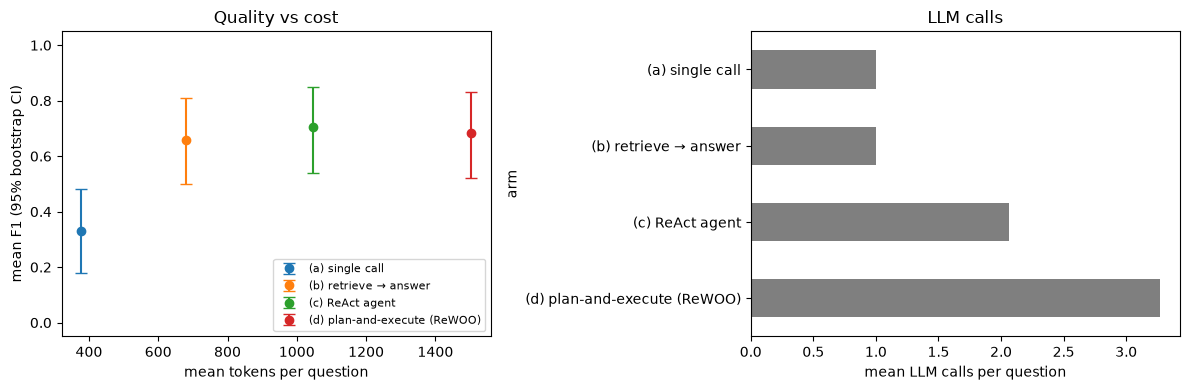

In [49]:
summary_rows = []
for arm_name, sub in mini_df.groupby("arm", sort=False):
    f1_low, f1_high = bootstrap_ci(sub.F1)
    summary_rows.append({"arm": arm_name, "F1": sub.F1.mean(), "F1 95% CI": f"[{f1_low:.2f}, {f1_high:.2f}]", "EM": sub.EM.mean(),
                         "LLM calls": sub.llm_calls.mean(), "tokens": sub.tokens.mean(), "prompt share": sub.prompt_tokens.sum() / sub.tokens.sum(),
                         "LLM s": sub.llm_seconds.mean(), "p90 LLM s": sub.llm_seconds.quantile(0.9),
                         "both gold paragraphs found": (sub.gold_found == 2).mean() if sub.gold_found.notna().any() else np.nan})
mini_summary = pd.DataFrame(summary_rows).set_index("arm")
print(f"n = {len(HOTPOT_TEST)} questions per arm (means per question)\n")
print(mini_summary.round(2).to_string())
print("\nF1 by question type:\n" + mini_df.pivot_table(index="arm", columns="type", values="F1", aggfunc="mean", sort=False).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for arm_name, row in mini_summary.iterrows():
    low, high = map(float, row["F1 95% CI"].strip("[]").split(","))
    axes[0].errorbar(row.tokens, row.F1, yerr=[[row.F1 - low], [high - row.F1]], fmt="o", capsize=4, label=arm_name)
axes[0].set(xlabel="mean tokens per question", ylabel="mean F1 (95% bootstrap CI)", ylim=(-0.05, 1.05), title="Quality vs cost")
axes[0].legend(fontsize=8, loc="lower right")
mini_summary["LLM calls"].plot.barh(ax=axes[1], color="tab:gray")
axes[1].set(xlabel="mean LLM calls per question", title="LLM calls")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

### Step 4 — Apply the rule

In [50]:
f1_matrix = mini_df.pivot(index="id", columns="arm", values="F1")[list(ARMS)]
best_arm = mini_summary.F1.idxmax()
decision_rows = []
for arm_name in ARMS:
    diff = (f1_matrix[arm_name] - f1_matrix[best_arm]).to_numpy()
    low, high = bootstrap_ci(diff) if arm_name != best_arm else (0.0, 0.0)
    decision_rows.append({"arm": arm_name, "mean F1 − best": diff.mean(), "paired 95% CI": f"[{low:+.2f}, {high:+.2f}]",
                          "acceptable (lower ≥ −margin)": arm_name == best_arm or low >= -DECISION_RULE["margin"],
                          "tokens": mini_summary.loc[arm_name, "tokens"]})
decision_df = pd.DataFrame(decision_rows).set_index("arm")
print(decision_df.round(3).to_string())
chosen = decision_df[decision_df["acceptable (lower ≥ −margin)"]].tokens.idxmin()
print(f"\n🏆 best F1: {best_arm} ({mini_summary.loc[best_arm, 'F1']:.2f}) → CHOSEN by the rule: {chosen} "
      f"(F1 {mini_summary.loc[chosen, 'F1']:.2f}, {mini_summary.loc[chosen, 'tokens']:,.0f} tokens and "
      f"{mini_summary.loc[chosen, 'LLM calls']:.1f} LLM calls per question)")
if chosen != best_arm:
    saving = 1 - mini_summary.loc[chosen, "tokens"] / mini_summary.loc[best_arm, "tokens"]
    print(f"   It uses {saving:.0%} fewer tokens than the best-F1 arm while staying within the pre-registered margin.")

                              mean F1 − best   paired 95% CI  acceptable (lower ≥ −margin)    tokens
arm                                                                                                 
(a) single call                       -0.374  [-0.56, -0.20]                         False   377.433
(b) retrieve → answer                 -0.045  [-0.17, +0.06]                         False   678.800
(c) ReAct agent                        0.000  [+0.00, +0.00]                          True  1046.133
(d) plan-and-execute (ReWOO)          -0.020  [-0.16, +0.13]                         False  1503.867

🏆 best F1: (c) ReAct agent (0.70) → CHOSEN by the rule: (c) ReAct agent (F1 0.70, 1,046 tokens and 2.1 LLM calls per question)


### Step 5 — Error analysis

For every arm that retrieves, each wrong answer (F1 < 0.5) gets one category, by rule: **retrieval miss** (not both gold paragraphs were ever retrieved) or **reading/reasoning error** (both were retrieved, answer still wrong). For the agent we also look at stop reasons.

In [51]:
errors = mini_df[(mini_df.F1 < 0.5) & (mini_df.arm != "(a) single call")].copy()
errors["category"] = np.where(errors.gold_found < 2, "retrieval miss", "reading/reasoning error")
print(errors.groupby(["arm", "category"], sort=False).size().unstack(fill_value=0).to_string())
print("\nReAct stop reasons:", mini_df[mini_df.arm == "(c) ReAct agent"].stop.value_counts().to_dict(),
      "| ReWOO stop reasons:", mini_df[mini_df.arm == "(d) plan-and-execute (ReWOO)"].stop.value_counts().to_dict(),
      "(plan_fallback = the planner returned no valid plan twice, so the question itself was searched)")
print("\nexamples of wrong answers:")
print(errors[["arm", "type", "gold", "answer", "category"]].head(6).to_string(index=False, max_colwidth=40))

category                      retrieval miss  reading/reasoning error
arm                                                                  
(b) retrieve → answer                      8                        2
(c) ReAct agent                            6                        3
(d) plan-and-execute (ReWOO)               4                        5

ReAct stop reasons: {'final_answer': 30} | ReWOO stop reasons: {'final_answer': 30} (plan_fallback = the planner returned no valid plan twice, so the question itself was searched)

examples of wrong answers:
                  arm       type                  gold               answer                category
(b) retrieve → answer     bridge           Bath, Maine         William King          retrieval miss
(b) retrieve → answer     bridge a failed coup attempt      Austrian Nazis.          retrieval miss
(b) retrieve → answer     bridge          2 March 1972 No answer available.          retrieval miss
(b) retrieve → answer     bridge         

### Step 6 — Conclusions (computed)

In [52]:
single_f1, retrieval_best = mini_summary.loc["(a) single call", "F1"], mini_summary.drop(index="(a) single call").F1.max()
print(f"1. Retrieval matters: the closed-book single call scored F1 {single_f1:.2f}; the best retrieval arm scored {retrieval_best:.2f}.")
workflow, react, plan = (mini_summary.loc[a] for a in ["(b) retrieve → answer", "(c) ReAct agent", "(d) plan-and-execute (ReWOO)"])
print(f"2. Per question — fixed workflow: {workflow['LLM calls']:.1f} call, {workflow.tokens:,.0f} tokens, {workflow['LLM s']:.1f} LLM-seconds; "
      f"ReAct: {react['LLM calls']:.1f} calls, {react.tokens:,.0f} tokens ({react.tokens / workflow.tokens:.1f}×), {react['LLM s']:.1f} s; "
      f"ReWOO: {plan['LLM calls']:.1f} calls, {plan.tokens:,.0f} tokens, {plan['LLM s']:.1f} s "
      "(LLM-seconds also reflect load on the shared server when the calls ran).")
recall_note = mini_summary["both gold paragraphs found"].drop(index="(a) single call")
best_recall = recall_note.idxmax()
print(f"3. Share of questions with both gold paragraphs retrieved: {recall_note.round(2).to_dict()}; highest: {best_recall}. "
      f"Answer F1 did not simply follow retrieval: {mini_summary.F1.drop(index='(a) single call').round(2).to_dict()} — "
      "reading errors matter as much as search (see Step 5).")
print(f"4. The pre-registered rule chose {chosen}. With n = {len(HOTPOT_TEST)}, CIs are wide: "
      "a larger test set or repeated trials could change the ranking of close arms, but not the cost ordering.")
real_calls = sum(not c["cached"] for c in CALL_LOG)
print(f"5. This notebook run logged {len(CALL_LOG)} LLM calls ({real_calls} sent to the server, {len(CALL_LOG) - real_calls} replayed from the cache).")
print("\nLLM calls by label (this run):", pd.Series([c["label"].split("-")[0] for c in CALL_LOG]).value_counts().to_dict())

1. Retrieval matters: the closed-book single call scored F1 0.33; the best retrieval arm scored 0.70.
2. Per question — fixed workflow: 1.0 call, 679 tokens, 1.6 LLM-seconds; ReAct: 2.1 calls, 1,046 tokens (1.5×), 3.3 s; ReWOO: 3.3 calls, 1,504 tokens, 25.2 s (LLM-seconds also reflect load on the shared server when the calls ran).
3. Share of questions with both gold paragraphs retrieved: {'(b) retrieve → answer': 0.4, '(c) ReAct agent': 0.37, '(d) plan-and-execute (ReWOO)': 0.57}; highest: (d) plan-and-execute (ReWOO). Answer F1 did not simply follow retrieval: {'(b) retrieve → answer': 0.66, '(c) ReAct agent': 0.7, '(d) plan-and-execute (ReWOO)': 0.68} — reading errors matter as much as search (see Step 5).
4. The pre-registered rule chose (c) ReAct agent. With n = 30, CIs are wide: a larger test set or repeated trials could change the ranking of close arms, but not the cost ordering.
5. This notebook run logged 382 LLM calls (0 sent to the server, 382 replayed from the cache).

LLM 

**Stretch goals**

1. **Repeat trials:** run each arm 3× with `cache_tag` and report pass^3-style stability of EM per question.
2. **Hybrid:** route by the fixed workflow's own signal — if the answer is `unknown` or BM25's top score is low, escalate to ReAct. Measure the calls saved.
3. **Better retrieval:** add dense embeddings (`all-MiniLM-L6-v2`) and fuse with BM25 (reciprocal rank fusion) — does the agent's advantage shrink?
4. **Parallel ReWOO:** run independent `Search` steps concurrently (LLMCompiler-style waves from Section 5) and measure wall-clock.
5. **Bigger n:** extend to 100 questions over two sessions using the cache, and check whether the decision changes.

### 🗣️ How to talk about this in an interview

- "I compared four architectures — closed-book call, retrieve-then-answer workflow, a ReAct agent and ReWOO-style plan-and-execute — on 30 real HotpotQA multi-hop questions over a local BM25 corpus, with exact match and F1, LLM calls, tokens and latency."
- "I **pre-registered the decision rule**: the cheapest arm whose paired-bootstrap 95% CI on F1 versus the best arm stays above −0.10. That stops me from picking whichever arm got lucky on this sample."
- "Error analysis split failures into retrieval misses and reading errors, which tells me whether to invest in search (hybrid retrieval, more hops) or in the answer step."
- "The cost picture was clear even where quality was not: the agent re-sends its history every step, so its prompt tokens dominate; the workflow is one call. I'd ship the chosen arm with a fallback to the agent for low-confidence questions, and re-run this evaluation on a larger set before scaling."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the difference between a workflow and an agent, and when do you choose each?**

<details><summary>Show answer</summary>

- **30-second answer:** In a workflow, *code* fixes the sequence of LLM and tool calls (chains, routers, parallel calls). In an agent, *the LLM* chooses the next action in a loop and decides when it is done. Choose a workflow when the steps are known — it is cheaper, faster, easier to test. Choose an agent for open-ended tasks whose path depends on what it discovers, and only after a simpler design fails on a labelled set.
- **Go deeper:** Anthropic's "Building effective agents" draws this line and lists the workflow patterns. Autonomy multiplies cost (history re-sent every step), latency (sequential steps) and compounding errors (pⁿ). Agents need guards workflows don't: budgets, repetition detection, escalation, trajectory evaluation.
- **❌ Common wrong answer:** "Anything that calls tools is an agent" or "agents are always better because they're more flexible."

</details>

**Q2. ReAct vs native function calling — what's the difference and which do you use?**

<details><summary>Show answer</summary>

- **30-second answer:** Both run observe–think–act. ReAct is a text protocol (Thought/Action/Observation) that your code parses; function calling is a model/API feature that returns structured tool calls with JSON arguments. Default to function calling: no parsing, validated arguments, possible parallel calls. Use text ReAct only when the model/server has no tool API, with stop sequences and a defensive parser.
- **Go deeper:** Measured here: the text protocol produced replies that skipped the action step or broke the format, while function calling had no parse failures. Reasoning models now think internally, so explicit "Thought" text matters less. A middle ground is schema-constrained JSON steps.
- **❌ Common wrong answer:** "ReAct is a model" or "function calling removes the need for a loop."

</details>

**Q3. What are the trade-offs of plan-and-execute (and ReWOO) versus ReAct?**

<details><summary>Show answer</summary>

- **30-second answer:** Planning up front gives a reviewable plan, fewer tokens (no ever-growing history sent to one model), cheaper executor models and parallel tool steps. The cost is brittleness: a wrong plan is followed faithfully and surprises aren't handled unless you add replanning. ReAct adapts every step but re-sends history and can wander or loop.
- **Go deeper:** ReWOO plans the entire tool program with evidence variables (#E1…) and uses one solver call — its paper reports large token savings on HotpotQA. LLMCompiler turns the plan into a dependency graph and runs independent calls in parallel. Plan-and-execute variants add a replanner after steps. Choose by how predictable the tool path is, and measure.
- **❌ Common wrong answer:** "Planning is always better because it thinks ahead."

</details>

**Q4. What is self-consistency? When does it help, and what does it cost?**

<details><summary>Show answer</summary>

- **30-second answer:** Sample several reasoning paths at temperature > 0 and return the majority final answer. It helps for tasks with short, comparable answers (math, classification) when single-sample accuracy is mid-range and errors are diverse. It costs k× tokens; running samples in parallel keeps latency roughly flat.
- **Go deeper:** Normalize answers before voting (numbers, casing). Gains usually flatten after a handful of samples; pass@k (any sample right) shows the ceiling. If one sample is almost always right — as for a strong reasoning model on easy problems — voting adds cost for little gain. Weighted voting by confidence or a verifier can beat plain majority.
- **❌ Common wrong answer:** "Run the same prompt at temperature 0 five times and vote" (identical samples add nothing).

</details>

**Q5. How would you route requests to different models or handlers?**

<details><summary>Show answer</summary>

- **30-second answer:** Define routes by distinct handling, collect labelled examples, train a cheap classifier (embeddings + logistic regression); escalate low-confidence requests to an LLM router; keep a fallback route (general prompt or human). Pick thresholds on validation data for an accuracy or cost target and monitor the route mix.
- **Go deeper:** Measured here: the embedding classifier scored strongly on Banking77 at milliseconds and no tokens per request; the LLM router needed hundreds of prompt tokens per request. Confusions concentrate on near-duplicate intents — merge routes with the same handler. Model routing (cheap vs strong model) uses the same idea with a difficulty or quality predictor.
- **❌ Common wrong answer:** "Put all 77 labels in a prompt and call GPT for every request" without measuring cost or accuracy.

</details>

**Q6. What are the risks of an evaluator–optimizer loop?**

<details><summary>Show answer</summary>

- **30-second answer:** The generator overfits or games the evaluator (e.g. hard-codes visible test outputs), LLM judges share the generator's blind spots or reward length, loops may not converge, and cost grows per iteration. Mitigate with verifiable evaluators, hidden held-out checks, iteration/token caps and stopping when the score plateaus.
- **Go deeper:** Pitfall 3 built a lookup-table "solution" that passed 100% of the feedback tests and failed the hidden one. Self-Refine and Reflexion show gains mostly when feedback is informative; with a weak judge, revisions can make answers worse. Log every iteration's score so regressions are visible.
- **❌ Common wrong answer:** "Let the model grade itself until it says the answer is perfect."

</details>

**Q7. When would you *not* use an agent?**

<details><summary>Show answer</summary>

- **30-second answer:** When a single call or a fixed workflow meets the quality bar; when latency or cost per request is tightly bounded; when errors are expensive and steps can be hard-coded and gated; when there is no way to evaluate trajectories; or when actions have irreversible side effects without human approval.
- **Go deeper:** Compounding reliability (0.95¹⁰ ≈ 0.60), token growth from re-sent history, and harder debugging all scale with autonomy. In Section 1 the agent cost more tokens than a single call on math the model already solved. Start simple, measure, and add autonomy only where the data shows a gain.
- **❌ Common wrong answer:** "Always use an agent; models are good enough now."

</details>

**Q8. What is Reflexion, and how is it different from simple self-critique?**

<details><summary>Show answer</summary>

- **30-second answer:** Self-critique revises one answer inside one task. Reflexion runs repeated trials: after a failure signalled by an evaluator, the agent writes a verbal lesson into episodic memory and the next trial reads it — lessons can transfer across tasks. No weights change.
- **Go deeper:** It needs a trustworthy failure signal (tests, environment reward); benchmark results that use ground-truth feedback overstate production gains. Manage memory: dedupe, cap size, prune wrong lessons, and guard against poisoned lessons from untrusted input.
- **❌ Common wrong answer:** "Reflexion fine-tunes the model on its mistakes."

</details>

### 💻 Coding

**Q9. Write a majority vote over LLM answers that is robust to formatting.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  def robust_vote(texts):
      values = [round(v, 6) for v in map(parse_final_number, texts) if v is not None]
      if not values:
          return None
      counts = Counter(values)
      top = max(counts.values())
      return next(v for v in values if counts[v] == top)   # tie → first seen
  ```
- **Go deeper:** Normalize per task (numbers, casing, SQuAD normalization for text, canonical JSON for structured outputs), make tie-breaking explicit, and report the agreement rate — low agreement is a useful "uncertain, escalate" signal.
- **❌ Common wrong answer:** `Counter(texts).most_common(1)` on raw strings.

</details>

**Q10. How do you stop an agent from looping? Sketch the checks.**

<details><summary>Show answer</summary>

- **30-second answer:** After every step check: step count ≥ max; the same tool with the same **canonicalized** arguments seen more than N times; cumulative tokens > budget; wall-clock > deadline; the last K tool results added nothing new (hash them). When one fires, stop, return a partial result, and escalate with a structured ticket (question, reason, actions tried, cost).
- **Go deeper:** Canonicalize JSON (`sort_keys`) or repeats slip through. Test guards with a scripted fake model so every stop path is covered deterministically; replay them on real traces to tune thresholds. Then fix root causes: vague "no results" messages, results dropped by context trimming, or missing tools.
- **❌ Common wrong answer:** "Set max_steps high enough and it'll finish."

</details>

### 🐛 Debugging Scenarios

**Q11. Your agent sometimes loops until max steps, and other times stops early with a confident but wrong answer. How do you debug it?**

<details><summary>Show answer</summary>

- **30-second answer:** Pull the traces for both failure types. For loops: are tool results reaching the model (tool message with the right `tool_call_id`, not trimmed away)? Are results empty or cryptic, so the model retries the same call? For early stops: did retrieval ever return the needed evidence (retrieval miss vs reading error)? Did `finish_reason == "length"` truncate the reply? Then add guards (repetition, no progress) and a groundedness check that flags answers not supported by retrieved text.
- **Go deeper:** Categorize failures by rule over a labelled set, as in the Mini Project's error analysis, and fix the biggest bucket first. Section 10 showed an agent answering after its evidence was removed — escalation on "no progress" is safer than trusting final text.
- **❌ Common wrong answer:** "Increase max_steps" for loops and "use a bigger model" for early stops, without looking at traces.

</details>

**Q12. After adding a planner (plan-and-execute), accuracy dropped on multi-hop questions even though each step looks reasonable. What's going on?**

<details><summary>Show answer</summary>

- **30-second answer:** The plan was fixed before the first hop's result was known, so the second search can't use the entity discovered in step 1 — unless the plan uses references (`{result1}`, `#E1`) and the executor substitutes them correctly. Check for dangling or unused references, wrong substitution (`#E1` inside `#E12`), and whether a replanning checkpoint exists.
- **Go deeper:** Validate plans before running (references defined earlier, max steps), log the substituted queries, and add a replan step when results are "unknown". Compare retrieval recall of gold paragraphs per architecture to confirm the diagnosis.
- **❌ Common wrong answer:** "The model got worse" — the architecture changed what information each call can see.

</details>

### 🏗️ Design

**Q13. Design the architecture for a bank's customer-support assistant handling 200k messages a day: FAQs, card problems, and occasional disputes that need actions.**

<details><summary>Show answer</summary>

- **30-second answer:** A cheap **router** (embedding classifier with confidence threshold → LLM router → human fallback) sends FAQs to a **retrieve-then-answer workflow**, card problems to a **prompt chain with gates** (extract → validate → draft → policy checks), and disputes to a **tool-using agent** with least-privilege tools, human approval for any money movement, budgets and escalation. Parallel **sectioning** runs guardrail checks next to the draft.
- **Go deeper:** Justify each step up with offline evaluation on labelled traffic (accuracy with CIs, cost per message, p95 latency) and track route mix and escalation rate online. Most volume stays on the one-call path; the agent only sees the small slice that needs it, which keeps cost and risk bounded.
- **❌ Common wrong answer:** "One big agent with every tool handles all messages."

</details>

**Q14. How would you decide between architectures fairly in an offline evaluation?**

<details><summary>Show answer</summary>

- **30-second answer:** Fix a labelled test set and a decision rule **before** running (primary metric, margin, tie-breaker such as cost), run every architecture on the same items, report the metric with bootstrap CIs and **paired** differences against the best, plus calls, tokens and latency — then apply the rule mechanically.
- **Go deeper:** Use a separate dev set for prompt tuning (Section 8 used dev questions, the Mini Project a disjoint test set). Repeat trials for non-deterministic systems, analyse errors by category, and re-check the decision when models or data change.
- **❌ Common wrong answer:** "Try them on a few questions and pick the one that looks best."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Each answer was verified by running it in this notebook's environment.)

**1.** `round(0.95 ** 10, 3)` — the chance a 10-step run with 95%-reliable steps is fully right.
<details><summary>Answer</summary>

`0.599` — about 60%. Errors compound, which is the core argument for short, gated workflows.
</details>

**2.** `majority_vote([3.0, 5.0, None, 5.0, 3.0])` using the helper from Section 4.
<details><summary>Answer</summary>

`3.0` — `None` is ignored, 3.0 and 5.0 tie with two votes each, and ties go to the answer seen first.
</details>

**3.** `exact_match("The Eiffel Tower!", "eiffel tower")` and `f1_score("yes", "no")`.
<details><summary>Answer</summary>

`1.0` and `0.0` — normalization lowercases and removes punctuation and articles; yes/no answers get no partial credit.
</details>

**4.** `canonical_action("search", '{"k": 3, "query": "x"}') == canonical_action("search", '{"query":"x","k":3}')`
<details><summary>Answer</summary>

`True` — the arguments are parsed and re-serialized with sorted keys, so key order and spacing don't hide a repeat.
</details>

**5.** A ReWOO plan has 4 steps: Search, LLM, Search, LLM. How many LLM calls does one run make?
<details><summary>Answer</summary>

**4** — 1 planner + 2 LLM-tool steps + 1 solver. Search steps are tool calls, not LLM calls.
</details>

## 📚 Resources

### 📖 Official Docs
- [Anthropic — Building Effective AI Agents](https://www.anthropic.com/engineering/building-effective-agents) — workflows vs agents, and the chaining / routing / parallelization / orchestrator–workers / evaluator–optimizer patterns used here
- [OpenAI — A practical guide to building agents](https://openai.com/business/guides-and-resources/a-practical-guide-to-building-ai-agents/) — when to build an agent, single- vs multi-agent orchestration, guardrails
- [LangChain Docs — Workflows and agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents) — the same patterns as LangGraph graphs, with code
- [GitHub — claude-cookbooks/patterns/agents](https://github.com/anthropics/anthropic-cookbook/tree/main/patterns/agents) — reference notebooks for the workflow patterns
- [OpenAI — Structured model outputs](https://platform.openai.com/docs/guides/structured-outputs) — JSON Schema outputs used for plans, routes and final answers
- [GitHub — xhluca/bm25s: Fast BM25 search in Python](https://github.com/xhluca/bm25s) — the retrieval library used for the local corpus

### 🎥 Videos
- [AI Engineer — How We Build Effective Agents: Barry Zhang, Anthropic](https://www.youtube.com/watch?v=D7_ipDqhtwk) (15 m 09 s) — "don't build agents for everything", keep it simple, think like your agent
- [Sequoia Capital — What's next for AI agentic workflows ft. Andrew Ng of AI Fund](https://www.youtube.com/watch?v=sal78ACtGTc) (13 m 40 s) — reflection, tool use, planning and multi-agent design patterns with benchmark evidence
- [LangChain — LangGraph: Planning Agents](https://www.youtube.com/watch?v=uRya4zRrRx4) (33 m 32 s) — plan-and-execute, ReWOO and LLMCompiler built step by step

### 📄 Papers
- [Yao et al. — ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629) — the Thought/Action/Observation loop (evaluated on HotpotQA)
- [Xu et al. — ReWOO: Decoupling Reasoning from Observations for Efficient Augmented Language Models](https://arxiv.org/abs/2305.18323) — plan once with evidence variables, then solve
- [Shinn et al. — Reflexion: Language Agents with Verbal Reinforcement Learning](https://arxiv.org/abs/2303.11366) — lessons from failures stored in episodic memory
- [Wang et al. — Self-Consistency Improves Chain of Thought Reasoning in Language Models](https://arxiv.org/abs/2203.11171) — sampling + majority vote
- [Kim et al. — An LLM Compiler for Parallel Function Calling](https://arxiv.org/abs/2312.04511) — plans as dependency graphs executed in parallel
- [Wang et al. — Plan-and-Solve Prompting: Improving Zero-Shot Chain-of-Thought Reasoning by Large Language Models](https://arxiv.org/abs/2305.04091) — plan first, then execute
- [Madaan et al. — Self-Refine: Iterative Refinement with Self-Feedback](https://arxiv.org/abs/2303.17651) — generate → feedback → refine with the same model
- Datasets: [HotpotQA: A Dataset for Diverse, Explainable Multi-hop Question Answering](https://arxiv.org/abs/1809.09600) · [Training Verifiers to Solve Math Word Problems (GSM8K)](https://arxiv.org/abs/2110.14168) · [Program Synthesis with Large Language Models (MBPP)](https://arxiv.org/abs/2108.07732) · [Efficient Intent Detection with Dual Sentence Encoders (Banking77)](https://arxiv.org/abs/2003.04807)

### 📘 Books & Courses
- [DeepLearning.AI — Agentic AI](https://www.deeplearning.ai/courses/agentic-ai/) — Andrew Ng's course on reflection, tool use, planning, multi-agent patterns and evaluation
- [Hugging Face — Welcome to the 🤗 AI Agents Course](https://huggingface.co/learn/agents-course/unit0/introduction) — free course from agent fundamentals to frameworks
- [LangChain Blog — Plan-and-Execute Agents](https://blog.langchain.com/planning-agents/) — plan-and-execute, ReWOO and LLMCompiler compared in prose
- [LangChain Blog — Reflection Agents](https://blog.langchain.com/reflection-agents/) — reflection, Reflexion and LATS explained

### 🏋️ Practice
- [HotpotQA Homepage](https://hotpotqa.github.io/) — the multi-hop QA benchmark and leaderboard; try the full-wiki setting next
- [openai/gsm8k · Datasets at Hugging Face](https://huggingface.co/datasets/openai/gsm8k) — math word problems for voting and tool-use experiments
- [PolyAI/banking77 · Datasets at Hugging Face](https://huggingface.co/datasets/PolyAI/banking77) — 77-intent routing data to practise classifiers and cascades

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Augmented LLM | model + tools + retrieval + memory | the brick every pattern is built from |
| Workflow vs agent | code decides vs LLM decides the next step | start simple; pⁿ reliability, re-sent history, sequential latency |
| Prompt chaining | fixed steps with code gates | JSON Schema outputs + validators + one retry with the gate's errors |
| Routing | send inputs to specialised paths | embeddings + logistic regression → LLM router for low confidence → fallback queue |
| Sectioning | independent subtasks in parallel | `asyncio.gather` + a concurrency limit; saves wall-clock, not tokens |
| Voting / self-consistency | majority over k samples | temperature > 0, distinct seeds, normalize answers, report accuracy & tokens vs k |
| Orchestrator–workers | LLM plans subtasks, workers fan out, synthesizer combines | structured plan → gather → synthesis; waves for dependencies |
| Evaluator–optimizer | generate → evaluate → revise | verifiable evaluator (tests in a subprocess with timeout), hidden checks, iteration caps |
| ReAct | text Thought/Action/Observation loop | stop sequences + defensive parser; prefer native function calling |
| Plan-and-execute / ReWOO | plan once, run tools, solve | `{result1}` / `#E1` references, plan validation, replanning checkpoints |
| Reflexion | lessons from failed trials in memory | reliable failure signal, dedupe/cap/prune lessons |
| Loop control | stop safely | max steps, canonical repeat detection, token/time budgets, no-progress, escalation ticket |
| Choosing | decide with evidence | pre-registered rule, same items, bootstrap CIs, paired differences, calls/tokens/latency |

## ➡️ What's Next

**[02 · Context Engineering and Agent Memory](02_Context_Engineering_and_Agent_Memory.ipynb)** — every pattern here lived or died by what was in the model's context: re-sent ReAct histories, passages from search, lessons in memory. Next you'll manage that deliberately: context budgets, truncating and paginating tool output, compaction and summaries, sub-agent context isolation, and working, episodic, semantic and procedural memory with write/read/forget policies.